# PMM Circulator Sketchbook

This notebook is the **development notebook** for the PlasMEEP/Meep version of the PMM circulator.

The order here is deliberate:

1. Start from the known-working `Sketchbook_Fullfields` magnetized-plasma example.
2. Make the frequency, plasma frequency, collision frequency, and magnetic field explicit.
3. Check the material/field behavior for \(B=0\), \(+B\), and \(-B\).
4. Sanity-check the new `PMMCirculatorInverse.py` wrapper and its \(\rho \rightarrow \omega_p\) mapping.
5. Only after that, add validated port monitors and S-parameter extraction.
6. Then compare the new \(B=0\) Meep model with the old Ceviche model.
7. Finally sweep \(B\) and optimize \(\rho\).

**Important:** this notebook fixes one inconsistency in the original Fullfields sketchbook: it defined `fs = 3.85 GHz`, but the source was hard-coded as `0.42` in Meep units. Here the source uses the nondimensionalized `fs` directly so the stated source frequency and the actual source frequency match.

## 1. What is the "plasma response"?

The material response we care about is the **relative permittivity** \(\epsilon_r\), which is dimensionless.

For an **unmagnetized** Drude plasma, at one microwave frequency it can be represented by one complex scalar:

\[
\epsilon_r(f) =
1-\frac{f_p^2}{f^2-i\gamma f}
\]

(using the sign convention in the old `PMMInverse.py` code).

- `f` = microwave/source frequency
- `fp` = plasma frequency, set by electron density
- `gamma` = collision/damping frequency, which controls loss

So even if `fp` and `gamma` stay fixed, the numerical value of \(\epsilon_r\) changes when the microwave frequency changes. That is what **dispersive** means.

For a **magnetized** plasma, the response is no longer adequately described by one scalar number. It becomes a complex **permittivity tensor**. PlasMEEP passes `fp`, `gamma`, and `B` to Meep's gyrotropic Drude material model, and Meep evolves the corresponding dispersive response.

Also: `P` in some of our Python code is **not a physics knob**. It is just a variable name for a `Plasmeep` object. To avoid confusion this notebook uses the name `plasmeep_sim`.

In [1]:
from plasmeep.lib import Plasmeep as pm

from meep import mpb
import meep as mp

import scipy.special as sp
import numpy as np
import csv
import matplotlib.pyplot as plt
import os

# Physical constants used only for explanatory calculations.
c = 299_792_458.0
e = 1.602176634e-19
me = 9.1093837015e-31

output = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots')) + os.sep
os.makedirs(output, exist_ok=True)

print("Output directory:", output)

Output directory: /Users/Shared/Lab_Repos/PlasMEEP/outputs/plots/


## 2. Parameters from `Sketchbook_Fullfields`

For development, use a lower resolution first. The original notebook used `res = 128` and took about 12 minutes for the 100-time-unit field run on the lab computer. Start at 64 while debugging, then return to 128 for final comparisons.

In [ ]:
# --- Simulation domain ---
DEV_RES = 64     # try 128 later for the high-resolution comparison
nx = 14
ny = 12
dpml = 1
a = 0.028         # 1 Meep length unit = 2.8 cm

# --- Physical plasma / microwave parameters ---
fs_Hz = 3.85e9    # source frequency
fp_Hz = 8.00e9    # plasma frequency
gamma_Hz = 1.00e6 # collision/damping frequency

# Magnetic field. The original Fullfields run used -0.05 T in z.
B_T = -0.05

# Create a temporary PlasMEEP object to use its unit conversion helpers.
unit_helper = pm(
    a, DEV_RES, dpml, nx, ny,
    B=np.array([0.0, 0.0, B_T])
)

F = unit_helper.Nondimensionalize_Freq(
    np.array([fs_Hz, fp_Hz, gamma_Hz])
)
fs_a, fp_a, gamma_a = F

# Electron cyclotron frequency corresponding to B.
fc_Hz = e * abs(B_T) / (2*np.pi*me)
fc_a = unit_helper.Nondimensionalize_Freq(fc_Hz)

print(f"source frequency fs        = {fs_Hz/1e9:.4f} GHz  -> {fs_a:.6f} c/a")
print(f"plasma frequency fp        = {fp_Hz/1e9:.4f} GHz  -> {fp_a:.6f} c/a")
print(f"collision frequency gamma  = {gamma_Hz/1e6:.4f} MHz  -> {gamma_a:.6e} c/a")
print(f"|B|                         = {abs(B_T):.4f} T")
print(f"cyclotron frequency fc      = {fc_Hz/1e9:.4f} GHz  -> {fc_a:.6f} c/a")

source frequency fs        = 3.8500 GHz  -> 0.359582 c/a
plasma frequency fp        = 8.0000 GHz  -> 0.747184 c/a
collision frequency gamma  = 1.0000 MHz  -> 9.339795e-05 c/a
|B|                         = 0.0500 T
cyclotron frequency fc      = 1.3996 GHz  -> 0.130722 c/a


### Numerical example: the old scalar response at \(B=0\)

This cell is only for intuition and for comparison with the old Ceviche model. The magnetized Meep run does **not** use this single scalar epsilon.

In [3]:
def drude_eps_B0(f_Hz, fp_Hz, gamma_Hz):
    """Old PMMInverse-style scalar Drude relative permittivity at B = 0."""
    return 1 - fp_Hz**2 / (f_Hz**2 - 1j*gamma_Hz*f_Hz)

eps_B0 = drude_eps_B0(fs_Hz, fp_Hz, gamma_Hz)

print("At B = 0 and f = 3.85 GHz:")
print("epsilon_r =", eps_B0)
print("real(epsilon_r) =", np.real(eps_B0))
print("imag(epsilon_r) =", np.imag(eps_B0))
print("\nRelative permittivity is dimensionless.")

At B = 0 and f = 3.85 GHz:
epsilon_r = (-3.3177598706183256-0.0011214960702904742j)
real(epsilon_r) = -3.3177598706183256
imag(epsilon_r) = -0.0011214960702904742

Relative permittivity is dimensionless.


## 3. Build the known-working Fullfields geometry

This is refactored from `Sketchbook_Fullfields.ipynb` so we can easily rebuild the same system for different magnetic fields.

For now this uses **plasma rods**, exactly like the Fullfields notebook (`bulbs=False`). This is a physics sanity check. We will switch to the physical bulb geometry when the PMM device geometry is ported.

In [4]:
def add_fullfields_geometry(plasmeep_sim, fp_a, gamma_a):
    """Geometry copied/refactored from the working Sketchbook_Fullfields example."""

    a1 = np.array([0.0, 1.0, 0.0])
    a2 = np.array([np.sqrt(3)/2, 1./2, 0.0])
    G_w = 0.078 / a

    # ---------------- PEC enclosure ----------------
    plasmeep_sim.Add_Prism(
        np.array([
            (3+1./np.sqrt(3))*a1,
            (3.5+1./np.sqrt(3))*a1,
            (3.5+1./np.sqrt(3))*a1-4.5*a2,
            (3+1./np.sqrt(3))*a1-4*a2
        ]),
        PEC=True
    )

    plasmeep_sim.Add_Prism(
        np.array([
            (3+1./np.sqrt(3))*a1-4*a2,
            (3.5+1./np.sqrt(3))*a1-4.5*a2,
            [-3*np.sqrt(3)/2-1./2-np.sqrt(3)/4, G_w/2, 0],
            [-3*np.sqrt(3)/2-1./2, G_w/2, 0]
        ]),
        PEC=True
    )

    plasmeep_sim.Add_Prism(
        np.array([
            (3+1./np.sqrt(3))*a1,
            (3.5+1./np.sqrt(3))*a1,
            (3.5+1./np.sqrt(3))*a2,
            (3+1./np.sqrt(3))*a2
        ]),
        PEC=True
    )

    plasmeep_sim.Add_Prism(
        np.array([
            (3.5+1./np.sqrt(3))*a2,
            (3+1./np.sqrt(3))*a2,
            [3*np.sqrt(3)/2+1./2+np.sqrt(3)/4, G_w/2, 0],
            [3*np.sqrt(3)/2+1./2, G_w/2, 0]
        ]),
        PEC=True
    )

    plasmeep_sim.Add_Prism(
        np.array([
            -(3+1./np.sqrt(3))*a1,
            -(3.5+1./np.sqrt(3))*a1,
            -(3.5+1./np.sqrt(3))*a1+4.5*a2,
            -(3+1./np.sqrt(3))*a1+4*a2
        ]),
        PEC=True
    )

    plasmeep_sim.Add_Prism(
        np.array([
            -(3+1./np.sqrt(3))*a1+4*a2,
            -(3.5+1./np.sqrt(3))*a1+4.5*a2,
            [3*np.sqrt(3)/2+1./2+np.sqrt(3)/4, -G_w/2, 0],
            [3*np.sqrt(3)/2+1./2, -G_w/2, 0]
        ]),
        PEC=True
    )

    plasmeep_sim.Add_Prism(
        np.array([
            -(3+1./np.sqrt(3))*a1,
            -(3.5+1./np.sqrt(3))*a1,
            -(3.5+1./np.sqrt(3))*a2,
            -(3+1./np.sqrt(3))*a2
        ]),
        PEC=True
    )

    plasmeep_sim.Add_Prism(
        np.array([
            -(3.5+1./np.sqrt(3))*a2,
            -(3+1./np.sqrt(3))*a2,
            [-3*np.sqrt(3)/2-1./2-np.sqrt(3)/4, -G_w/2, 0],
            [-3*np.sqrt(3)/2-1./2, -G_w/2, 0]
        ]),
        PEC=True
    )

    # ---------------- Entrance / exit waveguides ----------------
    plasmeep_sim.Add_Block(
        (-7, -G_w/2-np.sqrt(3)/4, 0),
        (7-3*np.sqrt(3)/2-1./2, np.sqrt(3)/4, mp.inf),
        PEC=True
    )

    plasmeep_sim.Add_Block(
        (-7, G_w/2, 0),
        (7-3*np.sqrt(3)/2-1./2, np.sqrt(3)/4, mp.inf),
        PEC=True
    )

    plasmeep_sim.Add_Block(
        (3*np.sqrt(3)/2+1./2, -G_w/2-np.sqrt(3)/4, 0),
        (7-3*np.sqrt(3)/2-1./2, np.sqrt(3)/4, mp.inf),
        PEC=True
    )

    plasmeep_sim.Add_Block(
        (3*np.sqrt(3)/2+1./2, G_w/2, 0),
        (7-3*np.sqrt(3)/2-1./2, np.sqrt(3)/4, mp.inf),
        PEC=True
    )

    # ---------------- Magnetized plasma crystal ----------------
    plasmeep_sim.Rod_Array_Hexagon(
        np.array([0.0, 0.0, 0.0]),
        4,
        r=0.005/a,
        a=1,
        eps=1,
        a_basis=np.array([
            [0.0, 1.0, 0.0],
            [np.sqrt(3)/2, 1./2, 0.0]
        ]),
        bulbs=False,
        wp=fp_a,
        gamma=gamma_a,
        axis=np.array([0, 0, 1]),
        height=mp.inf
    )

    return G_w

In [5]:
def build_fullfields_case(B_T, res=DEV_RES):
    """
    Build the Fullfields geometry at a specified physical B field in Tesla.
    """
    plasmeep_sim = pm(
        a, res, dpml, nx, ny,
        B=np.array([0.0, 0.0, B_T]),
        units="T"
    )

    fs_a, fp_a, gamma_a = plasmeep_sim.Nondimensionalize_Freq(
        np.array([fs_Hz, fp_Hz, gamma_Hz])
    )

    G_w = add_fullfields_geometry(plasmeep_sim, fp_a, gamma_a)

    # IMPORTANT: use fs_a here rather than the old hard-coded 0.42.
    plasmeep_sim.Add_Cont_Source(
        fs_a,
        [0, 0, 1],
        [-5, 0, 0],
        [0, G_w, 0],
        E=False     # Hz source
    )

    return plasmeep_sim, (fs_a, fp_a, gamma_a), G_w

## 4. First check: visualize the domain

Run this before a long field simulation. It verifies that the geometry and the dispersive material can initialize.

-----------
Initializing structure...
time for choose_chunkdivision = 0.000777006 s
Working in 2D dimensions.
Computational cell is 14 x 12 x 0 with resolution 64
     prism, center = (-1.8403,2.76485,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (0,3.57735,0)
          (0,4.07735,0)
          (-3.89711,1.82735,0)
          (-3.4641,1.57735,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (-3.4976,1.5476,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-3.4641,1.57735,0)
          (-3.89711,1.82735,0)
          (-3.53109,1.39286,0)
          (-3.09808,1.39286,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (1.65729,2.87051,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (0,3.57735,0)
          (0,4.07735,0)
          (3.53109,2.03868,0)
          (3.09808

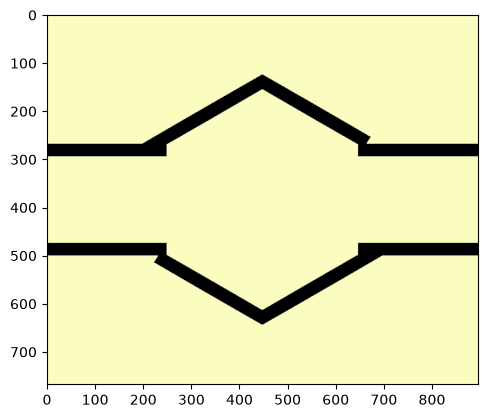

In [6]:
B_test = -0.05

plasmeep_test, F_test, G_w = build_fullfields_case(B_test)
fs_test, fp_test, gamma_test = F_test

domain_dir = os.path.join(output, "PMMCirculator_fullfields_domain")
os.makedirs(domain_dir, exist_ok=True)

plasmeep_test.Viz_Domain(domain_dir, fs_test)

print("Built Fullfields case successfully.")
print("B =", B_test, "T")
print("fs =", fs_test, "c/a")
print("fp =", fp_test, "c/a")
print("gamma =", gamma_test, "c/a")
print("Domain plot:", os.path.join(domain_dir, "domain.png"))

## 5. Run one field case

At `res=64`, this should be much faster than the original `res=128` run.

For the high-resolution reproduction, change `DEV_RES` to 128 and `until` to 100.

-----------
Initializing structure...
time for choose_chunkdivision = 0.000634909 s
Working in 2D dimensions.
Computational cell is 14 x 12 x 0 with resolution 64
     prism, center = (-1.8403,2.76485,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (0,3.57735,0)
          (0,4.07735,0)
          (-3.89711,1.82735,0)
          (-3.4641,1.57735,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (-3.4976,1.5476,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-3.4641,1.57735,0)
          (-3.89711,1.82735,0)
          (-3.53109,1.39286,0)
          (-3.09808,1.39286,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (1.65729,2.87051,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (0,3.57735,0)
          (0,4.07735,0)
          (3.53109,2.03868,0)
          (3.09808

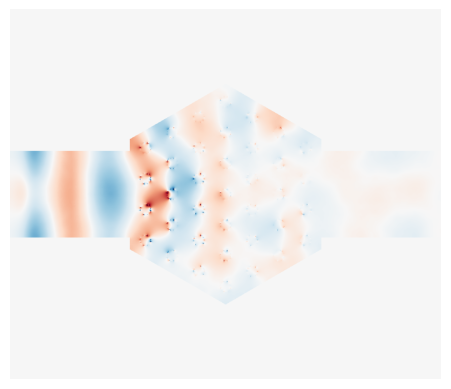

In [7]:
# Rebuild the case so Viz_Domain and the field run use fresh Simulation objects.
plasmeep_Bminus, _, _ = build_fullfields_case(-0.05, res=DEV_RES)

plasmeep_Bminus.Sim_And_Plot(
    at_every=2.0,
    field='H',
    until=50,
    output_dir=output,
    component='hz',
    out_prefix='PMMCirculator_Bminus_dev',
    remove=True,
    all_frames=False
)

## 6. The important physics test: compare \(B=0\), \(+B\), and \(-B\)

Do **not** run all three at high resolution yet. Run them one at a time at development resolution.

What we are looking for:

- \(B=0\): reciprocal baseline.
- \(+B\): magnetized response.
- \(-B\): reversing the magnetic bias should reverse the handedness/direction of the gyrotropic response.

A field image is useful for intuition, but it is **not an S-parameter measurement**. Quantitative comparison comes later with port monitors.

-----------
Initializing structure...
time for choose_chunkdivision = 0.000597954 s
Working in 2D dimensions.
Computational cell is 14 x 12 x 0 with resolution 64
     prism, center = (-1.8403,2.76485,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (0,3.57735,0)
          (0,4.07735,0)
          (-3.89711,1.82735,0)
          (-3.4641,1.57735,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (-3.4976,1.5476,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-3.4641,1.57735,0)
          (-3.89711,1.82735,0)
          (-3.53109,1.39286,0)
          (-3.09808,1.39286,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (1.65729,2.87051,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (0,3.57735,0)
          (0,4.07735,0)
          (3.53109,2.03868,0)
          (3.09808

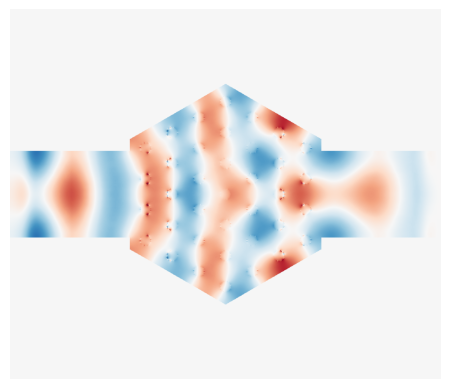

In [8]:
# Uncomment ONE case at a time while developing.

plasmeep_B0, _, _ = build_fullfields_case(0.0, res=DEV_RES)
plasmeep_B0.Sim_And_Plot(
    2.0, 'H', 50, output, 'hz',
    out_prefix='PMMCirculator_B0_dev',
    remove=True
)

# plasmeep_Bplus, _, _ = build_fullfields_case(+0.05, res=DEV_RES)
# plasmeep_Bplus.Sim_And_Plot(
#     2.0, 'H', 50, output, 'hz',
#     out_prefix='PMMCirculator_Bplus_dev',
#     remove=True
# )

# 7. Connect this to `PMMCirculatorInverse.py`

The Fullfields section above proves the magnetized PlasMEEP physics is working.

Now sanity-check the new wrapper's most important job:

\[
\rho_i \longrightarrow f_{p,i}
\]

while keeping \(B\) as a separate physical input.

Place `PMMCirculatorInverse.py` in the same `scripts/` directory as this notebook before running the next cell.

In [11]:
from PMMCirculatorInverse import PMMI

# PMMInverse-style coordinates put the domain center at (nx/2, ny/2).
pmm = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx,
    ny=ny,
    dpml=dpml,
    B=np.array([0.0, 0.0, 0.0])
)

# Start with the same 37-element side_dim=4 crystal as Fullfields.
# Later replace this with the actual PMM circulator array/geometry.
pmm.Rod_Array_Hexagon_train(
    xy_cen=np.array([nx/2, ny/2]),
    side_dim=6,
    r=0.005/a,
    d=1,
    bulbs=False,
    uniform=True
)

print("Number of trainable elements:", len(pmm.train_elems))

assert len(pmm.train_elems) == 91

Number of trainable elements: 91


### Uniform \(\rho\) test

With `wp_max=0`, the new wrapper treats `abs(rho)` directly as the nondimensionalized plasma frequency. Therefore a uniform test at the same \(f_p=8\) GHz as Fullfields is simply:

In [12]:
rho_uniform = np.ones(len(pmm.train_elems)) * fp_a

wp_values, element_locations = pmm.Scale_Rho_wp(
    rho_uniform,
    w_src=fs_a,
    wp_max=0,
    gamma=gamma_a
)

print("rho count:", len(rho_uniform))
print("wp count:", len(wp_values))
print("first wp:", wp_values[0])
print("target fp_a:", fp_a)
print("all wp values match target:", np.allclose(wp_values, fp_a))

rho count: 91
wp count: 91
first wp: 0.7471835732438606
target fp_a: 0.7471835732438606
all wp values match target: True


In [ ]:
# Build the actual 91-discharge circulator array
# ============================================================

# Start a fresh PMM object for the real circulator geometry.
# Keep B = 0 for now so we can validate the geometry before
# introducing nonreciprocity.

pmm = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx,
    ny=ny,
    dpml=dpml,
    B=np.array([0.0, 0.0, 0.0])
)

# The experimental array has 6 discharges along each side,
# which corresponds to side_dim = 6 and gives 91 total elements.

pmm.Rod_Array_Hexagon_train(
    xy_cen=np.array([nx/2, ny/2]),
    side_dim=6,
    r=0.005/a,
    d=1,
    bulbs=False,
    uniform=True
)

# Give every discharge the same plasma frequency for the
# first geometry/physics validation.

rho_uniform = np.ones(len(pmm.train_elems)) * fp_a

wp_values, element_locations = pmm.Scale_Rho_wp(
    rho_uniform,
    w_src=fs_a,
    wp_max=0,
    gamma=gamma_a
)

print("Number of trainable discharges:", len(pmm.train_elems))
print("Number of wp values:", len(wp_values))
print("Expected number:", 91)
print("All wp values match fp_a:", np.allclose(wp_values, fp_a))

assert len(pmm.train_elems) == 91
assert len(wp_values) == 91
assert np.allclose(wp_values, fp_a)

Number of trainable discharges: 91
Number of wp values: 91
Expected number: 91
All wp values match fp_a: True


Number of discharges: 91
Number of hexagon corners: 6

Six array faces / future horn directions:
Port 1: face center = [11.330, 6.000], outward direction = [1.000, -0.000], angle = 0.0 deg
Port 2: face center = [9.165, 9.750], outward direction = [0.500, 0.866], angle = 60.0 deg
Port 3: face center = [4.835, 9.750], outward direction = [-0.500, 0.866], angle = 120.0 deg
Port 4: face center = [2.670, 6.000], outward direction = [-1.000, -0.000], angle = 180.0 deg
Port 5: face center = [4.835, 2.250], outward direction = [-0.500, -0.866], angle = 240.0 deg
Port 6: face center = [9.165, 2.250], outward direction = [0.500, -0.866], angle = 300.0 deg


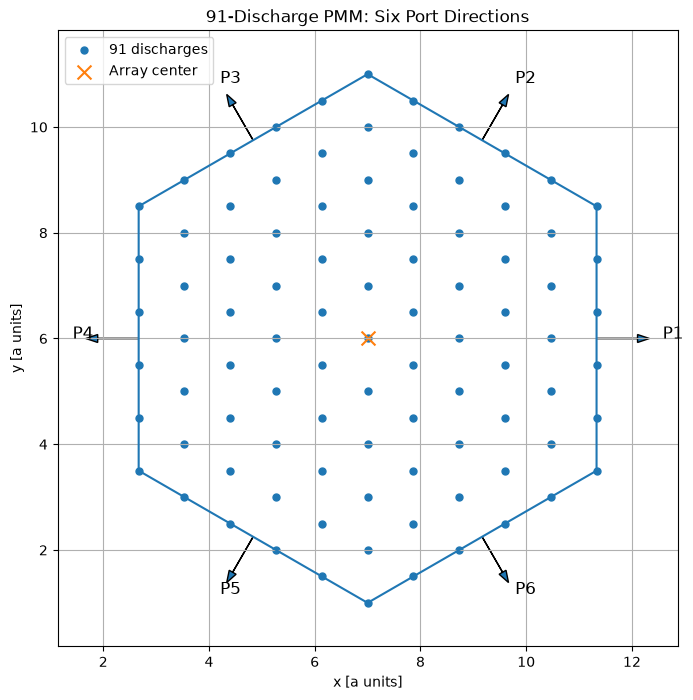

In [ ]:
# Identify the 6 sides of the 91-discharge hexagonal array
# and the outward direction of each future horn/port.
# ============================================================

from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

# Locations of all 91 discharges
locs = np.asarray(pmm.train_elem_locs, dtype=float)

# Center of the discharge array
array_center = np.mean(locs, axis=0)

# Find the outer boundary of the 91-element array.
# For this regular array, the convex hull should have 6 corners.
hull = ConvexHull(locs)
corners = locs[hull.vertices]

print("Number of discharges:", len(locs))
print("Number of hexagon corners:", len(corners))

assert len(locs) == 91
assert len(corners) == 6


# ------------------------------------------------------------
# Find the center and outward normal of each of the 6 sides
# ------------------------------------------------------------

face_centers = []
port_dirs = []

for i in range(6):

    p1 = corners[i]
    p2 = corners[(i + 1) % 6]

    # Center of this side of the hexagon
    face_center = (p1 + p2) / 2

    # Direction along the side
    tangent = p2 - p1
    tangent = tangent / np.linalg.norm(tangent)

    # Perpendicular direction
    normal = np.array([
        tangent[1],
        -tangent[0]
    ])

    # Make sure the normal points AWAY from the array center
    if np.dot(normal, face_center - array_center) < 0:
        normal = -normal

    face_centers.append(face_center)
    port_dirs.append(normal)


face_centers = np.asarray(face_centers)
port_dirs = np.asarray(port_dirs)


# ------------------------------------------------------------
# Order the ports counterclockwise, starting near +x
# ------------------------------------------------------------

angles = np.arctan2(
    port_dirs[:, 1],
    port_dirs[:, 0]
)

angles = np.mod(angles, 2*np.pi)

order = np.argsort(angles)

face_centers = face_centers[order]
port_dirs = port_dirs[order]
angles = angles[order]


# ------------------------------------------------------------
# Print the six ports
# ------------------------------------------------------------

print("\nSix array faces / future horn directions:")

for i in range(6):

    print(
        f"Port {i+1}: "
        f"face center = "
        f"[{face_centers[i,0]:.3f}, "
        f"{face_centers[i,1]:.3f}], "
        f"outward direction = "
        f"[{port_dirs[i,0]:.3f}, "
        f"{port_dirs[i,1]:.3f}], "
        f"angle = {np.degrees(angles[i]):.1f} deg"
    )


# ------------------------------------------------------------
# Plot the array and its six outward port directions
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.scatter(
    locs[:,0],
    locs[:,1],
    s=25,
    label="91 discharges"
)

# Draw the hexagonal outer boundary
closed_corners = np.vstack([corners, corners[0]])

plt.plot(
    closed_corners[:,0],
    closed_corners[:,1]
)

# Draw one arrow normal to each side
for i in range(6):

    fc = face_centers[i]
    u = port_dirs[i]

    plt.arrow(
        fc[0],
        fc[1],
        u[0],
        u[1],
        head_width=0.15,
        length_includes_head=True
    )

    plt.text(
        fc[0] + 1.25*u[0],
        fc[1] + 1.25*u[1],
        f"P{i+1}",
        fontsize=12
    )

plt.scatter(
    array_center[0],
    array_center[1],
    marker="x",
    s=100,
    label="Array center"
)

plt.axis("equal")
plt.xlabel("x [a units]")
plt.ylabel("y [a units]")
plt.title("91-Discharge PMM: Six Port Directions")
plt.legend()
plt.grid(True)

plt.show()

Number of discharges: 91
Nearest-neighbor spacing: 19.999999999999964 mm
All wp values match fp_a: True


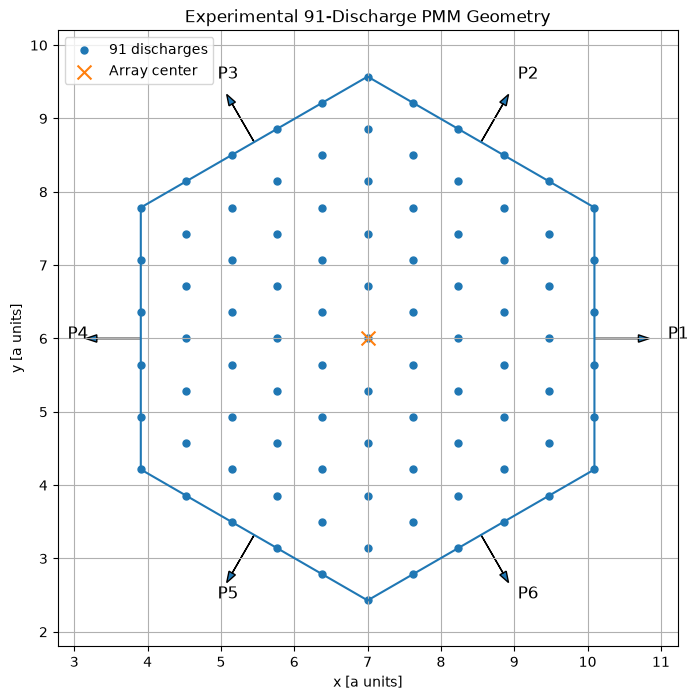

In [16]:
# ============================================================
# Rebuild the 91-discharge array using the actual
# experimental 20 mm center-to-center spacing
# ============================================================

from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Experimental dimensions
d_exp = 0.020 / a          # 20 mm center-to-center spacing, in a units
r_plasma = 0.005 / a       # ~5 mm plasma radius for now

# Physical quartz dimensions -- we will use these when
# we add the actual bulb/glass geometry
r_bulb_inner = 0.0065 / a  # 13 mm ID
r_bulb_outer = 0.0075 / a  # 15 mm OD


# Start fresh at B = 0
pmm = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx,
    ny=ny,
    dpml=dpml,
    B=np.array([0.0, 0.0, 0.0])
)


# Build the actual 91-element filled hexagon
pmm.Rod_Array_Hexagon_train(
    xy_cen=np.array([nx/2, ny/2]),
    side_dim=6,
    r=r_plasma,
    d=d_exp,
    bulbs=False,       # add physical quartz bulbs later
    uniform=True
)


# Give all 91 discharges the same plasma frequency
rho_uniform = np.ones(len(pmm.train_elems)) * fp_a

wp_values, element_locations = pmm.Scale_Rho_wp(
    rho_uniform,
    w_src=fs_a,
    wp_max=0,
    gamma=gamma_a
)


# ------------------------------------------------------------
# Verify the array
# ------------------------------------------------------------

locs = np.asarray(pmm.train_elem_locs, dtype=float)

# Find nearest-neighbor spacing
distances = pdist(locs)
nearest_spacing_a = np.min(distances)
nearest_spacing_m = nearest_spacing_a * a

print("Number of discharges:", len(locs))
print("Nearest-neighbor spacing:", nearest_spacing_m*1000, "mm")
print("All wp values match fp_a:", np.allclose(wp_values, fp_a))

assert len(locs) == 91
assert np.isclose(nearest_spacing_m, 0.020)
assert np.allclose(wp_values, fp_a)


# ------------------------------------------------------------
# Recalculate the six faces and outward port directions
# ------------------------------------------------------------

array_center = np.mean(locs, axis=0)

hull = ConvexHull(locs)
corners = locs[hull.vertices]

face_centers = []
port_dirs = []

for i in range(6):

    p1 = corners[i]
    p2 = corners[(i + 1) % 6]

    face_center = (p1 + p2) / 2

    tangent = p2 - p1
    tangent = tangent / np.linalg.norm(tangent)

    normal = np.array([
        tangent[1],
        -tangent[0]
    ])

    # Make sure normal points outward
    if np.dot(normal, face_center - array_center) < 0:
        normal = -normal

    face_centers.append(face_center)
    port_dirs.append(normal)

face_centers = np.asarray(face_centers)
port_dirs = np.asarray(port_dirs)


# Order ports counterclockwise starting near +x
angles = np.mod(
    np.arctan2(port_dirs[:,1], port_dirs[:,0]),
    2*np.pi
)

order = np.argsort(angles)

face_centers = face_centers[order]
port_dirs = port_dirs[order]
angles = angles[order]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,8))

plt.scatter(
    locs[:,0],
    locs[:,1],
    s=25,
    label="91 discharges"
)

closed_corners = np.vstack([
    corners,
    corners[0]
])

plt.plot(
    closed_corners[:,0],
    closed_corners[:,1]
)

for i in range(6):

    fc = face_centers[i]
    u = port_dirs[i]

    plt.arrow(
        fc[0],
        fc[1],
        u[0]*0.75,
        u[1]*0.75,
        head_width=0.10,
        length_includes_head=True
    )

    plt.text(
        fc[0] + u[0],
        fc[1] + u[1],
        f"P{i+1}",
        fontsize=12
    )

plt.scatter(
    array_center[0],
    array_center[1],
    marker="x",
    s=100,
    label="Array center"
)

plt.axis("equal")
plt.xlabel("x [a units]")
plt.ylabel("y [a units]")
plt.title("Experimental 91-Discharge PMM Geometry")
plt.legend()
plt.grid(True)

plt.show()

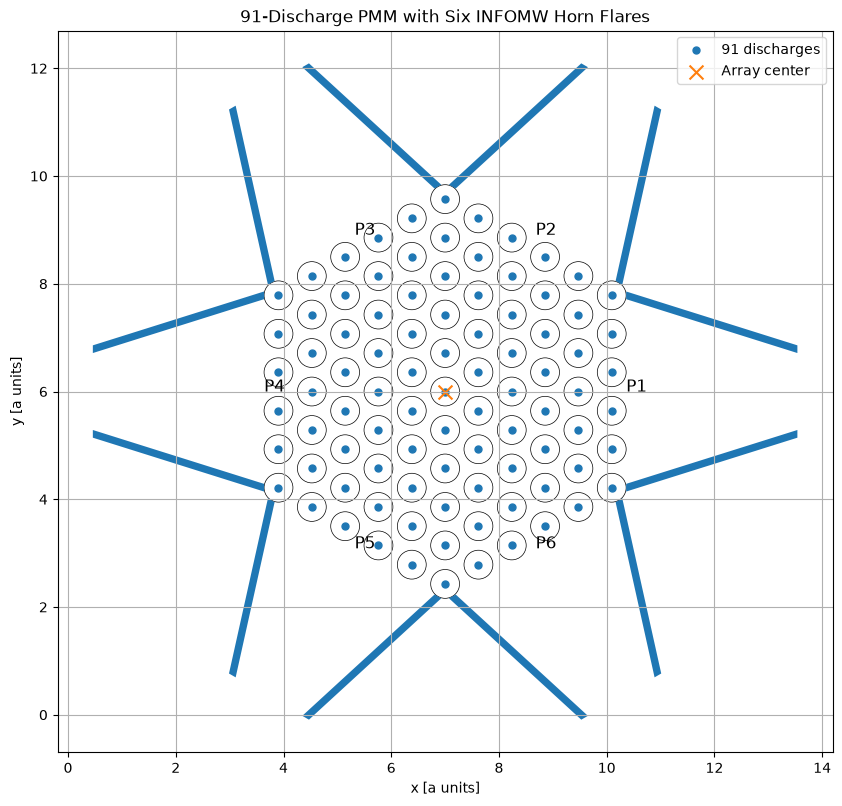

Discharges: 91
Horn flares: 6

Horn dimensions:
  aperture width = 104.0 mm
  throat width   = 48.0 mm
  flare depth    = 89.0 mm
  wall thickness = 4.0 mm


In [17]:
# ============================================================
# Add the 6 physical horn flares around the 91-element array
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


# ------------------------------------------------------------
# Horn dimensions from the original PMMInverse.py
# TM orientation
# ------------------------------------------------------------

wall_thickness = 0.004 / a    # 4 mm
width_open     = 0.104 / a    # 104 mm aperture
width_base     = 0.048 / a    # 48 mm throat
horn_depth     = 0.089 / a    # 89 mm flare depth


# ------------------------------------------------------------
# Put each horn aperture just outside the physical outer edge
# of the outermost quartz bulbs.
#
# No extra arbitrary gap is being added yet.
# ------------------------------------------------------------

horn_open_centers = (
    face_centers
    + r_bulb_outer * port_dirs
)


# ------------------------------------------------------------
# Reproduce the flare geometry from Add_INFOMW_Horn()
#
# IMPORTANT:
# In the old PMMInverse convention, horn_dir points from the
# horn body TOWARD the aperture/device.
#
# Our port_dirs point OUTWARD from the array.
#
# Therefore:
#
#       horn_dir = -port_dirs
# ------------------------------------------------------------

def get_horn_flare(xy_open_cen, outward_dir):

    horn_dir = -np.asarray(outward_dir, dtype=float)

    horn_dir = horn_dir / np.linalg.norm(horn_dir)

    horn_dir_orth = np.array([
        horn_dir[1],
        -horn_dir[0]
    ])


    # Left flare wall
    left_open = np.array([

        xy_open_cen
        + horn_dir_orth * width_open/2,

        xy_open_cen
        + horn_dir_orth * (width_open/2 - wall_thickness),

        xy_open_cen
        + horn_dir_orth * (width_base/2 - wall_thickness)
        - horn_dir * horn_depth,

        xy_open_cen
        + horn_dir_orth * width_base/2
        - horn_dir * horn_depth
    ])


    # Right flare wall
    right_open = np.array([

        xy_open_cen
        - horn_dir_orth * width_open/2,

        xy_open_cen
        - horn_dir_orth * (width_open/2 - wall_thickness),

        xy_open_cen
        - horn_dir_orth * (width_base/2 - wall_thickness)
        - horn_dir * horn_depth,

        xy_open_cen
        - horn_dir_orth * width_base/2
        - horn_dir * horn_depth
    ])


    return left_open, right_open


# ------------------------------------------------------------
# Build all 6 horn flares
# ------------------------------------------------------------

horn_flares = []

for i in range(6):

    left_wall, right_wall = get_horn_flare(
        horn_open_centers[i],
        port_dirs[i]
    )

    horn_flares.append(
        (left_wall, right_wall)
    )


# ------------------------------------------------------------
# Plot array + all six horns
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))


# 91 discharge centers
ax.scatter(
    locs[:,0],
    locs[:,1],
    s=25,
    label="91 discharges"
)


# Approximate physical outside of each quartz tube
for xy in locs:

    bulb = plt.Circle(
        xy,
        r_bulb_outer,
        fill=False,
        linewidth=0.5
    )

    ax.add_patch(bulb)


# Six horn flare walls
for i, (left_wall, right_wall) in enumerate(horn_flares):

    ax.add_patch(
        Polygon(
            left_wall,
            closed=True
        )
    )

    ax.add_patch(
        Polygon(
            right_wall,
            closed=True
        )
    )


    # Label the horn at its aperture
    xy = horn_open_centers[i]

    ax.text(
        xy[0],
        xy[1],
        f"P{i+1}",
        fontsize=12
    )


# Array center
ax.scatter(
    array_center[0],
    array_center[1],
    marker="x",
    s=100,
    label="Array center"
)


ax.set_aspect("equal")

ax.set_xlabel("x [a units]")
ax.set_ylabel("y [a units]")

ax.set_title(
    "91-Discharge PMM with Six INFOMW Horn Flares"
)

ax.legend()
ax.grid(True)

plt.show()


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("Discharges:", len(locs))
print("Horn flares:", len(horn_flares))

print()
print("Horn dimensions:")
print("  aperture width =", width_open*a*1000, "mm")
print("  throat width   =", width_base*a*1000, "mm")
print("  flare depth    =", horn_depth*a*1000, "mm")
print("  wall thickness =", wall_thickness*a*1000, "mm")

assert len(locs) == 91
assert len(horn_flares) == 6

Circulator domain:
  nx = 17
  ny = 16
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0.61859,-3.2142

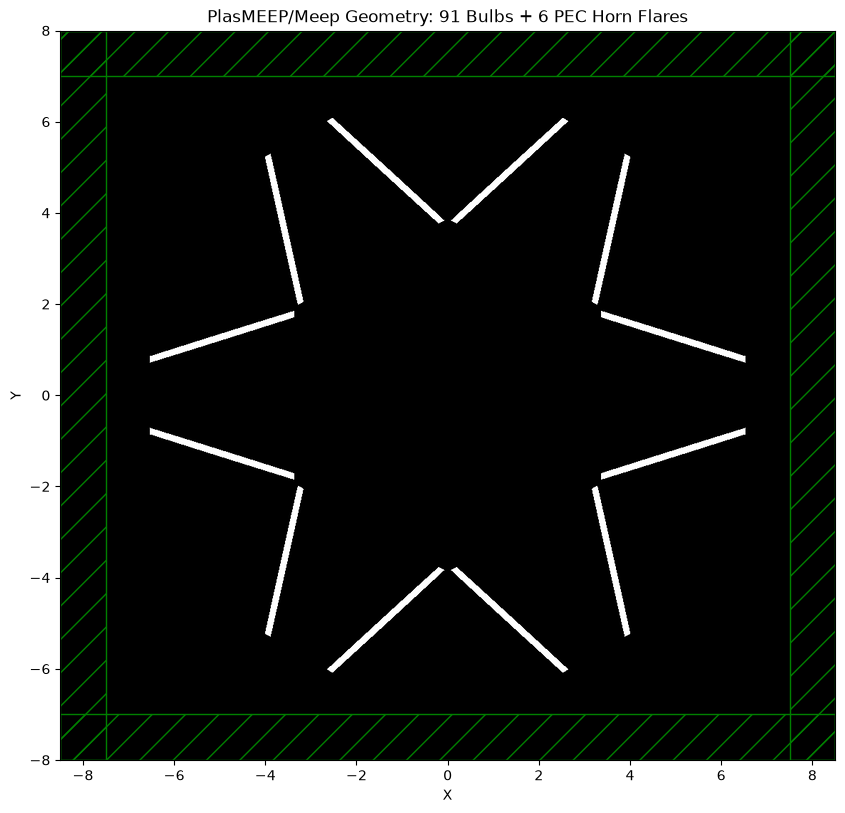


Geometry successfully built.
Trainable discharges: 91
Plasma-frequency values: 91
Horn flares: 6
B = [0. 0. 0.]


In [18]:
# ============================================================
# Build the actual PlasMEEP / Meep geometry:
# 91 plasma bulbs + 6 PEC horn flares
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull


# ------------------------------------------------------------
# 1. Make the domain large enough to contain all 6 horns
#
# The original nx=14, ny=12 development box is too small
# once the full horn flares are placed around the array.
# ------------------------------------------------------------

# Find the maximum horn extent relative to the array center
all_horn_points = []

for left_wall, right_wall in horn_flares:
    all_horn_points.append(left_wall)
    all_horn_points.append(right_wall)

all_horn_points = np.vstack(all_horn_points)

relative_horn_points = all_horn_points - array_center

max_x = np.max(np.abs(relative_horn_points[:, 0]))
max_y = np.max(np.abs(relative_horn_points[:, 1]))

# Leave room for the PML plus a little extra air
air_buffer = 0.5

nx_circ = int(np.ceil(2 * (max_x + dpml + air_buffer)))
ny_circ = int(np.ceil(2 * (max_y + dpml + air_buffer)))

print("Circulator domain:")
print("  nx =", nx_circ)
print("  ny =", ny_circ)


# ------------------------------------------------------------
# 2. Rebuild PMMI using the larger six-port domain
# ------------------------------------------------------------

pmm = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx_circ,
    ny=ny_circ,
    dpml=dpml,
    B=np.array([0.0, 0.0, 0.0])   # B = 0 first
)

array_center = np.array([
    nx_circ / 2,
    ny_circ / 2
])


# ------------------------------------------------------------
# 3. Rebuild the actual 91-discharge array
# ------------------------------------------------------------

pmm.Rod_Array_Hexagon_train(
    xy_cen=array_center,
    side_dim=6,
    r=r_plasma,
    d=d_exp,
    bulbs=False,
    uniform=True
)

locs = np.asarray(
    pmm.train_elem_locs,
    dtype=float
)

assert len(locs) == 91


# Uniform plasma frequency for first validation
rho_uniform = np.ones(91) * fp_a

wp_values, element_locations = pmm.Scale_Rho_wp(
    rho_uniform,
    w_src=fs_a,
    wp_max=0,
    gamma=gamma_a
)


# ------------------------------------------------------------
# 4. Recalculate the six array faces
# ------------------------------------------------------------

hull = ConvexHull(locs)
corners = locs[hull.vertices]

face_centers = []
port_dirs = []

for i in range(6):

    p1 = corners[i]
    p2 = corners[(i + 1) % 6]

    face_center = (p1 + p2) / 2

    tangent = p2 - p1
    tangent = tangent / np.linalg.norm(tangent)

    normal = np.array([
        tangent[1],
        -tangent[0]
    ])

    if np.dot(normal, face_center - array_center) < 0:
        normal = -normal

    face_centers.append(face_center)
    port_dirs.append(normal)

face_centers = np.asarray(face_centers)
port_dirs = np.asarray(port_dirs)


# Order ports counterclockwise starting near +x
angles = np.mod(
    np.arctan2(port_dirs[:, 1], port_dirs[:, 0]),
    2*np.pi
)

order = np.argsort(angles)

face_centers = face_centers[order]
port_dirs = port_dirs[order]
angles = angles[order]


# ------------------------------------------------------------
# 5. Rebuild the six horn flare polygons
# ------------------------------------------------------------

horn_open_centers = (
    face_centers
    + r_bulb_outer * port_dirs
)

horn_flares = []

for i in range(6):

    left_wall, right_wall = get_horn_flare(
        horn_open_centers[i],
        port_dirs[i]
    )

    horn_flares.append(
        (left_wall, right_wall)
    )


# ------------------------------------------------------------
# 6. Create the PlasMEEP object
# ------------------------------------------------------------

P = pmm.Build_Sim()


# ------------------------------------------------------------
# 7. Add all 91 physical plasma bulbs
#
# PMMI coordinates run from 0 -> nx and 0 -> ny.
# Meep coordinates are centered at (0,0), so convert them.
# ------------------------------------------------------------

for i in range(91):

    xy = locs[i]

    center_meep = np.array([
        xy[0] - nx_circ/2,
        xy[1] - ny_circ/2,
        0.0
    ])

    P.Add_Bulb(
        r_bulb=(
            r_bulb_inner,
            r_bulb_outer
        ),
        center=center_meep,
        wp=wp_values[i],
        gamma=gamma_a,
        axis=np.array([0, 0, 1]),
        profile=0
    )


# ------------------------------------------------------------
# 8. Add all six horn flares as PEC prisms
# ------------------------------------------------------------

for left_wall, right_wall in horn_flares:

    for wall in [left_wall, right_wall]:

        # Convert old PMM coordinates to centered Meep coordinates
        vertices = np.zeros((4, 3))

        vertices[:, 0] = wall[:, 0] - nx_circ/2
        vertices[:, 1] = wall[:, 1] - ny_circ/2
        vertices[:, 2] = 0.0

        P.Add_Prism(
            vertices=vertices,
            axis=np.array([0, 0, 1]),
            PEC=True
        )


# ------------------------------------------------------------
# 9. Convert the PlasMEEP geometry into an actual Meep Simulation
# ------------------------------------------------------------

meep_sim = P.Get_Sim()


# ------------------------------------------------------------
# 10. Plot the ACTUAL Meep geometry
#
# No time stepping / field simulation is happening yet.
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

meep_sim.plot2D(
    ax=ax,
    labels=False
)

ax.set_title(
    "PlasMEEP/Meep Geometry: 91 Bulbs + 6 PEC Horn Flares"
)

plt.show()


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print()
print("Geometry successfully built.")
print("Trainable discharges:", len(pmm.train_elems))
print("Plasma-frequency values:", len(wp_values))
print("Horn flares:", len(horn_flares))
print("B =", pmm.B)

assert len(pmm.train_elems) == 91
assert len(wp_values) == 91
assert len(horn_flares) == 6

     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0.61859,-3.21429,0)
          radius 0.267857, height 

/Users/bronstek/miniforge3/envs/plasmeep_x86/lib/python3.11/site-packages/meep/visualization.py:533: UserWarning: The frequency parameter of plot2D has been deprecated. Use the frequency key of the eps_parameters dictionary instead.
  warnings.warn(


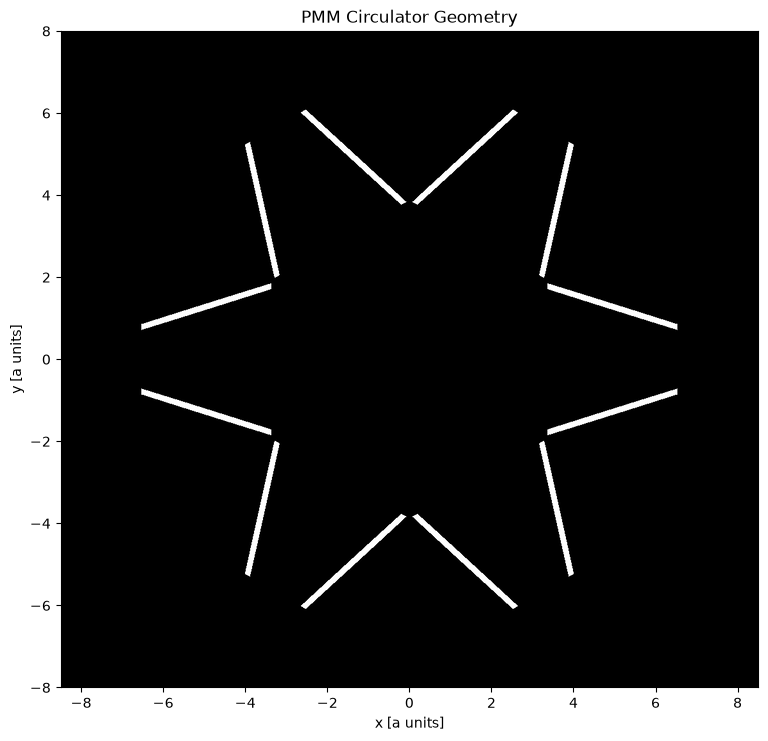

In [ ]:
# Cleaner geometry check
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

meep_sim.plot2D(
    ax=ax,
    frequency=fs_a,
    show_boundary_layers=False,
    show_sources=False,
    show_monitors=False,
    labels=False
)

ax.set_aspect("equal")
ax.set_title("PMM Circulator Geometry")
ax.set_xlabel("x [a units]")
ax.set_ylabel("y [a units]")

plt.show()

Port 1 outward direction: [ 1. -0.]
Port 1 source center: [3.36080501 0.         0.        ]
Port 1 source width: 96.0 mm

Running Port-1 field test...
-----------
Initializing structure...
time for choose_chunkdivision = 0.00326014 s
Working in 2D dimensions.
Computational cell is 17 x 16 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, he

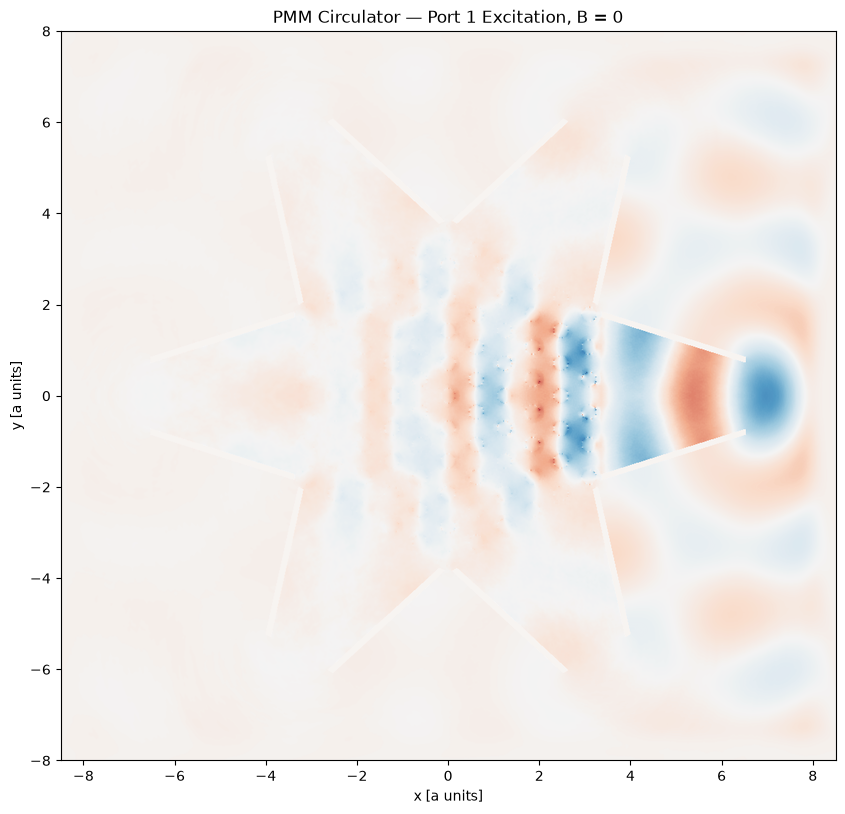

In [ ]:
# First six-port FIELD run
#
# Excite Port 1 at B = 0 and visualize Hz.
# This is a field sanity check only -- NOT S-parameters yet.
# ============================================================

import meep as mp
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Define Port 1
#
# port_dirs point OUTWARD from the array.
# The source sits across the Port-1 aperture.
# ------------------------------------------------------------

port1_out = port_dirs[0]

# Unit vector across the horn aperture
port1_tangent = np.array([
    -port1_out[1],
     port1_out[0]
])


# Convert the Port-1 aperture center from PMMI coordinates
# to centered Meep coordinates
port1_center = np.array([
    horn_open_centers[0, 0] - nx_circ/2,
    horn_open_centers[0, 1] - ny_circ/2,
    0.0
])


# Source spans the clear interior of the horn aperture
source_width = width_open - 2*wall_thickness

port1_size = np.array([
    port1_tangent[0] * source_width,
    port1_tangent[1] * source_width,
    0.0
])


print("Port 1 outward direction:", port1_out)
print("Port 1 source center:", port1_center)
print("Port 1 source width:",
      source_width*a*1000, "mm")


# ------------------------------------------------------------
# 2. Add the Port-1 continuous-wave Hz source
#
# Clear any previous sources first so rerunning this cell
# does not accidentally add multiple sources.
#
# E=False + [0,0,1] -> Hz source, matching the polarization
# we used in the magnetized Fullfields test.
# ------------------------------------------------------------

P.sources = []

P.Add_Cont_Source(
    fs_a,
    np.array([0.0, 0.0, 1.0]),
    port1_center,
    port1_size,
    E=False
)


# ------------------------------------------------------------
# 3. Build a fresh Meep Simulation containing the source
# ------------------------------------------------------------

field_sim = P.Get_Sim()


# ------------------------------------------------------------
# 4. Run
#
# Keep this short for the first test.
# We can increase the run time once we start calculating
# quantitative S-parameters.
# ------------------------------------------------------------

print("\nRunning Port-1 field test...")

field_sim.run(
    until=30
)

print("Run complete.")


# ------------------------------------------------------------
# 5. Jesse-style field plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

field_sim.plot2D(
    ax=ax,

    fields=mp.Hz,

    frequency=fs_a,

    show_boundary_layers=False,
    show_sources=False,
    show_monitors=False,

    eps_parameters={
        "alpha": 0.12
    },

    field_parameters={
        "alpha": 0.90,
        "cmap": "RdBu",
        "interpolation": "spline36"
    }
)

ax.set_aspect("equal")

ax.set_title(
    "PMM Circulator — Port 1 Excitation, B = 0"
)

ax.set_xlabel("x [a units]")
ax.set_ylabel("y [a units]")

plt.show()

Straight feed length: 60.0 mm

New six-port domain:
  nx = 23
  ny = 21
  dpml = 2

Port locations:
P1 monitor = [7.182, 0.000]
P2 monitor = [3.591, 6.220]
P3 monitor = [-3.591, 6.220]
P4 monitor = [-7.182, 0.000]
P5 monitor = [-3.591, -6.220]
P6 monitor = [3.591, -6.220]

P1 source = [8.03937644 0.        ]
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height

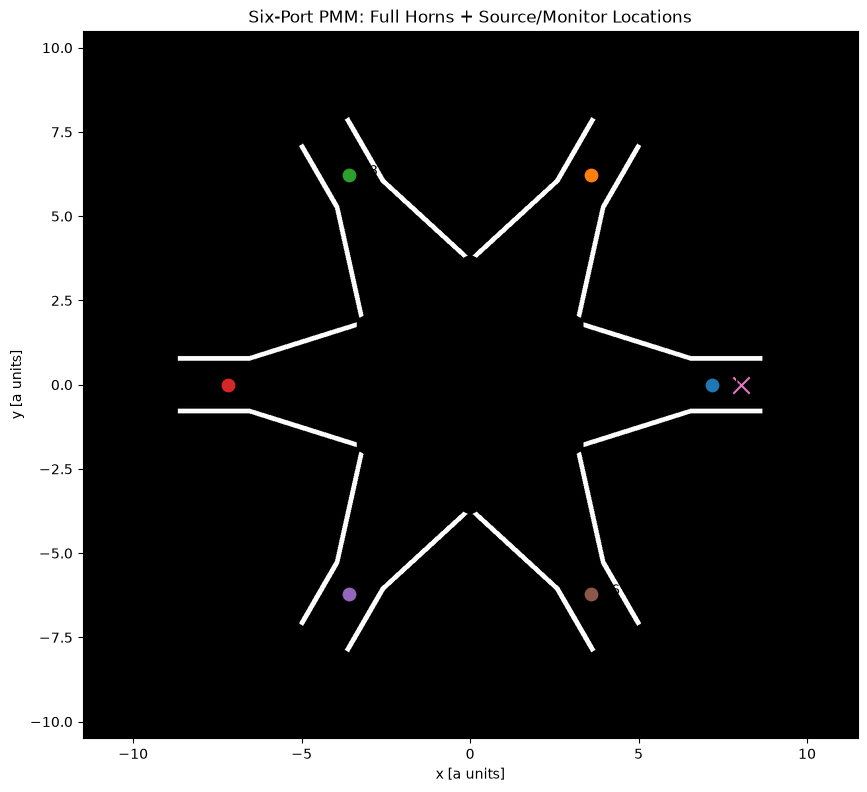


Geometry checkpoint:
  discharges = 91
  horns      = 6
  monitors   = 6
  B          = [0. 0. 0.]


In [ ]:
# Build full 6-port geometry:
# horn flares + straight feed sections
#
# Also define the future source and monitor planes.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import meep as mp


# ------------------------------------------------------------
# 1. Straight feed length
#
# This is a NUMERICAL feed section for clean source/monitor
# placement. We are not claiming this is the exact physical
# coax-to-horn length in the experiment.
# ------------------------------------------------------------

feed_length_m = 0.060
feed_length = feed_length_m / a

print("Straight feed length:", feed_length_m*1000, "mm")


# ------------------------------------------------------------
# 2. Work relative to the center of the PMM array
# ------------------------------------------------------------

face_offsets = face_centers - array_center

horn_open_offsets = (
    face_offsets
    + r_bulb_outer * port_dirs
)


# ------------------------------------------------------------
# 3. Build the COMPLETE horn-wall polygons
#
# This follows the old Add_INFOMW_Horn geometry:
#
#     aperture
#        ↓
#     flare
#        ↓
#     throat
#        ↓
#     straight feed
#
# ------------------------------------------------------------

def get_full_horn(xy_open_cen, outward_dir, feed_length):

    outward_dir = np.asarray(
        outward_dir,
        dtype=float
    )

    outward_dir = (
        outward_dir /
        np.linalg.norm(outward_dir)
    )

    # Old PMMInverse horn_dir convention
    horn_dir = -outward_dir

    horn_dir_orth = np.array([
        horn_dir[1],
        -horn_dir[0]
    ])


    # -------------------------
    # LEFT FLARE WALL
    # -------------------------

    left_open = np.array([

        xy_open_cen
        + horn_dir_orth * width_open/2,

        xy_open_cen
        + horn_dir_orth
        * (width_open/2 - wall_thickness),

        xy_open_cen
        + horn_dir_orth
        * (width_base/2 - wall_thickness)
        - horn_dir * horn_depth,

        xy_open_cen
        + horn_dir_orth * width_base/2
        - horn_dir * horn_depth
    ])


    # -------------------------
    # LEFT STRAIGHT WALL
    # -------------------------

    left_feed = np.array([

        xy_open_cen
        + horn_dir_orth
        * (width_base/2 - wall_thickness)
        - horn_dir * horn_depth,

        xy_open_cen
        + horn_dir_orth * width_base/2
        - horn_dir * horn_depth,

        xy_open_cen
        + horn_dir_orth * width_base/2
        - horn_dir * (horn_depth + feed_length),

        xy_open_cen
        + horn_dir_orth
        * (width_base/2 - wall_thickness)
        - horn_dir * (horn_depth + feed_length)
    ])


    # -------------------------
    # RIGHT FLARE WALL
    # -------------------------

    right_open = np.array([

        xy_open_cen
        - horn_dir_orth * width_open/2,

        xy_open_cen
        - horn_dir_orth
        * (width_open/2 - wall_thickness),

        xy_open_cen
        - horn_dir_orth
        * (width_base/2 - wall_thickness)
        - horn_dir * horn_depth,

        xy_open_cen
        - horn_dir_orth * width_base/2
        - horn_dir * horn_depth
    ])


    # -------------------------
    # RIGHT STRAIGHT WALL
    # -------------------------

    right_feed = np.array([

        xy_open_cen
        - horn_dir_orth
        * (width_base/2 - wall_thickness)
        - horn_dir * horn_depth,

        xy_open_cen
        - horn_dir_orth * width_base/2
        - horn_dir * horn_depth,

        xy_open_cen
        - horn_dir_orth * width_base/2
        - horn_dir * (horn_depth + feed_length),

        xy_open_cen
        - horn_dir_orth
        * (width_base/2 - wall_thickness)
        - horn_dir * (horn_depth + feed_length)
    ])


    # Center of throat
    throat_center = (
        xy_open_cen
        + outward_dir * horn_depth
    )


    # Monitor sits inside straight section,
    # closer to horn throat
    monitor_center = (
        throat_center
        + outward_dir * (0.30 * feed_length)
    )


    # Source sits farther outward in Port 1
    source_center = (
        throat_center
        + outward_dir * (0.70 * feed_length)
    )


    return {
        "left_flare": left_open,
        "right_flare": right_open,
        "left_feed": left_feed,
        "right_feed": right_feed,
        "throat_center": throat_center,
        "monitor_center": monitor_center,
        "source_center": source_center
    }


# ------------------------------------------------------------
# 4. Build all six complete horns
# ------------------------------------------------------------

full_horns = []

for i in range(6):

    horn = get_full_horn(
        horn_open_offsets[i],
        port_dirs[i],
        feed_length
    )

    full_horns.append(horn)


# ------------------------------------------------------------
# 5. Determine how large the new Meep domain must be
# ------------------------------------------------------------

all_wall_points = []

for horn in full_horns:

    all_wall_points.append(
        horn["left_flare"]
    )

    all_wall_points.append(
        horn["right_flare"]
    )

    all_wall_points.append(
        horn["left_feed"]
    )

    all_wall_points.append(
        horn["right_feed"]
    )

all_wall_points = np.vstack(
    all_wall_points
)

max_x = np.max(
    np.abs(all_wall_points[:,0])
)

max_y = np.max(
    np.abs(all_wall_points[:,1])
)


# Use thicker PML for this six-port version because
# four of the six feeds are oblique to x/y.
dpml_ports = 2 * dpml

air_buffer = 0.5

nx_ports = int(
    np.ceil(
        2 * (
            max_x
            + dpml_ports
            + air_buffer
        )
    )
)

ny_ports = int(
    np.ceil(
        2 * (
            max_y
            + dpml_ports
            + air_buffer
        )
    )
)


print()
print("New six-port domain:")
print("  nx =", nx_ports)
print("  ny =", ny_ports)
print("  dpml =", dpml_ports)


# ------------------------------------------------------------
# 6. Build a fresh PMMI object
# ------------------------------------------------------------

pmm_ports = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx_ports,
    ny=ny_ports,
    dpml=dpml_ports,
    B=np.array([
        0.0,
        0.0,
        0.0
    ])
)


new_array_center = np.array([
    nx_ports/2,
    ny_ports/2
])


# ------------------------------------------------------------
# 7. Rebuild the 91 trainable discharges
# ------------------------------------------------------------

pmm_ports.Rod_Array_Hexagon_train(
    xy_cen=new_array_center,
    side_dim=6,
    r=r_plasma,
    d=d_exp,
    bulbs=False,
    uniform=True
)


rho_uniform_ports = (
    np.ones(91)
    * fp_a
)


wp_ports, _ = pmm_ports.Scale_Rho_wp(
    rho_uniform_ports,
    w_src=fs_a,
    wp_max=0,
    gamma=gamma_a
)


assert len(wp_ports) == 91


# ------------------------------------------------------------
# 8. Create the PlasMEEP object
# ------------------------------------------------------------

P_ports = pmm_ports.Build_Sim()


# ------------------------------------------------------------
# 9. Add all 91 physical plasma bulbs
# ------------------------------------------------------------

locs_ports = np.asarray(
    pmm_ports.train_elem_locs
)

for i in range(91):

    # Convert PMMI coordinates to centered Meep coordinates
    center_meep = np.array([

        locs_ports[i,0] - nx_ports/2,

        locs_ports[i,1] - ny_ports/2,

        0.0
    ])

    P_ports.Add_Bulb(
        r_bulb=(
            r_bulb_inner,
            r_bulb_outer
        ),
        center=center_meep,
        wp=wp_ports[i],
        gamma=gamma_a,
        axis=np.array([
            0,
            0,
            1
        ]),
        profile=0
    )


# ------------------------------------------------------------
# 10. Add all 24 PEC wall polygons
#
# 6 horns ×
#   2 flare walls
# + 2 straight-feed walls
# = 24 PEC polygons
# ------------------------------------------------------------

for horn in full_horns:

    wall_names = [
        "left_flare",
        "right_flare",
        "left_feed",
        "right_feed"
    ]

    for name in wall_names:

        wall = horn[name]

        vertices = np.zeros(
            (4,3)
        )

        # horn coordinates are already relative
        # to the PMM center
        vertices[:,0] = wall[:,0]
        vertices[:,1] = wall[:,1]

        P_ports.Add_Prism(
            vertices=vertices,
            axis=np.array([
                0,
                0,
                1
            ]),
            PEC=True
        )


# ------------------------------------------------------------
# 11. Store source + monitor locations
#
# These are centered Meep coordinates.
#
# Port 1 source is OUTSIDE its monitor:
#
# array -> horn -> monitor -> source -> PML
#
# ------------------------------------------------------------

port_monitor_centers = np.array([
    horn["monitor_center"]
    for horn in full_horns
])

port1_source_center = (
    full_horns[0]["source_center"]
)


print()
print("Port locations:")

for i in range(6):

    print(
        f"P{i+1} monitor = "
        f"[{port_monitor_centers[i,0]:.3f}, "
        f"{port_monitor_centers[i,1]:.3f}]"
    )

print(
    "\nP1 source =",
    port1_source_center
)


# ------------------------------------------------------------
# 12. Build Meep simulation and plot
# ------------------------------------------------------------

port_sim_geometry = (
    P_ports.Get_Sim()
)


fig, ax = plt.subplots(
    figsize=(10,10)
)

port_sim_geometry.plot2D(
    ax=ax,
    frequency=fs_a,
    show_boundary_layers=False,
    labels=False
)


# ------------------------------------------------------------
# 13. Overlay future monitor positions
#
# Dot = monitor center
# X = Port-1 source center
# ------------------------------------------------------------

for i in range(6):

    xy = port_monitor_centers[i]

    ax.scatter(
        xy[0],
        xy[1],
        marker="o",
        s=80
    )

    ax.text(
        xy[0],
        xy[1],
        f"  M{i+1}",
        fontsize=10
    )


ax.scatter(
    port1_source_center[0],
    port1_source_center[1],
    marker="x",
    s=140
)

ax.text(
    port1_source_center[0],
    port1_source_center[1],
    "  P1 source",
    fontsize=10
)


ax.set_aspect("equal")

ax.set_title(
    "Six-Port PMM: Full Horns + Source/Monitor Locations"
)

ax.set_xlabel("x [a units]")
ax.set_ylabel("y [a units]")

plt.show()


# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

print()
print("Geometry checkpoint:")
print("  discharges =", len(pmm_ports.train_elems))
print("  horns      =", len(full_horns))
print("  monitors   =", len(port_monitor_centers))
print("  B          =", pmm_ports.B)

In [ ]:
# PORT-1 FLUX TEST — NO MPB
#
# Uses:
#   ordinary Hz source
#   6 Meep flux monitors
#
# B = 0
# all 91 bulbs: fp = 8 GHz
# source: Port 1, 3.85 GHz
#
# These are RAW powers, not normalized S-parameters yet.
# ============================================================

import meep as mp
import numpy as np


# ------------------------------------------------------------
# 1. Clear width inside the metal feed
# ------------------------------------------------------------

clear_width = (
    width_base
    - 2*wall_thickness
)

print(
    "Clear feed width:",
    clear_width*a*1000,
    "mm"
)


# ------------------------------------------------------------
# 2. Port-1 source
#
# Port 1 is the far-right horn.
#
# This line lies completely INSIDE the PEC walls.
#
# A magnetic-current Hz line source is appropriate for
# the Hz polarization we are testing.
# ------------------------------------------------------------

source_df = 0.10 * fs_a

port1_source = mp.Source(

    src=mp.GaussianSource(
        frequency=fs_a,
        fwidth=source_df
    ),

    component=mp.Hz,

    center=mp.Vector3(
        port1_source_center[0],
        port1_source_center[1],
        0
    ),

    # Port 1 is horizontal, therefore the source line
    # is vertical across the feed.
    size=mp.Vector3(
        0,
        0.98*clear_width,
        0
    )
)


# Put the source into the existing PlasMEEP geometry
P_ports.sources = [
    port1_source
]


# Build fresh Meep simulation
flux_sim = P_ports.Get_Sim()


# ------------------------------------------------------------
# 3. Helper for an axis-aligned flux plane
#
# Meep's own oblique-waveguide tutorial notes that an
# axis-aligned monitor can still measure the total flux
# of an oblique waveguide.
# ------------------------------------------------------------

def make_flux_region(center_xy, outward_dir):

    u = np.asarray(
        outward_dir,
        dtype=float
    )

    u = (
        u /
        np.linalg.norm(u)
    )

    # Unit vector perpendicular to waveguide
    n = np.array([
        -u[1],
         u[0]
    ])


    # ----------------------------------------
    # Mostly horizontal port:
    # use vertical flux line
    # ----------------------------------------

    if abs(u[0]) >= abs(u[1]):

        line_dir = np.array([
            0.0,
            1.0
        ])

        alignment = abs(
            np.dot(
                line_dir,
                n
            )
        )

        span = (
            0.98
            * clear_width
            / alignment
        )

        region = mp.FluxRegion(

            center=mp.Vector3(
                center_xy[0],
                center_xy[1],
                0
            ),

            size=mp.Vector3(
                0,
                span,
                0
            ),

            direction=mp.X
        )

        normal = np.array([
            1.0,
            0.0
        ])


    # ----------------------------------------
    # Mostly vertical/oblique port:
    # use horizontal flux line
    # ----------------------------------------

    else:

        line_dir = np.array([
            1.0,
            0.0
        ])

        alignment = abs(
            np.dot(
                line_dir,
                n
            )
        )

        span = (
            0.98
            * clear_width
            / alignment
        )

        region = mp.FluxRegion(

            center=mp.Vector3(
                center_xy[0],
                center_xy[1],
                0
            ),

            size=mp.Vector3(
                span,
                0,
                0
            ),

            direction=mp.Y
        )

        normal = np.array([
            0.0,
            1.0
        ])


    # Meep reports flux relative to +x or +y.
    #
    # Convert that later so that:
    #
    #     positive = OUTWARD from PMM
    #
    outward_sign = np.sign(
        np.dot(
            u,
            normal
        )
    )

    return (
        region,
        outward_sign
    )


# ------------------------------------------------------------
# 4. Add one flux monitor to each port
# ------------------------------------------------------------

flux_monitors = []
flux_signs = []

for i in range(6):

    region, sign = make_flux_region(
        port_monitor_centers[i],
        port_dirs[i]
    )

    monitor = flux_sim.add_flux(
        fs_a,
        0,
        1,
        region
    )

    flux_monitors.append(
        monitor
    )

    flux_signs.append(
        sign
    )


print(
    "Flux monitors:",
    len(flux_monitors)
)


# ------------------------------------------------------------
# 5. Run
# ------------------------------------------------------------

print()
print(
    "Running Port-1 flux test..."
)

flux_sim.run(
    until_after_sources=80
)

print(
    "Simulation complete."
)


# ------------------------------------------------------------
# 6. Read raw flux
# ------------------------------------------------------------

raw_flux = np.zeros(6)

outward_flux = np.zeros(6)


for i in range(6):

    raw_flux[i] = (
        mp.get_fluxes(
            flux_monitors[i]
        )[0]
    )

    # Convert +x/+y convention into:
    #
    # positive = outward from array
    outward_flux[i] = (
        flux_signs[i]
        * raw_flux[i]
    )


# ------------------------------------------------------------
# 7. Print results
# ------------------------------------------------------------

print()
print(
    "========================================"
)
print(
    "RAW PORT FLUX"
)
print(
    "positive = OUTWARD from PMM"
)
print(
    "========================================"
)

for i in range(6):

    print(
        f"P{i+1}: "
        f"{outward_flux[i]: .6e}"
    )


# ------------------------------------------------------------
# 8. Interpretation
#
# PORT 1:
#
# The source is OUTSIDE M1.
#
# The incident wave travels inward, so it contributes
# NEGATIVE outward flux at P1.
#
# Reflected power contributes POSITIVE outward flux.
#
# Therefore P1 is currently a NET incident/reflected value.
#
# Ports 2-6 should primarily contain outward power.
# ------------------------------------------------------------

print()
print(
    "Port 1 net outward flux:",
    outward_flux[0]
)

print()
print(
    "Output ports:"
)

for i in range(1,6):

    print(
        f"  P{i+1} outward flux = "
        f"{outward_flux[i]:.6e}"
    )


print()
print(
    "IMPORTANT:"
)

print(
    "These are raw Meep fluxes, NOT S-parameters yet."
)

print(
    "Next step = normalization run + incident-field subtraction."
)

Clear feed width: 39.99999999999999 mm
Flux monitors: 6

Running Port-1 flux test...
-----------
Initializing structure...
time for choose_chunkdivision = 0.00383186 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon di

In [ ]:
# PORT-1 NORMALIZATION RUN
#
# Purpose:
#   Measure the incident power launched toward the PMM.
#
# Reference structure:
#   straight PEC feed only
#
# Same:
#   source position
#   source frequency
#   feed width
#   P1 monitor position
#   resolution
#   domain
#   PML
#
# This gives the denominator for transmission ratios.
# ============================================================

import meep as mp
import numpy as np


# ------------------------------------------------------------
# 1. Build a fresh PlasMEEP object with the SAME domain
# ------------------------------------------------------------

P_ref = pmm_ports.Build_Sim(
    B=np.array([
        0.0,
        0.0,
        0.0
    ])
)


# ------------------------------------------------------------
# 2. Construct a straight PEC reference waveguide
#
# Same cross-section as the straight section of Port 1.
#
# It extends completely across the cell so the inward-going
# source sees a simple uniform feed instead of the horn/PMM.
# ------------------------------------------------------------

guide_y = port1_source_center[1]

x_left  = -nx_ports / 2
x_right =  nx_ports / 2

half_outer = width_base / 2

half_inner = (
    width_base / 2
    - wall_thickness
)


# Upper PEC wall
upper_wall = np.array([
    [x_left,  guide_y + half_inner, 0],
    [x_right, guide_y + half_inner, 0],
    [x_right, guide_y + half_outer, 0],
    [x_left,  guide_y + half_outer, 0]
])


# Lower PEC wall
lower_wall = np.array([
    [x_left,  guide_y - half_outer, 0],
    [x_right, guide_y - half_outer, 0],
    [x_right, guide_y - half_inner, 0],
    [x_left,  guide_y - half_inner, 0]
])


P_ref.Add_Prism(
    vertices=upper_wall,
    axis=np.array([0, 0, 1]),
    PEC=True
)

P_ref.Add_Prism(
    vertices=lower_wall,
    axis=np.array([0, 0, 1]),
    PEC=True
)


# ------------------------------------------------------------
# 3. EXACT SAME Port-1 source as the device run
# ------------------------------------------------------------

ref_source = mp.Source(

    src=mp.GaussianSource(
        frequency=fs_a,
        fwidth=source_df
    ),

    component=mp.Hz,

    center=mp.Vector3(
        port1_source_center[0],
        port1_source_center[1],
        0
    ),

    size=mp.Vector3(
        0,
        0.98 * clear_width,
        0
    )
)


P_ref.sources = [
    ref_source
]


# ------------------------------------------------------------
# 4. Build the Meep reference simulation
# ------------------------------------------------------------

ref_sim = P_ref.Get_Sim()


# ------------------------------------------------------------
# 5. Add EXACT SAME P1 monitor geometry
#
# This is important because we will later use the saved
# Fourier fields for incident-field subtraction.
# ------------------------------------------------------------

ref_region, ref_sign = make_flux_region(
    port_monitor_centers[0],
    port_dirs[0]
)


ref_flux_monitor = ref_sim.add_flux(
    fs_a,
    0,
    1,
    ref_region
)


# ------------------------------------------------------------
# 6. Run the normalization simulation
# ------------------------------------------------------------

print(
    "Running Port-1 normalization..."
)

ref_sim.run(
    until_after_sources=80
)

print(
    "Normalization run complete."
)


# ------------------------------------------------------------
# 7. Get incident flux
#
# Our convention:
#
#   + = outward from PMM
#
# At P1 the incident wave travels INWARD,
# so its signed outward flux should be negative.
# ------------------------------------------------------------

ref_raw_flux = (
    mp.get_fluxes(
        ref_flux_monitor
    )[0]
)

ref_outward_flux = (
    ref_sign
    * ref_raw_flux
)

incident_power = abs(
    ref_outward_flux
)


print()
print(
    "========================================"
)
print(
    "PORT-1 NORMALIZATION"
)
print(
    "========================================"
)

print(
    "raw Meep flux =",
    ref_raw_flux
)

print(
    "signed outward flux =",
    ref_outward_flux
)

print(
    "incident power =",
    incident_power
)


if ref_outward_flux < 0:

    print(
        "Direction check: PASS"
    )

    print(
        "P1 reference power is traveling inward toward the PMM."
    )

else:

    print(
        "WARNING:"
    )

    print(
        "P1 reference flux has the opposite sign from expected."
    )


# ------------------------------------------------------------
# 8. Save the Fourier-transformed incident fields
#
# We will use this in the next device run:
#
#     load_minus_flux_data(...)
#
# so Port 1 contains only the reflected/scattered field.
# ------------------------------------------------------------

p1_incident_flux_data = (
    ref_sim.get_flux_data(
        ref_flux_monitor
    )
)


print()
print(
    "Saved P1 incident Fourier-field data."
)


# ------------------------------------------------------------
# 9. Since the DEVICE run from the previous cell already
# produced outward_flux, we can now normalize P2-P6.
#
# These are POWER TRANSMISSION RATIOS.
#
# Do not call them final S-parameters yet.
# ------------------------------------------------------------

T_from_P1 = np.zeros(6)

for i in range(1, 6):

    T_from_P1[i] = (
        outward_flux[i]
        / incident_power
    )


print()
print(
    "========================================"
)
print(
    "NORMALIZED OUTPUT POWER"
)
print(
    "Port 1 -> Ports 2-6"
)
print(
    "========================================"
)


for i in range(1, 6):

    print(
        f"T{i+1}1 = "
        f"{T_from_P1[i]:.6e}"
    )


# ------------------------------------------------------------
# 10. B = 0 symmetry sanity checks
#
# With the uniform hexagonal PMM and no magnetic field:
#
#     P2 and P6 are mirror partners
#     P3 and P5 are mirror partners
# ------------------------------------------------------------

def symmetry_error(a, b):

    denom = (
        abs(a)
        + abs(b)
    )

    if denom == 0:
        return 0.0

    return (
        2 * abs(a-b)
        / denom
    )


err_26 = symmetry_error(
    T_from_P1[1],
    T_from_P1[5]
)

err_35 = symmetry_error(
    T_from_P1[2],
    T_from_P1[4]
)


print()
print(
    "========================================"
)
print(
    "B = 0 SYMMETRY CHECK"
)
print(
    "========================================"
)

print(
    "P2 vs P6 relative difference:",
    err_26
)

print(
    "P3 vs P5 relative difference:",
    err_35
)


print()
print(
    "Normalization checkpoint complete."
)

print(
    "Next step: subtract the saved incident fields at P1 "
    "and calculate reflection."
)

Running Port-1 normalization...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000388861 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     prism, center = (0,0.785714,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-11.5,0.714286,0)
          (11.5,0.714286,0)
          (11.5,0.857143,0)
          (-11.5,0.857143,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (0,-0.785714,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-11.5,-0.857143,0)
          (11.5,-0.857143,0)
          (11.5,-0.714286,0)
          (-11.5,-0.714286,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
time for set_epsilon = 1.29906 s
-----------
Meep progress: 6.859375/358.1006164550781 = 1.9% done in 4.0s, 204.9s to go
on time step 878 (time=6.85938), 0.00455868 s/step
Meep progress: 13.8046

In [25]:
# DEVICE RUN WITH INCIDENT-FIELD SUBTRACTION
#
# Purpose:
#   Separate reflected power at P1 from the incident wave.
#
# Outputs:
#   R11  = reflected power / incident power
#   T21  = power leaving P2 / incident power
#   T31  = power leaving P3 / incident power
#   T41  = power leaving P4 / incident power
#   T51  = power leaving P5 / incident power
#   T61  = power leaving P6 / incident power
#
# Still B = 0 and all 91 bulbs have fp = 8 GHz.
# ============================================================

import meep as mp
import numpy as np


# ------------------------------------------------------------
# 1. Rebuild the ACTUAL six-port device simulation
# ------------------------------------------------------------

P_ports.sources = [
    port1_source
]

scatter_sim = P_ports.Get_Sim()


# ------------------------------------------------------------
# 2. Add the same six flux monitors
# ------------------------------------------------------------

scatter_monitors = []
scatter_signs = []

for i in range(6):

    region, sign = make_flux_region(
        port_monitor_centers[i],
        port_dirs[i]
    )

    monitor = scatter_sim.add_flux(
        fs_a,
        0,
        1,
        region
    )

    scatter_monitors.append(
        monitor
    )

    scatter_signs.append(
        sign
    )


# ------------------------------------------------------------
# 3. SUBTRACT the incident field at Port 1
#
# The reference run saved the incident Fourier fields.
#
# load_minus_flux_data() loads the NEGATIVE of those fields
# into the P1 monitor.
#
# After the device run, the P1 monitor therefore contains
# only the reflected/scattered contribution.
# ------------------------------------------------------------

scatter_sim.load_minus_flux_data(
    scatter_monitors[0],
    p1_incident_flux_data
)


print(
    "Loaded negative incident-field data into P1 monitor."
)


# ------------------------------------------------------------
# 4. Run the actual device
# ------------------------------------------------------------

print()
print(
    "Running device scattering calculation..."
)

scatter_sim.run(
    until_after_sources=80
)

print(
    "Device scattering run complete."
)


# ------------------------------------------------------------
# 5. Read the six flux monitors
# ------------------------------------------------------------

device_flux = np.zeros(6)

for i in range(6):

    raw = mp.get_fluxes(
        scatter_monitors[i]
    )[0]

    device_flux[i] = (
        scatter_signs[i]
        * raw
    )


# ------------------------------------------------------------
# 6. Port 1 is now REFLECTED POWER ONLY
#
# Because the incident contribution was subtracted.
# ------------------------------------------------------------

reflected_power = device_flux[0]


# Numerical noise can occasionally produce a tiny negative
# number even when the physical reflected power is positive.
if reflected_power < 0:

    print()
    print(
        "WARNING: reflected flux is negative:"
    )

    print(
        reflected_power
    )


# ------------------------------------------------------------
# 7. Normalize everything by incident power
# ------------------------------------------------------------

R11 = (
    reflected_power
    / incident_power
)

T21 = (
    device_flux[1]
    / incident_power
)

T31 = (
    device_flux[2]
    / incident_power
)

T41 = (
    device_flux[3]
    / incident_power
)

T51 = (
    device_flux[4]
    / incident_power
)

T61 = (
    device_flux[5]
    / incident_power
)


# ------------------------------------------------------------
# 8. Print normalized power ratios
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "NORMALIZED PORT-1 SCATTERING"
)

print(
    "B = 0 T"
)

print(
    "========================================"
)

print(
    f"R11 = {R11:.6e}"
)

print(
    f"T21 = {T21:.6e}"
)

print(
    f"T31 = {T31:.6e}"
)

print(
    f"T41 = {T41:.6e}"
)

print(
    f"T51 = {T51:.6e}"
)

print(
    f"T61 = {T61:.6e}"
)


# ------------------------------------------------------------
# 9. Convert power ratios to dB
#
# 10 log10(power ratio)
# ------------------------------------------------------------

def power_to_dB(x):

    if x <= 0:
        return -np.inf

    return (
        10*np.log10(x)
    )


print()
print(
    "========================================"
)

print(
    "POWER RATIOS IN dB"
)

print(
    "========================================"
)

print(
    f"R11 = {power_to_dB(R11):.2f} dB"
)

print(
    f"T21 = {power_to_dB(T21):.2f} dB"
)

print(
    f"T31 = {power_to_dB(T31):.2f} dB"
)

print(
    f"T41 = {power_to_dB(T41):.2f} dB"
)

print(
    f"T51 = {power_to_dB(T51):.2f} dB"
)

print(
    f"T61 = {power_to_dB(T61):.2f} dB"
)


# ------------------------------------------------------------
# 10. Energy accounting
#
# This is a useful sanity check.
#
# It does NOT necessarily equal exactly 1 because:
#   - plasma has loss
#   - radiation can escape elsewhere
#   - numerical/PML loss exists
# ------------------------------------------------------------

measured_power = (
    R11
    + T21
    + T31
    + T41
    + T51
    + T61
)


print()
print(
    "========================================"
)

print(
    "ENERGY CHECK"
)

print(
    "========================================"
)

print(
    "Measured port power / incident power =",
    measured_power
)

print(
    "Unaccounted fraction =",
    1.0 - measured_power
)


# ------------------------------------------------------------
# 11. B = 0 symmetry check
#
# For the uniform, unmagnetized hexagon:
#
#     P2 <-> P6
#     P3 <-> P5
#
# should approximately match.
# ------------------------------------------------------------

err_26 = symmetry_error(
    T21,
    T61
)

err_35 = symmetry_error(
    T31,
    T51
)


print()
print(
    "========================================"
)

print(
    "B = 0 MIRROR-SYMMETRY CHECK"
)

print(
    "========================================"
)

print(
    "T21 vs T61 relative difference =",
    err_26
)

print(
    "T31 vs T51 relative difference =",
    err_35
)

-----------
Initializing structure...
time for choose_chunkdivision = 0.00492692 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.164286, hei

In [26]:
# FIRST MAGNETIZED SIX-PORT RUN
#
# Change ONLY:
#
#       Bz = 0  -->  -0.05 T
#
# Keep:
#   91 bulbs
#   fp = 8 GHz for every bulb
#   gamma = 1 MHz
#   source = Port 1 at 3.85 GHz
#   same horns
#   same monitor locations
#   same normalization data
#
# Goal:
#   Look for breaking of the B=0 mirror symmetry.
# ============================================================

import meep as mp
import numpy as np


# ------------------------------------------------------------
# 1. Magnetic field
# ------------------------------------------------------------

B_test = np.array([
    0.0,
    0.0,
    -0.05
])

print("Magnetic field =", B_test, "T")


# ------------------------------------------------------------
# 2. Build a fresh PMMI object with B != 0
#
# IMPORTANT:
# We must rebuild the plasma materials because the
# gyrotropic susceptibility is created when the bulbs
# are added to PlasMEEP.
# ------------------------------------------------------------

pmm_B = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx_ports,
    ny=ny_ports,
    dpml=dpml_ports,
    B=B_test
)


array_center_B = np.array([
    nx_ports/2,
    ny_ports/2
])


# ------------------------------------------------------------
# 3. Same 91 trainable discharge locations
# ------------------------------------------------------------

pmm_B.Rod_Array_Hexagon_train(
    xy_cen=array_center_B,
    side_dim=6,
    r=r_plasma,
    d=d_exp,
    bulbs=False,
    uniform=True
)


rho_B = (
    np.ones(91)
    * fp_a
)


wp_B, _ = pmm_B.Scale_Rho_wp(
    rho_B,
    w_src=fs_a,
    wp_max=0,
    gamma=gamma_a
)


assert len(wp_B) == 91


# ------------------------------------------------------------
# 4. Create magnetized PlasMEEP model
# ------------------------------------------------------------

P_B = pmm_B.Build_Sim()


# ------------------------------------------------------------
# 5. Add the same 91 physical bulbs
#
# Because B != 0, PlasMEEP will now construct the plasma
# using its gyrotropic Drude susceptibility.
# ------------------------------------------------------------

locs_B = np.asarray(
    pmm_B.train_elem_locs
)


for i in range(91):

    center_meep = np.array([

        locs_B[i,0] - nx_ports/2,

        locs_B[i,1] - ny_ports/2,

        0.0
    ])

    P_B.Add_Bulb(
        r_bulb=(
            r_bulb_inner,
            r_bulb_outer
        ),

        center=center_meep,

        wp=wp_B[i],

        gamma=gamma_a,

        axis=np.array([
            0,
            0,
            1
        ]),

        profile=0
    )


# ------------------------------------------------------------
# 6. Add EXACT SAME six PEC horns
# ------------------------------------------------------------

for horn in full_horns:

    wall_names = [
        "left_flare",
        "right_flare",
        "left_feed",
        "right_feed"
    ]

    for name in wall_names:

        wall = horn[name]

        vertices = np.zeros(
            (4,3)
        )

        vertices[:,0] = wall[:,0]
        vertices[:,1] = wall[:,1]

        P_B.Add_Prism(
            vertices=vertices,
            axis=np.array([
                0,
                0,
                1
            ]),
            PEC=True
        )


# ------------------------------------------------------------
# 7. Same Port-1 Gaussian Hz source
# ------------------------------------------------------------

B_source = mp.Source(

    src=mp.GaussianSource(
        frequency=fs_a,
        fwidth=source_df
    ),

    component=mp.Hz,

    center=mp.Vector3(
        port1_source_center[0],
        port1_source_center[1],
        0
    ),

    size=mp.Vector3(
        0,
        0.98*clear_width,
        0
    )
)


P_B.sources = [
    B_source
]


# ------------------------------------------------------------
# 8. Build Meep simulation
# ------------------------------------------------------------

sim_B = P_B.Get_Sim()


# ------------------------------------------------------------
# 9. Add same six flux monitors
# ------------------------------------------------------------

B_monitors = []
B_signs = []


for i in range(6):

    region, sign = make_flux_region(
        port_monitor_centers[i],
        port_dirs[i]
    )

    monitor = sim_B.add_flux(
        fs_a,
        0,
        1,
        region
    )

    B_monitors.append(
        monitor
    )

    B_signs.append(
        sign
    )


# ------------------------------------------------------------
# 10. Subtract SAME incident reference field at Port 1
#
# The reference waveguide contained no plasma, so the
# incident normalization does not change when B changes.
# ------------------------------------------------------------

sim_B.load_minus_flux_data(
    B_monitors[0],
    p1_incident_flux_data
)


# ------------------------------------------------------------
# 11. Run
# ------------------------------------------------------------

print()
print(
    "Running magnetized six-port simulation..."
)

sim_B.run(
    until_after_sources=80
)

print(
    "Magnetized simulation complete."
)


# ------------------------------------------------------------
# 12. Extract outward port powers
# ------------------------------------------------------------

flux_B = np.zeros(6)


for i in range(6):

    raw = mp.get_fluxes(
        B_monitors[i]
    )[0]

    flux_B[i] = (
        B_signs[i]
        * raw
    )


# ------------------------------------------------------------
# 13. Normalize by same incident power
# ------------------------------------------------------------

R11_B = (
    flux_B[0]
    / incident_power
)

T21_B = (
    flux_B[1]
    / incident_power
)

T31_B = (
    flux_B[2]
    / incident_power
)

T41_B = (
    flux_B[3]
    / incident_power
)

T51_B = (
    flux_B[4]
    / incident_power
)

T61_B = (
    flux_B[5]
    / incident_power
)


# ------------------------------------------------------------
# 14. Print magnetized result
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "MAGNETIZED PORT-1 SCATTERING"
)

print(
    "Bz = -0.05 T"
)

print(
    "========================================"
)

print(
    f"R11 = {R11_B:.6e}"
)

print(
    f"T21 = {T21_B:.6e}"
)

print(
    f"T31 = {T31_B:.6e}"
)

print(
    f"T41 = {T41_B:.6e}"
)

print(
    f"T51 = {T51_B:.6e}"
)

print(
    f"T61 = {T61_B:.6e}"
)


# ------------------------------------------------------------
# 15. dB values
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "POWER RATIOS IN dB"
)

print(
    "========================================"
)

print(
    f"R11 = {power_to_dB(R11_B):.2f} dB"
)

print(
    f"T21 = {power_to_dB(T21_B):.2f} dB"
)

print(
    f"T31 = {power_to_dB(T31_B):.2f} dB"
)

print(
    f"T41 = {power_to_dB(T41_B):.2f} dB"
)

print(
    f"T51 = {power_to_dB(T51_B):.2f} dB"
)

print(
    f"T61 = {power_to_dB(T61_B):.2f} dB"
)


# ------------------------------------------------------------
# 16. Compare the mirror-port pairs
#
# At B=0:
#
#     P2 ~ P6
#     P3 ~ P5
#
# With B != 0, those pairs are allowed to split.
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "NONRECIPROCAL / SYMMETRY-BREAKING CHECK"
)

print(
    "========================================"
)


print(
    "P2 - P6 difference:"
)

print(
    "  linear =",
    T21_B - T61_B
)

print(
    "  dB     =",
    power_to_dB(T21_B)
    - power_to_dB(T61_B)
)


print()
print(
    "P3 - P5 difference:"
)

print(
    "  linear =",
    T31_B - T51_B
)

print(
    "  dB     =",
    power_to_dB(T31_B)
    - power_to_dB(T51_B)
)


# ------------------------------------------------------------
# 17. Compare directly against B = 0 result
#
# Requires R11, T21...T61 from previous cell.
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "B = 0  vs  B = -0.05 T"
)

print(
    "========================================"
)

print(
    f"P2: {power_to_dB(T21): .2f} -> "
    f"{power_to_dB(T21_B): .2f} dB"
)

print(
    f"P3: {power_to_dB(T31): .2f} -> "
    f"{power_to_dB(T31_B): .2f} dB"
)

print(
    f"P4: {power_to_dB(T41): .2f} -> "
    f"{power_to_dB(T41_B): .2f} dB"
)

print(
    f"P5: {power_to_dB(T51): .2f} -> "
    f"{power_to_dB(T51_B): .2f} dB"
)

print(
    f"P6: {power_to_dB(T61): .2f} -> "
    f"{power_to_dB(T61_B): .2f} dB"
)

Magnetic field = [ 0.    0.   -0.05] T
-----------
Initializing structure...
time for choose_chunkdivision = 0.00406504 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.

In [27]:
# REVERSE-B VALIDATION RUN
#
# Change ONLY:
#
#       Bz = -0.05 T  -->  +0.05 T
#
# Everything else stays identical:
#
#   91 bulbs
#   fp = 8 GHz
#   gamma = 1 MHz
#   source = Port 1 at 3.85 GHz
#   same horns
#   same monitors
#   same incident normalization
#
# Expected:
#   any magnetic-field-induced directional asymmetry
#   should REVERSE when B reverses.
# ============================================================

import meep as mp
import numpy as np


# ------------------------------------------------------------
# 1. Reverse magnetic field
# ------------------------------------------------------------

B_reverse = np.array([
    0.0,
    0.0,
    +0.05
])

print(
    "Reverse magnetic field =",
    B_reverse,
    "T"
)


# ------------------------------------------------------------
# 2. Fresh PMMI object
# ------------------------------------------------------------

pmm_Brev = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx_ports,
    ny=ny_ports,
    dpml=dpml_ports,
    B=B_reverse
)


array_center_Brev = np.array([
    nx_ports/2,
    ny_ports/2
])


# ------------------------------------------------------------
# 3. Same 91-discharge geometry
# ------------------------------------------------------------

pmm_Brev.Rod_Array_Hexagon_train(
    xy_cen=array_center_Brev,
    side_dim=6,
    r=r_plasma,
    d=d_exp,
    bulbs=False,
    uniform=True
)


# Same uniform plasma frequency:
# every discharge still has fp = 8 GHz
rho_Brev = (
    np.ones(91)
    * fp_a
)


wp_Brev, _ = pmm_Brev.Scale_Rho_wp(
    rho_Brev,
    w_src=fs_a,
    wp_max=0,
    gamma=gamma_a
)


assert len(wp_Brev) == 91


# ------------------------------------------------------------
# 4. Create PlasMEEP model with +B
# ------------------------------------------------------------

P_Brev = pmm_Brev.Build_Sim()


# ------------------------------------------------------------
# 5. Add same 91 physical bulbs
# ------------------------------------------------------------

locs_Brev = np.asarray(
    pmm_Brev.train_elem_locs
)


for i in range(91):

    center_meep = np.array([
        locs_Brev[i,0] - nx_ports/2,
        locs_Brev[i,1] - ny_ports/2,
        0.0
    ])

    P_Brev.Add_Bulb(

        r_bulb=(
            r_bulb_inner,
            r_bulb_outer
        ),

        center=center_meep,

        wp=wp_Brev[i],

        gamma=gamma_a,

        axis=np.array([
            0,
            0,
            1
        ]),

        profile=0
    )


# ------------------------------------------------------------
# 6. Add EXACT SAME six PEC horns
# ------------------------------------------------------------

for horn in full_horns:

    for name in [
        "left_flare",
        "right_flare",
        "left_feed",
        "right_feed"
    ]:

        wall = horn[name]

        vertices = np.zeros(
            (4,3)
        )

        vertices[:,0] = wall[:,0]
        vertices[:,1] = wall[:,1]

        P_Brev.Add_Prism(
            vertices=vertices,
            axis=np.array([
                0,
                0,
                1
            ]),
            PEC=True
        )


# ------------------------------------------------------------
# 7. EXACT SAME Port-1 source
# ------------------------------------------------------------

Brev_source = mp.Source(

    src=mp.GaussianSource(
        frequency=fs_a,
        fwidth=source_df
    ),

    component=mp.Hz,

    center=mp.Vector3(
        port1_source_center[0],
        port1_source_center[1],
        0
    ),

    size=mp.Vector3(
        0,
        0.98*clear_width,
        0
    )
)


P_Brev.sources = [
    Brev_source
]


# ------------------------------------------------------------
# 8. Build Meep simulation
# ------------------------------------------------------------

sim_Brev = P_Brev.Get_Sim()


# ------------------------------------------------------------
# 9. Same six flux monitors
# ------------------------------------------------------------

Brev_monitors = []
Brev_signs = []


for i in range(6):

    region, sign = make_flux_region(
        port_monitor_centers[i],
        port_dirs[i]
    )

    monitor = sim_Brev.add_flux(
        fs_a,
        0,
        1,
        region
    )

    Brev_monitors.append(
        monitor
    )

    Brev_signs.append(
        sign
    )


# ------------------------------------------------------------
# 10. Same Port-1 incident-field subtraction
# ------------------------------------------------------------

sim_Brev.load_minus_flux_data(
    Brev_monitors[0],
    p1_incident_flux_data
)


# ------------------------------------------------------------
# 11. Run
# ------------------------------------------------------------

print()
print(
    "Running Bz = +0.05 T simulation..."
)

sim_Brev.run(
    until_after_sources=80
)

print(
    "Reverse-B simulation complete."
)


# ------------------------------------------------------------
# 12. Extract outward powers
# ------------------------------------------------------------

flux_Brev = np.zeros(6)


for i in range(6):

    raw = mp.get_fluxes(
        Brev_monitors[i]
    )[0]

    flux_Brev[i] = (
        Brev_signs[i]
        * raw
    )


# ------------------------------------------------------------
# 13. Normalize
# ------------------------------------------------------------

R11_Brev = (
    flux_Brev[0]
    / incident_power
)

T21_Brev = (
    flux_Brev[1]
    / incident_power
)

T31_Brev = (
    flux_Brev[2]
    / incident_power
)

T41_Brev = (
    flux_Brev[3]
    / incident_power
)

T51_Brev = (
    flux_Brev[4]
    / incident_power
)

T61_Brev = (
    flux_Brev[5]
    / incident_power
)


# ------------------------------------------------------------
# 14. Print +B result
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "Bz = +0.05 T"
)

print(
    "========================================"
)

print(
    f"R11 = {power_to_dB(R11_Brev): .2f} dB"
)

print(
    f"T21 = {power_to_dB(T21_Brev): .2f} dB"
)

print(
    f"T31 = {power_to_dB(T31_Brev): .2f} dB"
)

print(
    f"T41 = {power_to_dB(T41_Brev): .2f} dB"
)

print(
    f"T51 = {power_to_dB(T51_Brev): .2f} dB"
)

print(
    f"T61 = {power_to_dB(T61_Brev): .2f} dB"
)


# ------------------------------------------------------------
# 15. Calculate directional asymmetries
#
# Positive Delta26 means P2 > P6.
# Negative Delta26 means P6 > P2.
#
# Likewise for P3/P5.
# ------------------------------------------------------------

delta26_Bminus = (
    power_to_dB(T21_B)
    - power_to_dB(T61_B)
)

delta35_Bminus = (
    power_to_dB(T31_B)
    - power_to_dB(T51_B)
)


delta26_Bplus = (
    power_to_dB(T21_Brev)
    - power_to_dB(T61_Brev)
)

delta35_Bplus = (
    power_to_dB(T31_Brev)
    - power_to_dB(T51_Brev)
)


# ------------------------------------------------------------
# 16. THE IMPORTANT TEST
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "MAGNETIC-FIELD REVERSAL TEST"
)

print(
    "========================================"
)


print()
print(
    "P2 vs P6:"
)

print(
    f"  B = -0.05 T : "
    f"{delta26_Bminus: .3f} dB"
)

print(
    f"  B = +0.05 T : "
    f"{delta26_Bplus: .3f} dB"
)


print()
print(
    "P3 vs P5:"
)

print(
    f"  B = -0.05 T : "
    f"{delta35_Bminus: .3f} dB"
)

print(
    f"  B = +0.05 T : "
    f"{delta35_Bplus: .3f} dB"
)


# ------------------------------------------------------------
# 17. Check whether the sign reversed
# ------------------------------------------------------------

reverse_26 = (
    np.sign(delta26_Bminus)
    != np.sign(delta26_Bplus)
)

reverse_35 = (
    np.sign(delta35_Bminus)
    != np.sign(delta35_Bplus)
)


print()
print(
    "========================================"
)

print(
    "HANDEDNESS CHECK"
)

print(
    "========================================"
)

print(
    "P2/P6 asymmetry reversed:",
    reverse_26
)

print(
    "P3/P5 asymmetry reversed:",
    reverse_35
)


# ------------------------------------------------------------
# 18. Compare all three magnetic-field cases
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "B = -0.05, 0, +0.05 T"
)

print(
    "========================================"
)


print(
    "        -0.05 T      0 T        +0.05 T"
)

print(
    f"P2   "
    f"{power_to_dB(T21_B):8.2f}   "
    f"{power_to_dB(T21):8.2f}   "
    f"{power_to_dB(T21_Brev):8.2f}"
)

print(
    f"P3   "
    f"{power_to_dB(T31_B):8.2f}   "
    f"{power_to_dB(T31):8.2f}   "
    f"{power_to_dB(T31_Brev):8.2f}"
)

print(
    f"P4   "
    f"{power_to_dB(T41_B):8.2f}   "
    f"{power_to_dB(T41):8.2f}   "
    f"{power_to_dB(T41_Brev):8.2f}"
)

print(
    f"P5   "
    f"{power_to_dB(T51_B):8.2f}   "
    f"{power_to_dB(T51):8.2f}   "
    f"{power_to_dB(T51_Brev):8.2f}"
)

print(
    f"P6   "
    f"{power_to_dB(T61_B):8.2f}   "
    f"{power_to_dB(T61):8.2f}   "
    f"{power_to_dB(T61_Brev):8.2f}"
)

Reverse magnetic field = [0.   0.   0.05] T
-----------
Initializing structure...
time for choose_chunkdivision = 0.00640893 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = 

PORT TRANSMISSION COMPARISON
Port      -0.05 T       0 T        +0.05 T
P2       -10.671    -24.637    -10.089
P3       -11.077    -25.223    -21.442
P4       -24.764    -11.633    -24.764
P5       -21.442    -25.223    -11.077
P6       -10.089    -24.637    -10.671

MIRROR-PAIR ASYMMETRY
                 -0.05 T      0 T      +0.05 T
P2 - P6 [dB]    [-0.582  0.     0.582]
P3 - P5 [dB]    [ 10.365   0.    -10.365]


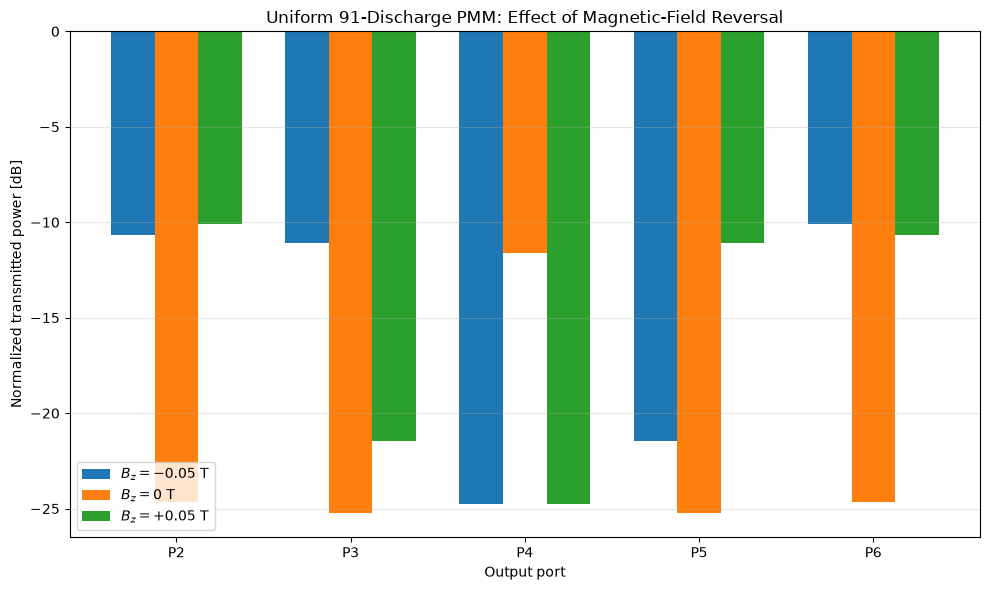


FIELD-REVERSAL CHECK
P2/P6 handedness reversal: PASS
P3/P5 handedness reversal: PASS

At B = 0, both asymmetries should also be close to zero.


In [28]:
# COMPARE B = -0.05 T, 0 T, +0.05 T
#
# Same:
#   91 bulbs
#   fp = 8 GHz
#   gamma = 1 MHz
#   Port 1 source = 3.85 GHz
#
# Only B changes.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Collect output-port powers
# ------------------------------------------------------------

ports = [
    "P2",
    "P3",
    "P4",
    "P5",
    "P6"
]

Bminus_power = np.array([
    T21_B,
    T31_B,
    T41_B,
    T51_B,
    T61_B
])

Bzero_power = np.array([
    T21,
    T31,
    T41,
    T51,
    T61
])

Bplus_power = np.array([
    T21_Brev,
    T31_Brev,
    T41_Brev,
    T51_Brev,
    T61_Brev
])


# ------------------------------------------------------------
# 2. Safe conversion to dB
# ------------------------------------------------------------

def safe_dB(x):

    x = np.asarray(
        x,
        dtype=float
    )

    return 10*np.log10(
        np.maximum(
            x,
            1e-20
        )
    )


Bminus_dB = safe_dB(
    Bminus_power
)

Bzero_dB = safe_dB(
    Bzero_power
)

Bplus_dB = safe_dB(
    Bplus_power
)


# ------------------------------------------------------------
# 3. Print numerical comparison
# ------------------------------------------------------------

print(
    "======================================================"
)

print(
    "PORT TRANSMISSION COMPARISON"
)

print(
    "======================================================"
)

print(
    "Port      -0.05 T       0 T        +0.05 T"
)


for i in range(5):

    print(
        f"{ports[i]:<5} "
        f"{Bminus_dB[i]:10.3f} "
        f"{Bzero_dB[i]:10.3f} "
        f"{Bplus_dB[i]:10.3f}"
    )


# ------------------------------------------------------------
# 4. Mirror-pair asymmetry
#
# Positive:
#     P2 > P6
#     or
#     P3 > P5
#
# Negative:
#     opposite handedness
# ------------------------------------------------------------

delta26 = np.array([

    Bminus_dB[0]
    - Bminus_dB[4],

    Bzero_dB[0]
    - Bzero_dB[4],

    Bplus_dB[0]
    - Bplus_dB[4]
])


delta35 = np.array([

    Bminus_dB[1]
    - Bminus_dB[3],

    Bzero_dB[1]
    - Bzero_dB[3],

    Bplus_dB[1]
    - Bplus_dB[3]
])


print()
print(
    "======================================================"
)

print(
    "MIRROR-PAIR ASYMMETRY"
)

print(
    "======================================================"
)

print(
    "                 -0.05 T      0 T      +0.05 T"
)

print(
    "P2 - P6 [dB]   ",
    np.round(
        delta26,
        3
    )
)

print(
    "P3 - P5 [dB]   ",
    np.round(
        delta35,
        3
    )
)


# ------------------------------------------------------------
# 5. Grouped bar plot
# ------------------------------------------------------------

x = np.arange(
    len(ports)
)

bar_width = 0.25


fig, ax = plt.subplots(
    figsize=(10,6)
)


ax.bar(
    x - bar_width,
    Bminus_dB,
    width=bar_width,
    label=r"$B_z=-0.05$ T"
)

ax.bar(
    x,
    Bzero_dB,
    width=bar_width,
    label=r"$B_z=0$ T"
)

ax.bar(
    x + bar_width,
    Bplus_dB,
    width=bar_width,
    label=r"$B_z=+0.05$ T"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    ports
)

ax.set_xlabel(
    "Output port"
)

ax.set_ylabel(
    "Normalized transmitted power [dB]"
)

ax.set_title(
    "Uniform 91-Discharge PMM: Effect of Magnetic-Field Reversal"
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Automatic qualitative check
# ------------------------------------------------------------

print()
print(
    "======================================================"
)

print(
    "FIELD-REVERSAL CHECK"
)

print(
    "======================================================"
)


if (
    np.sign(delta26[0])
    != np.sign(delta26[2])
):

    print(
        "P2/P6 handedness reversal: PASS"
    )

else:

    print(
        "P2/P6 handedness reversal: NOT CLEAR"
    )


if (
    np.sign(delta35[0])
    != np.sign(delta35[2])
):

    print(
        "P3/P5 handedness reversal: PASS"
    )

else:

    print(
        "P3/P5 handedness reversal: NOT CLEAR"
    )


print()
print(
    "At B = 0, both asymmetries should also be close to zero."
)

In [29]:
# REUSABLE SIX-PORT PMM DEVICE BUILDER
#
# Builds:
#   91-discharge hexagonal array
#   specified rho pattern
#   specified magnetic field B
#   six identical PEC horns
#
# Does NOT:
#   add a source
#   add monitors
#   run Meep
#
# This replaces all of the repeated geometry-building code.
# ============================================================

import numpy as np


def build_circulator_device(rho, B):
    """
    Build the six-port PlasMEEP circulator geometry.

    Parameters
    ----------
    rho : array-like, length 91
        Plasma design variables.

        In our current PMMCirculatorInverse implementation,
        rho maps directly to nondimensionalized plasma
        frequency when wp_max = 0.

    B : array-like, length 3
        Magnetic field in Tesla:
            [Bx, By, Bz]

    Returns
    -------
    pmm_device : PMMI
        PMMI wrapper containing the trainable-array definition.

    P_device : plasmeep.Plasmeep
        PlasMEEP object containing the actual Meep geometry.

    wp_values : ndarray
        Plasma frequencies assigned to the 91 discharges.
    """

    # --------------------------------------------------------
    # 1. Input checks
    # --------------------------------------------------------

    rho = np.asarray(
        rho,
        dtype=float
    ).flatten()

    B = np.asarray(
        B,
        dtype=float
    ).flatten()


    if len(rho) != 91:

        raise ValueError(
            f"Expected 91 rho values, got {len(rho)}."
        )


    if len(B) != 3:

        raise ValueError(
            f"B must contain [Bx, By, Bz], got {B}."
        )


    # --------------------------------------------------------
    # 2. Create PMMI object
    # --------------------------------------------------------

    pmm_device = PMMI(
        a=a,
        res=DEV_RES,
        nx=nx_ports,
        ny=ny_ports,
        dpml=dpml_ports,
        B=B
    )


    array_center_device = np.array([
        nx_ports / 2,
        ny_ports / 2
    ])


    # --------------------------------------------------------
    # 3. Create 91-element trainable array
    # --------------------------------------------------------

    pmm_device.Rod_Array_Hexagon_train(
        xy_cen=array_center_device,
        side_dim=6,
        r=r_plasma,
        d=d_exp,
        bulbs=False,
        uniform=True
    )


    assert len(
        pmm_device.train_elems
    ) == 91


    # --------------------------------------------------------
    # 4. rho --> plasma frequency
    # --------------------------------------------------------

    wp_values, elem_locations = (
        pmm_device.Scale_Rho_wp(
            rho,
            w_src=fs_a,
            wp_max=0,
            gamma=gamma_a
        )
    )


    assert len(
        wp_values
    ) == 91


    # --------------------------------------------------------
    # 5. Create PlasMEEP object
    # --------------------------------------------------------

    P_device = (
        pmm_device.Build_Sim()
    )


    # --------------------------------------------------------
    # 6. Add all 91 physical quartz/plasma bulbs
    # --------------------------------------------------------

    locs_device = np.asarray(
        pmm_device.train_elem_locs,
        dtype=float
    )


    for i in range(91):

        center_meep = np.array([

            locs_device[i, 0]
            - nx_ports/2,

            locs_device[i, 1]
            - ny_ports/2,

            0.0
        ])


        P_device.Add_Bulb(

            r_bulb=(
                r_bulb_inner,
                r_bulb_outer
            ),

            center=center_meep,

            wp=wp_values[i],

            gamma=gamma_a,

            axis=np.array([
                0,
                0,
                1
            ]),

            profile=0
        )


    # --------------------------------------------------------
    # 7. Add the same six PEC horns
    # --------------------------------------------------------

    for horn in full_horns:

        for name in [

            "left_flare",
            "right_flare",
            "left_feed",
            "right_feed"

        ]:

            wall = horn[name]


            vertices = np.zeros(
                (4, 3)
            )

            vertices[:, 0] = (
                wall[:, 0]
            )

            vertices[:, 1] = (
                wall[:, 1]
            )


            P_device.Add_Prism(

                vertices=vertices,

                axis=np.array([
                    0,
                    0,
                    1
                ]),

                PEC=True
            )


    # --------------------------------------------------------
    # 8. Return completed geometry
    # --------------------------------------------------------

    return (
        pmm_device,
        P_device,
        wp_values
    )


print(
    "build_circulator_device() defined."
)

print(
    "No Meep simulation was run."
)

build_circulator_device() defined.
No Meep simulation was run.


In [30]:
# GENERIC ROTATED PORT SOURCE
#
# Purpose:
#   Allow any of the 6 horns to act as the source.
#
# Needed next for:
#       P1 -> P2
#       versus
#       P2 -> P1
#
# This cell only defines the helper.
# It does NOT run a simulation.
# ============================================================

import meep as mp
import numpy as np


def make_port_source(
    port_index,
    frequency=fs_a,
    fwidth=source_df,
    n_points=31
):
    """
    Create an Hz source across the straight feed of any port.

    Parameters
    ----------
    port_index : int
        Python index:
            0 = P1
            1 = P2
            ...
            5 = P6

    frequency : float
        Meep frequency.

    fwidth : float
        Gaussian-source bandwidth.

    n_points : int
        Number of point sources used to approximate
        the rotated source line.

    Returns
    -------
    sources : list
        List of mp.Source objects.
    """

    # --------------------------------------------------------
    # 1. Source center for this port
    #
    # Every full_horns entry already contains a source-center
    # location farther outward than its monitor.
    # --------------------------------------------------------

    center = np.asarray(
        full_horns[port_index]["source_center"],
        dtype=float
    )


    # --------------------------------------------------------
    # 2. Port axis
    #
    # port_dirs points OUTWARD from the PMM.
    # --------------------------------------------------------

    u = np.asarray(
        port_dirs[port_index],
        dtype=float
    )

    u = (
        u /
        np.linalg.norm(u)
    )


    # --------------------------------------------------------
    # 3. Direction ACROSS the waveguide
    # --------------------------------------------------------

    tangent = np.array([
        -u[1],
         u[0]
    ])


    # --------------------------------------------------------
    # 4. Keep sources inside the PEC walls
    # --------------------------------------------------------

    source_span = (
        0.96
        * clear_width
    )


    offsets = np.linspace(
        -source_span/2,
        +source_span/2,
        n_points
    )


    # --------------------------------------------------------
    # 5. Build a line from closely spaced Hz point sources
    # --------------------------------------------------------

    sources = []


    for s in offsets:

        xy = (
            center
            + s*tangent
        )


        src = mp.Source(

            src=mp.GaussianSource(
                frequency=frequency,
                fwidth=fwidth
            ),

            component=mp.Hz,

            center=mp.Vector3(
                xy[0],
                xy[1],
                0
            ),

            amplitude=1.0/n_points
        )


        sources.append(
            src
        )


    return sources


# ============================================================
# QUICK GEOMETRY CHECK -- NO MEEP RUN
# ============================================================

print(
    "Generic six-port source helper defined."
)

print()


for i in range(6):

    test_sources = make_port_source(
        i
    )

    print(
        f"P{i+1}: "
        f"{len(test_sources)} source points, "
        f"center = "
        f"{np.round(full_horns[i]['source_center'], 3)}"
    )


print()
print(
    "No simulation was run."
)

Generic six-port source helper defined.

P1: 31 source points, center = [8.039 0.   ]
P2: 31 source points, center = [4.02  6.962]
P3: 31 source points, center = [-4.02   6.962]
P4: 31 source points, center = [-8.039  0.   ]
P5: 31 source points, center = [-4.02  -6.962]
P6: 31 source points, center = [ 4.02  -6.962]

No simulation was run.


In [31]:
# B = 0 RECIPROCITY TEST
#
# Previous:
#       P1 --> P2 = T21
#
# This cell:
#       P2 --> P1 = T12
#
# For an unmagnetized reciprocal device, we expect:
#
#       T12 ≈ T21
#
# This cell performs:
#   1. P2 straight-feed normalization run
#   2. P2 -> six-port device run
#   3. incident-field subtraction at P2
#   4. comparison of T12 and T21
# ============================================================

import meep as mp
import numpy as np


# ============================================================
# PART A — P2 REFERENCE / NORMALIZATION RUN
# ============================================================

source_port = 1          # Python index 1 = physical Port 2


print(
    "========================================"
)
print(
    "P2 NORMALIZATION RUN"
)
print(
    "========================================"
)


# ------------------------------------------------------------
# 1. Port-2 orientation
# ------------------------------------------------------------

u2 = np.asarray(
    port_dirs[source_port],
    dtype=float
)

u2 = (
    u2 /
    np.linalg.norm(u2)
)


# Direction across the feed
n2 = np.array([
    -u2[1],
     u2[0]
])


print(
    "P2 outward direction =",
    np.round(u2, 6)
)


# ------------------------------------------------------------
# 2. Build EMPTY reference simulation
#
# Same:
#   cell size
#   resolution
#   PML
#
# No bulbs and no six-port scattering structure.
# ------------------------------------------------------------

pmm_ref2 = PMMI(
    a=a,
    res=DEV_RES,
    nx=nx_ports,
    ny=ny_ports,
    dpml=dpml_ports,
    B=np.array([
        0.0,
        0.0,
        0.0
    ])
)


P_ref2 = (
    pmm_ref2.Build_Sim()
)


# ------------------------------------------------------------
# 3. Make a long straight PEC feed oriented exactly like P2
#
# clear_width = open region between PEC walls
#
# Each wall has thickness = wall_thickness.
# ------------------------------------------------------------

reference_center = np.asarray(
    full_horns[source_port]["source_center"],
    dtype=float
)


# Make it longer than the entire computational cell.
guide_length = (
    2.0
    * np.hypot(
        nx_ports,
        ny_ports
    )
)


half_length = (
    guide_length / 2
)


# Distance from centerline to CENTER of each PEC wall
wall_center_offset = (
    clear_width/2
    + wall_thickness/2
)


# ------------------------------------------------------------
# Helper for one rotated rectangular PEC wall
# ------------------------------------------------------------

def rotated_wall(
    centerline,
    axis,
    normal,
    normal_offset,
    length,
    thickness
):

    wall_center = (
        centerline
        + normal_offset*normal
    )


    p1 = (
        wall_center
        - axis*length/2
        - normal*thickness/2
    )

    p2 = (
        wall_center
        + axis*length/2
        - normal*thickness/2
    )

    p3 = (
        wall_center
        + axis*length/2
        + normal*thickness/2
    )

    p4 = (
        wall_center
        - axis*length/2
        + normal*thickness/2
    )


    vertices = np.zeros(
        (4,3)
    )

    vertices[:,0:2] = np.array([
        p1,
        p2,
        p3,
        p4
    ])

    return vertices


# Upper/left wall
ref2_wall_A = rotated_wall(
    centerline=reference_center,
    axis=u2,
    normal=n2,
    normal_offset=+wall_center_offset,
    length=guide_length,
    thickness=wall_thickness
)


# Lower/right wall
ref2_wall_B = rotated_wall(
    centerline=reference_center,
    axis=u2,
    normal=n2,
    normal_offset=-wall_center_offset,
    length=guide_length,
    thickness=wall_thickness
)


P_ref2.Add_Prism(
    vertices=ref2_wall_A,
    axis=np.array([
        0,
        0,
        1
    ]),
    PEC=True
)


P_ref2.Add_Prism(
    vertices=ref2_wall_B,
    axis=np.array([
        0,
        0,
        1
    ]),
    PEC=True
)


# ------------------------------------------------------------
# 4. Create the P2 source
#
# Uses make_port_source() from the previous cell.
# ------------------------------------------------------------

p2_sources = make_port_source(
    source_port
)


P_ref2.sources = (
    p2_sources
)


# ------------------------------------------------------------
# 5. Build reference Meep simulation
# ------------------------------------------------------------

ref2_sim = (
    P_ref2.Get_Sim()
)


# ------------------------------------------------------------
# 6. Put normalization monitor at the SAME P2 monitor
# location used in the device.
# ------------------------------------------------------------

ref2_region, ref2_sign = make_flux_region(
    port_monitor_centers[source_port],
    port_dirs[source_port]
)


ref2_monitor = ref2_sim.add_flux(
    fs_a,
    0,
    1,
    ref2_region
)


# ------------------------------------------------------------
# 7. Run reference simulation
# ------------------------------------------------------------

print()
print(
    "Running straight P2 reference..."
)


ref2_sim.run(
    until_after_sources=80
)


print(
    "P2 reference complete."
)


# ------------------------------------------------------------
# 8. Incident P2 power
# ------------------------------------------------------------

ref2_raw_flux = (
    mp.get_fluxes(
        ref2_monitor
    )[0]
)


ref2_outward_flux = (
    ref2_sign
    * ref2_raw_flux
)


incident_power_P2 = abs(
    ref2_outward_flux
)


print()
print(
    "P2 signed reference flux =",
    ref2_outward_flux
)

print(
    "P2 incident power =",
    incident_power_P2
)


if ref2_outward_flux < 0:

    print(
        "P2 direction check: PASS"
    )

else:

    print(
        "WARNING: P2 incident flux sign is not as expected."
    )


# ------------------------------------------------------------
# 9. Save P2 incident Fourier fields
#
# Needed to remove the incident wave from P2 reflection.
# ------------------------------------------------------------

p2_incident_flux_data = (
    ref2_sim.get_flux_data(
        ref2_monitor
    )
)


print(
    "Saved P2 incident-field data."
)



# ============================================================
# PART B — ACTUAL SIX-PORT DEVICE WITH P2 EXCITATION
# ============================================================

print()
print(
    "========================================"
)
print(
    "P2 -> SIX-PORT DEVICE RUN"
)
print(
    "B = 0 T"
)
print(
    "========================================"
)


# ------------------------------------------------------------
# 10. Put P2 source into existing B=0 six-port geometry
# ------------------------------------------------------------

P_ports.sources = (
    p2_sources
)


p2_device_sim = (
    P_ports.Get_Sim()
)


# ------------------------------------------------------------
# 11. Add all six flux monitors
# ------------------------------------------------------------

p2_monitors = []

p2_signs = []


for i in range(6):

    region, sign = make_flux_region(
        port_monitor_centers[i],
        port_dirs[i]
    )


    monitor = p2_device_sim.add_flux(
        fs_a,
        0,
        1,
        region
    )


    p2_monitors.append(
        monitor
    )

    p2_signs.append(
        sign
    )


# ------------------------------------------------------------
# 12. Remove incident P2 field from the P2 monitor
# ------------------------------------------------------------

p2_device_sim.load_minus_flux_data(
    p2_monitors[source_port],
    p2_incident_flux_data
)


# ------------------------------------------------------------
# 13. Run device
# ------------------------------------------------------------

print()
print(
    "Running P2 -> device..."
)


p2_device_sim.run(
    until_after_sources=80
)


print(
    "P2 device run complete."
)


# ------------------------------------------------------------
# 14. Extract signed outward flux at every port
# ------------------------------------------------------------

flux_from_P2 = np.zeros(
    6
)


for i in range(6):

    raw = mp.get_fluxes(
        p2_monitors[i]
    )[0]


    flux_from_P2[i] = (
        p2_signs[i]
        * raw
    )


# ------------------------------------------------------------
# 15. Normalize by P2 incident power
# ------------------------------------------------------------

T12 = (
    flux_from_P2[0]
    / incident_power_P2
)


R22 = (
    flux_from_P2[1]
    / incident_power_P2
)


T32 = (
    flux_from_P2[2]
    / incident_power_P2
)


T42 = (
    flux_from_P2[3]
    / incident_power_P2
)


T52 = (
    flux_from_P2[4]
    / incident_power_P2
)


T62 = (
    flux_from_P2[5]
    / incident_power_P2
)


# ------------------------------------------------------------
# 16. Print complete P2 column
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "NORMALIZED P2 INPUT RESULTS"
)

print(
    "========================================"
)


print(
    f"T12 = {T12:.6e}   "
    f"({power_to_dB(T12): .2f} dB)"
)


print(
    f"R22 = {R22:.6e}   "
    f"({power_to_dB(R22): .2f} dB)"
)


print(
    f"T32 = {T32:.6e}   "
    f"({power_to_dB(T32): .2f} dB)"
)


print(
    f"T42 = {T42:.6e}   "
    f"({power_to_dB(T42): .2f} dB)"
)


print(
    f"T52 = {T52:.6e}   "
    f"({power_to_dB(T52): .2f} dB)"
)


print(
    f"T62 = {T62:.6e}   "
    f"({power_to_dB(T62): .2f} dB)"
)



# ============================================================
# PART C — RECIPROCITY CHECK
# ============================================================

print()
print(
    "========================================"
)

print(
    "B = 0 RECIPROCITY CHECK"
)

print(
    "========================================"
)


print(
    f"P1 -> P2 : T21 = "
    f"{power_to_dB(T21): .3f} dB"
)


print(
    f"P2 -> P1 : T12 = "
    f"{power_to_dB(T12): .3f} dB"
)


reciprocity_difference_dB = abs(

    power_to_dB(T21)

    - power_to_dB(T12)
)


print()
print(
    "Difference =",
    reciprocity_difference_dB,
    "dB"
)


# Linear relative difference
reciprocity_relative_error = (

    2*abs(
        T21-T12
    )

    /
    (
        abs(T21)
        + abs(T12)
    )

)


print(
    "Relative difference =",
    reciprocity_relative_error
)


print()
print(
    "Expected for B = 0:"
)

print(
    "T21 ≈ T12"
)

P2 NORMALIZATION RUN
P2 outward direction = [0.5      0.866025]

Running straight P2 reference...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000368834 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     prism, center = (3.33924,7.35516,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-12.1713,-19.6528,0)
          (18.9735,34.2917,0)
          (18.8498,34.3631,0)
          (-12.295,-19.5813,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (4.70014,6.56945,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-10.8104,-20.4385,0)
          (20.3344,33.5059,0)
          (20.2107,33.5774,0)
          (-10.9341,-20.367,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
subpixel-averaging is 75.7928% done, 1.27799 s remaining
subpixel-averaging is 75.9442% done, 1.26704 s r

In [32]:
# NONRECIPROCITY TEST AT Bz = -0.05 T
#
# Already have:
#
#   T21_B
#       P1 --> P2 at B = -0.05 T
#
# Now calculate:
#
#   T12_B
#       P2 --> P1 at B = -0.05 T
#
# For a nonreciprocal device:
#
#       T21_B != T12_B
# ============================================================


source_port = 1      # Python index 1 = physical Port 2


# ------------------------------------------------------------
# 1. Create fresh P2 source
# ------------------------------------------------------------

p2_sources_B = make_port_source(
    source_port
)


# ------------------------------------------------------------
# 2. Put P2 source into the existing B = -0.05 T geometry
#
# P_B already contains:
#   91 magnetized bulbs
#   six horns
#   Bz = -0.05 T
# ------------------------------------------------------------

P_B.sources = (
    p2_sources_B
)


# Fresh Meep simulation
p2_B_sim = (
    P_B.Get_Sim()
)


# ------------------------------------------------------------
# 3. Add all six port monitors
# ------------------------------------------------------------

p2_B_monitors = []

p2_B_signs = []


for i in range(6):

    region, sign = make_flux_region(
        port_monitor_centers[i],
        port_dirs[i]
    )


    monitor = p2_B_sim.add_flux(
        fs_a,
        0,
        1,
        region
    )


    p2_B_monitors.append(
        monitor
    )

    p2_B_signs.append(
        sign
    )


# ------------------------------------------------------------
# 4. Remove the incident P2 field
#
# We can reuse the P2 straight-feed reference because
# the reference feed contains no plasma.
# ------------------------------------------------------------

p2_B_sim.load_minus_flux_data(
    p2_B_monitors[source_port],
    p2_incident_flux_data
)


# ------------------------------------------------------------
# 5. Run
# ------------------------------------------------------------

print(
    "Running P2 excitation at Bz = -0.05 T..."
)


p2_B_sim.run(
    until_after_sources=80
)


print(
    "P2 magnetized run complete."
)


# ------------------------------------------------------------
# 6. Extract outward flux from all six ports
# ------------------------------------------------------------

flux_from_P2_B = np.zeros(
    6
)


for i in range(6):

    raw = mp.get_fluxes(
        p2_B_monitors[i]
    )[0]


    flux_from_P2_B[i] = (
        p2_B_signs[i]
        * raw
    )


# ------------------------------------------------------------
# 7. Normalize by P2 incident power
# ------------------------------------------------------------

T12_B = (
    flux_from_P2_B[0]
    / incident_power_P2
)


R22_B = (
    flux_from_P2_B[1]
    / incident_power_P2
)


T32_B = (
    flux_from_P2_B[2]
    / incident_power_P2
)


T42_B = (
    flux_from_P2_B[3]
    / incident_power_P2
)


T52_B = (
    flux_from_P2_B[4]
    / incident_power_P2
)


T62_B = (
    flux_from_P2_B[5]
    / incident_power_P2
)


# ------------------------------------------------------------
# 8. Print P2-input results
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "P2 INPUT — Bz = -0.05 T"
)

print(
    "========================================"
)


print(
    f"T12 = {power_to_dB(T12_B): .3f} dB"
)

print(
    f"R22 = {power_to_dB(R22_B): .3f} dB"
)

print(
    f"T32 = {power_to_dB(T32_B): .3f} dB"
)

print(
    f"T42 = {power_to_dB(T42_B): .3f} dB"
)

print(
    f"T52 = {power_to_dB(T52_B): .3f} dB"
)

print(
    f"T62 = {power_to_dB(T62_B): .3f} dB"
)


# ------------------------------------------------------------
# 9. DIRECT NONRECIPROCITY TEST
#
# Compare:
#
#   P1 --> P2 = T21_B
#   P2 --> P1 = T12_B
#
# at the SAME magnetic field.
# ------------------------------------------------------------

T21_B_dB = (
    power_to_dB(T21_B)
)

T12_B_dB = (
    power_to_dB(T12_B)
)


nonreciprocity_12_dB = (
    T21_B_dB
    - T12_B_dB
)


print()
print(
    "========================================"
)

print(
    "DIRECT NONRECIPROCITY CHECK"
)

print(
    "Bz = -0.05 T"
)

print(
    "========================================"
)


print(
    f"P1 -> P2 : {T21_B_dB: .3f} dB"
)

print(
    f"P2 -> P1 : {T12_B_dB: .3f} dB"
)


print()
print(
    "T21 - T12 =",
    nonreciprocity_12_dB,
    "dB"
)


# ------------------------------------------------------------
# 10. Compare to B = 0 reciprocity result
# ------------------------------------------------------------

zero_field_difference = abs(
    power_to_dB(T21)
    - power_to_dB(T12)
)


magnetized_difference = abs(
    nonreciprocity_12_dB
)


print()
print(
    "========================================"
)

print(
    "B = 0 vs B = -0.05 T"
)

print(
    "========================================"
)


print(
    "B = 0 reciprocity difference:",
    zero_field_difference,
    "dB"
)


print(
    "B = -0.05 T directional difference:",
    magnetized_difference,
    "dB"
)

-----------
Initializing structure...
time for choose_chunkdivision = 0.0029161 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.164286, heig

In [33]:
# FIELD-REVERSAL NONRECIPROCITY TEST
#
# Now calculate:
#
#       P2 --> P1 at Bz = +0.05 T
#
# We will then compare:
#
#   T21(-B)  vs  T12(+B)
#   T12(-B)  vs  T21(+B)
#
# These should approximately swap under B reversal.
# ============================================================


source_port = 1      # Python index 1 = physical Port 2


# ------------------------------------------------------------
# 1. Same P2 source
# ------------------------------------------------------------

p2_sources_Brev = make_port_source(
    source_port
)


# ------------------------------------------------------------
# 2. Put P2 source into existing B = +0.05 T geometry
#
# P_Brev already contains:
#   91 magnetized bulbs
#   six horns
#   Bz = +0.05 T
# ------------------------------------------------------------

P_Brev.sources = (
    p2_sources_Brev
)


p2_Brev_sim = (
    P_Brev.Get_Sim()
)


# ------------------------------------------------------------
# 3. Add all six port monitors
# ------------------------------------------------------------

p2_Brev_monitors = []
p2_Brev_signs = []


for i in range(6):

    region, sign = make_flux_region(
        port_monitor_centers[i],
        port_dirs[i]
    )


    monitor = p2_Brev_sim.add_flux(
        fs_a,
        0,
        1,
        region
    )


    p2_Brev_monitors.append(
        monitor
    )

    p2_Brev_signs.append(
        sign
    )


# ------------------------------------------------------------
# 4. Remove incident P2 field
#
# Same straight-feed normalization is valid because
# the reference guide itself contains no plasma.
# ------------------------------------------------------------

p2_Brev_sim.load_minus_flux_data(
    p2_Brev_monitors[source_port],
    p2_incident_flux_data
)


# ------------------------------------------------------------
# 5. Run
# ------------------------------------------------------------

print(
    "Running P2 excitation at Bz = +0.05 T..."
)


p2_Brev_sim.run(
    until_after_sources=80
)


print(
    "P2 reverse-B run complete."
)


# ------------------------------------------------------------
# 6. Extract outward flux
# ------------------------------------------------------------

flux_from_P2_Brev = np.zeros(
    6
)


for i in range(6):

    raw = mp.get_fluxes(
        p2_Brev_monitors[i]
    )[0]


    flux_from_P2_Brev[i] = (
        p2_Brev_signs[i]
        * raw
    )


# ------------------------------------------------------------
# 7. Normalize by P2 incident power
# ------------------------------------------------------------

T12_Brev = (
    flux_from_P2_Brev[0]
    / incident_power_P2
)


R22_Brev = (
    flux_from_P2_Brev[1]
    / incident_power_P2
)


T32_Brev = (
    flux_from_P2_Brev[2]
    / incident_power_P2
)


T42_Brev = (
    flux_from_P2_Brev[3]
    / incident_power_P2
)


T52_Brev = (
    flux_from_P2_Brev[4]
    / incident_power_P2
)


T62_Brev = (
    flux_from_P2_Brev[5]
    / incident_power_P2
)


# ------------------------------------------------------------
# 8. Print P2-input result
# ------------------------------------------------------------

print()
print(
    "========================================"
)

print(
    "P2 INPUT — Bz = +0.05 T"
)

print(
    "========================================"
)


print(
    f"T12 = {power_to_dB(T12_Brev): .3f} dB"
)

print(
    f"R22 = {power_to_dB(R22_Brev): .3f} dB"
)

print(
    f"T32 = {power_to_dB(T32_Brev): .3f} dB"
)

print(
    f"T42 = {power_to_dB(T42_Brev): .3f} dB"
)

print(
    f"T52 = {power_to_dB(T52_Brev): .3f} dB"
)

print(
    f"T62 = {power_to_dB(T62_Brev): .3f} dB"
)


# ============================================================
# 9. SAME-B DIRECTIONAL COMPARISON
# ============================================================

print()
print(
    "========================================"
)

print(
    "DIRECT NONRECIPROCITY — Bz = +0.05 T"
)

print(
    "========================================"
)


print(
    f"P1 -> P2 : "
    f"{power_to_dB(T21_Brev): .3f} dB"
)

print(
    f"P2 -> P1 : "
    f"{power_to_dB(T12_Brev): .3f} dB"
)


nonreciprocity_plusB_dB = (

    power_to_dB(T21_Brev)

    - power_to_dB(T12_Brev)

)


print()
print(
    "T21 - T12 =",
    nonreciprocity_plusB_dB,
    "dB"
)


# ============================================================
# 10. FIELD-REVERSAL CHECK
#
# The especially useful comparison:
#
#       T21(-B)  ~  T12(+B)
#
#       T12(-B)  ~  T21(+B)
# ============================================================

print()
print(
    "========================================"
)

print(
    "FIELD-REVERSAL RELATION"
)

print(
    "========================================"
)


print()
print(
    "PAIR 1"
)

print(
    f"T21(-0.05 T) = "
    f"{power_to_dB(T21_B): .3f} dB"
)

print(
    f"T12(+0.05 T) = "
    f"{power_to_dB(T12_Brev): .3f} dB"
)


pair1_error = abs(

    power_to_dB(T21_B)

    - power_to_dB(T12_Brev)

)


print(
    "difference =",
    pair1_error,
    "dB"
)


print()
print(
    "PAIR 2"
)

print(
    f"T12(-0.05 T) = "
    f"{power_to_dB(T12_B): .3f} dB"
)

print(
    f"T21(+0.05 T) = "
    f"{power_to_dB(T21_Brev): .3f} dB"
)


pair2_error = abs(

    power_to_dB(T12_B)

    - power_to_dB(T21_Brev)

)


print(
    "difference =",
    pair2_error,
    "dB"
)


# ============================================================
# 11. Compare directional asymmetry at -B and +B
# ============================================================

minusB_asymmetry = (

    power_to_dB(T21_B)

    - power_to_dB(T12_B)

)


plusB_asymmetry = (

    power_to_dB(T21_Brev)

    - power_to_dB(T12_Brev)

)


print()
print(
    "========================================"
)

print(
    "ASYMMETRY REVERSAL"
)

print(
    "========================================"
)


print(
    f"B = -0.05 T : "
    f"T21 - T12 = "
    f"{minusB_asymmetry: .3f} dB"
)


print(
    f"B = +0.05 T : "
    f"T21 - T12 = "
    f"{plusB_asymmetry: .3f} dB"
)


print()


if (
    np.sign(minusB_asymmetry)
    != np.sign(plusB_asymmetry)
):

    print(
        "Directional asymmetry reversed with B: PASS"
    )

else:

    print(
        "Directional asymmetry reversal: NOT CLEAR"
    )

-----------
Initializing structure...
time for choose_chunkdivision = 0.003021 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.164286, heigh

P1 <-> P2 MAGNETIC-FIELD COMPARISON
 Bz [T]       T21 [dB]      T12 [dB]      T21-T12 [dB]
 -0.050        -10.671         -8.764           -1.907
 +0.000        -24.637        -23.000           -1.638
 +0.050        -10.089         -7.412           -2.677


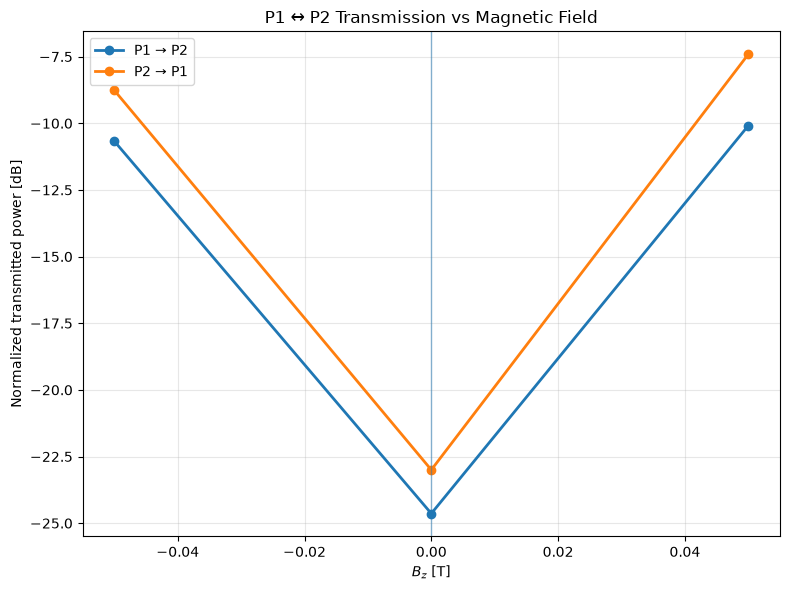

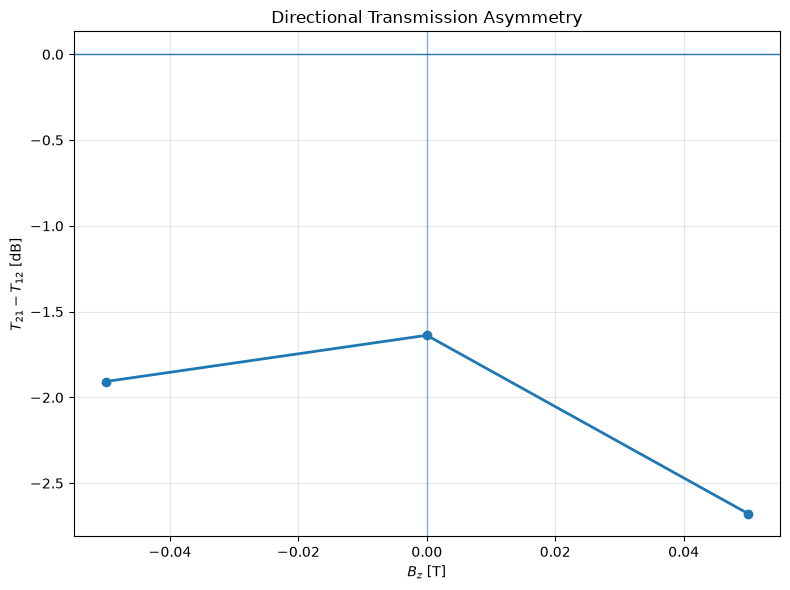


VALIDATION SUMMARY
B = 0 reciprocity error = 1.6378764252828049 dB
B-reversal antisymmetry error = 4.58436950315473 dB

Directional differences:
  -0.05 T : -1.907 dB
   0.00 T : -1.638 dB
  +0.05 T : -2.677 dB

Directional preference reversal: NOT CLEAR


In [34]:
# SUMMARY: T21 AND T12 VERSUS MAGNETIC FIELD
#
# Compare:
#
#   P1 -> P2 : T21
#   P2 -> P1 : T12
#
# for:
#
#   Bz = -0.05 T
#   Bz =  0.00 T
#   Bz = +0.05 T
#
# At B = 0:
#       T21 ≈ T12
#
# At B != 0:
#       T21 and T12 may separate
#
# Reversing B should reverse the directional behavior.
# ============================================================


# ------------------------------------------------------------
# 1. Magnetic-field values
# ------------------------------------------------------------

B_values = np.array([
    -0.05,
     0.00,
    +0.05
])


# ------------------------------------------------------------
# 2. Collect P1 -> P2 transmission
# ------------------------------------------------------------

T21_values = np.array([
    T21_B,
    T21,
    T21_Brev
])


# ------------------------------------------------------------
# 3. Collect P2 -> P1 transmission
# ------------------------------------------------------------

T12_values = np.array([
    T12_B,
    T12,
    T12_Brev
])


# ------------------------------------------------------------
# 4. Convert to dB
# ------------------------------------------------------------

T21_values_dB = np.array([
    power_to_dB(x)
    for x in T21_values
])


T12_values_dB = np.array([
    power_to_dB(x)
    for x in T12_values
])


# ------------------------------------------------------------
# 5. Directional difference
#
# Positive:
#       P1 -> P2 transmits more strongly
#
# Negative:
#       P2 -> P1 transmits more strongly
# ------------------------------------------------------------

delta_12_dB = (
    T21_values_dB
    - T12_values_dB
)


# ------------------------------------------------------------
# 6. Print table
# ------------------------------------------------------------

print(
    "======================================================"
)

print(
    "P1 <-> P2 MAGNETIC-FIELD COMPARISON"
)

print(
    "======================================================"
)

print(
    " Bz [T]       T21 [dB]      T12 [dB]      T21-T12 [dB]"
)


for i in range(3):

    print(
        f"{B_values[i]:+7.3f}      "
        f"{T21_values_dB[i]:9.3f}      "
        f"{T12_values_dB[i]:9.3f}      "
        f"{delta_12_dB[i]:11.3f}"
    )


# ------------------------------------------------------------
# 7. Plot T21 and T12
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    B_values,
    T21_values_dB,
    marker="o",
    linewidth=2,
    label="P1 → P2"
)


ax.plot(
    B_values,
    T12_values_dB,
    marker="o",
    linewidth=2,
    label="P2 → P1"
)


ax.axvline(
    0,
    linewidth=1,
    alpha=0.5
)


ax.set_xlabel(
    r"$B_z$ [T]"
)


ax.set_ylabel(
    "Normalized transmitted power [dB]"
)


ax.set_title(
    "P1 ↔ P2 Transmission vs Magnetic Field"
)


ax.grid(
    alpha=0.3
)


ax.legend()


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Plot directional asymmetry
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    B_values,
    delta_12_dB,
    marker="o",
    linewidth=2
)


ax.axhline(
    0,
    linewidth=1
)


ax.axvline(
    0,
    linewidth=1,
    alpha=0.5
)


ax.set_xlabel(
    r"$B_z$ [T]"
)


ax.set_ylabel(
    r"$T_{21} - T_{12}$ [dB]"
)


ax.set_title(
    "Directional Transmission Asymmetry"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Quantitative checks
# ------------------------------------------------------------

zero_field_error = abs(
    delta_12_dB[1]
)


reversal_error = abs(
    delta_12_dB[0]
    + delta_12_dB[2]
)


print()
print(
    "======================================================"
)

print(
    "VALIDATION SUMMARY"
)

print(
    "======================================================"
)


print(
    "B = 0 reciprocity error =",
    zero_field_error,
    "dB"
)


print(
    "B-reversal antisymmetry error =",
    reversal_error,
    "dB"
)


print()
print(
    "Directional differences:"
)


print(
    f"  -0.05 T : {delta_12_dB[0]: .3f} dB"
)


print(
    f"   0.00 T : {delta_12_dB[1]: .3f} dB"
)


print(
    f"  +0.05 T : {delta_12_dB[2]: .3f} dB"
)


# ------------------------------------------------------------
# 10. Basic handedness check
# ------------------------------------------------------------

if (
    np.sign(delta_12_dB[0])
    != np.sign(delta_12_dB[2])
):

    print()
    print(
        "Directional preference reverses with B: PASS"
    )

else:

    print()
    print(
        "Directional preference reversal: NOT CLEAR"
    )

In [35]:
# FULL 6 x 6 PORT-POWER MATRIX AT B = 0
#
# Matrix convention:
#
#       row    = OUTPUT port
#       column = INPUT port
#
# Example:
#
#       power_matrix_B0[1,0]
#
#       = P1 --> P2
#       = T21
#
# We already have the P1 and P2 input columns.
# This cell calculates P3, P4, P5, and P6 inputs.
#
# IMPORTANT:
# This is a normalized POWER matrix, not yet the
# complex-amplitude S-matrix.
# ============================================================


# ------------------------------------------------------------
# 1. Initialize 6 x 6 matrix
# ------------------------------------------------------------

power_matrix_B0 = np.full(
    (6,6),
    np.nan
)


# ------------------------------------------------------------
# 2. Insert the P1-input column we already calculated
# ------------------------------------------------------------

power_matrix_B0[:,0] = np.array([
    R11,
    T21,
    T31,
    T41,
    T51,
    T61
])


# ------------------------------------------------------------
# 3. Insert the P2-input column we already calculated
# ------------------------------------------------------------

power_matrix_B0[:,1] = np.array([
    T12,
    R22,
    T32,
    T42,
    T52,
    T62
])


# ------------------------------------------------------------
# 4. Keep normalization information for every source port
# ------------------------------------------------------------

incident_power_by_port = {
    0: incident_power,
    1: incident_power_P2
}


incident_flux_data_by_port = {
    0: p1_incident_flux_data,
    1: p2_incident_flux_data
}


# ============================================================
# 5. Function to calculate ONE new B = 0 matrix column
# ============================================================

def run_B0_port_column(source_port):

    print()
    print(
        "======================================================"
    )

    print(
        f"INPUT PORT P{source_port+1}"
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # PORT ORIENTATION
    # --------------------------------------------------------

    u = np.asarray(
        port_dirs[source_port],
        dtype=float
    )

    u = (
        u /
        np.linalg.norm(u)
    )


    n = np.array([
        -u[1],
         u[0]
    ])


    # ========================================================
    # PART A — STRAIGHT-FEED NORMALIZATION
    # ========================================================

    pmm_ref_i = PMMI(
        a=a,
        res=DEV_RES,
        nx=nx_ports,
        ny=ny_ports,
        dpml=dpml_ports,
        B=np.array([
            0.0,
            0.0,
            0.0
        ])
    )


    P_ref_i = (
        pmm_ref_i.Build_Sim()
    )


    reference_center = np.asarray(
        full_horns[source_port]["source_center"],
        dtype=float
    )


    guide_length = (
        2.0
        * np.hypot(
            nx_ports,
            ny_ports
        )
    )


    wall_center_offset = (
        clear_width/2
        + wall_thickness/2
    )


    # --------------------------------------------------------
    # Two PEC walls defining the straight reference feed
    # --------------------------------------------------------

    ref_wall_A = rotated_wall(
        centerline=reference_center,
        axis=u,
        normal=n,
        normal_offset=+wall_center_offset,
        length=guide_length,
        thickness=wall_thickness
    )


    ref_wall_B = rotated_wall(
        centerline=reference_center,
        axis=u,
        normal=n,
        normal_offset=-wall_center_offset,
        length=guide_length,
        thickness=wall_thickness
    )


    P_ref_i.Add_Prism(
        vertices=ref_wall_A,
        axis=np.array([
            0,
            0,
            1
        ]),
        PEC=True
    )


    P_ref_i.Add_Prism(
        vertices=ref_wall_B,
        axis=np.array([
            0,
            0,
            1
        ]),
        PEC=True
    )


    # --------------------------------------------------------
    # Source at this port
    # --------------------------------------------------------

    ref_sources = make_port_source(
        source_port
    )


    P_ref_i.sources = (
        ref_sources
    )


    ref_sim_i = (
        P_ref_i.Get_Sim()
    )


    # --------------------------------------------------------
    # Reference monitor
    # --------------------------------------------------------

    ref_region_i, ref_sign_i = make_flux_region(
        port_monitor_centers[source_port],
        port_dirs[source_port]
    )


    ref_monitor_i = ref_sim_i.add_flux(
        fs_a,
        0,
        1,
        ref_region_i
    )


    # --------------------------------------------------------
    # Run normalization
    # --------------------------------------------------------

    print(
        f"Running P{source_port+1} reference..."
    )


    ref_sim_i.run(
        until_after_sources=80
    )


    ref_raw_i = (
        mp.get_fluxes(
            ref_monitor_i
        )[0]
    )


    ref_outward_i = (
        ref_sign_i
        * ref_raw_i
    )


    incident_i = abs(
        ref_outward_i
    )


    print(
        "signed incident flux =",
        ref_outward_i
    )

    print(
        "incident power =",
        incident_i
    )


    if ref_outward_i < 0:

        print(
            "Direction check: PASS"
        )

    else:

        print(
            "WARNING: incident flux direction is unexpected."
        )


    # --------------------------------------------------------
    # Save incident Fourier fields for reflection subtraction
    # --------------------------------------------------------

    incident_data_i = (
        ref_sim_i.get_flux_data(
            ref_monitor_i
        )
    )


    # ========================================================
    # PART B — ACTUAL SIX-PORT DEVICE
    # ========================================================

    print()
    print(
        f"Running P{source_port+1} -> six-port device..."
    )


    device_sources = make_port_source(
        source_port
    )


    P_ports.sources = (
        device_sources
    )


    device_sim_i = (
        P_ports.Get_Sim()
    )


    # --------------------------------------------------------
    # Six device monitors
    # --------------------------------------------------------

    monitors_i = []
    signs_i = []


    for output_port in range(6):

        region, sign = make_flux_region(
            port_monitor_centers[output_port],
            port_dirs[output_port]
        )


        monitor = device_sim_i.add_flux(
            fs_a,
            0,
            1,
            region
        )


        monitors_i.append(
            monitor
        )

        signs_i.append(
            sign
        )


    # --------------------------------------------------------
    # Remove incident field from SOURCE-port monitor
    #
    # This leaves reflection at the diagonal entry.
    # --------------------------------------------------------

    device_sim_i.load_minus_flux_data(
        monitors_i[source_port],
        incident_data_i
    )


    # --------------------------------------------------------
    # Run device
    # --------------------------------------------------------

    device_sim_i.run(
        until_after_sources=80
    )


    # --------------------------------------------------------
    # Extract signed outward power
    # --------------------------------------------------------

    flux_i = np.zeros(
        6
    )


    for output_port in range(6):

        raw = mp.get_fluxes(
            monitors_i[output_port]
        )[0]


        flux_i[output_port] = (
            signs_i[output_port]
            * raw
        )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    column_i = (
        flux_i
        / incident_i
    )


    print()
    print(
        f"P{source_port+1} column complete:"
    )


    for output_port in range(6):

        print(
            f"  P{source_port+1} -> "
            f"P{output_port+1} : "
            f"{column_i[output_port]:.6e}"
        )


    return (
        column_i,
        incident_i,
        incident_data_i
    )


# ============================================================
# 6. Calculate remaining columns:
#
#       input P3
#       input P4
#       input P5
#       input P6
#
# Each one requires:
#
#       1 reference run
#       1 device run
#
# = 8 Meep runs total.
# ============================================================

for source_port in range(
    2,
    6
):

    (
        column,
        incident_i,
        incident_data_i
    ) = run_B0_port_column(
        source_port
    )


    power_matrix_B0[:,source_port] = (
        column
    )


    incident_power_by_port[source_port] = (
        incident_i
    )


    incident_flux_data_by_port[source_port] = (
        incident_data_i
    )


# ============================================================
# 7. Print complete LINEAR power matrix
# ============================================================

print()
print(
    "======================================================"
)

print(
    "FULL B = 0 NORMALIZED PORT-POWER MATRIX"
)

print(
    "rows = output port"
)

print(
    "columns = input port"
)

print(
    "======================================================"
)


print(
    "          IN P1       IN P2       IN P3       "
    "IN P4       IN P5       IN P6"
)


for i in range(6):

    values = "  ".join(

        f"{power_matrix_B0[i,j]:9.3e}"

        for j in range(6)
    )


    print(
        f"OUT P{i+1}   {values}"
    )


# ============================================================
# 8. Convert positive entries to dB
#
# Don't silently take abs() of negative flux values.
# A substantial negative entry means something needs
# investigation.
# ============================================================

power_matrix_B0_dB = np.full(
    (6,6),
    np.nan
)


positive_entries = (
    power_matrix_B0 > 0
)


power_matrix_B0_dB[
    positive_entries
] = (

    10
    * np.log10(
        power_matrix_B0[
            positive_entries
        ]
    )
)


print()
print(
    "======================================================"
)

print(
    "B = 0 PORT-POWER MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    "          IN P1       IN P2       IN P3       "
    "IN P4       IN P5       IN P6"
)


for i in range(6):

    values = "  ".join(

        (
            f"{power_matrix_B0_dB[i,j]:9.2f}"

            if np.isfinite(
                power_matrix_B0_dB[i,j]
            )

            else "      nan"
        )

        for j in range(6)
    )


    print(
        f"OUT P{i+1}   {values}"
    )


# ============================================================
# 9. Full reciprocity check
#
# At B = 0:
#
#       Pij ≈ Pji
#
# so the matrix should approximately equal its transpose.
# ============================================================

reciprocity_error_matrix_dB = abs(

    power_matrix_B0_dB

    - power_matrix_B0_dB.T

)


np.fill_diagonal(
    reciprocity_error_matrix_dB,
    np.nan
)


print()
print(
    "======================================================"
)

print(
    "FULL B = 0 RECIPROCITY CHECK"
)

print(
    "======================================================"
)


print(
    "Largest |Pij - Pji| difference =",
    np.nanmax(
        reciprocity_error_matrix_dB
    ),
    "dB"
)


# ------------------------------------------------------------
# Show each unique port pair
# ------------------------------------------------------------

print()


for i in range(6):

    for j in range(
        i+1,
        6
    ):

        difference = (
            reciprocity_error_matrix_dB[
                i,
                j
            ]
        )


        print(
            f"P{i+1}<->P{j+1}: "
            f"{difference:.3f} dB"
        )


print()
print(
    "B = 0 six-port power matrix complete."
)


INPUT PORT P3
Running P3 reference...
-----------
Initializing structure...
time for choose_chunkdivision = 0.0003829 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     prism, center = (-4.70014,6.56945,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (10.9341,-20.367,0)
          (-20.2107,33.5774,0)
          (-20.3344,33.5059,0)
          (10.8104,-20.4385,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (-3.33924,7.35516,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (12.295,-19.5813,0)
          (-18.8498,34.3631,0)
          (-18.9735,34.2917,0)
          (12.1713,-19.6528,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
subpixel-averaging is 75.8685% done, 1.27286 s remaining
subpixel-averaging is 75.9442% done, 1.26753 s remaining
subpixel-averaging is 75.8685% done, 1.27301 s rem

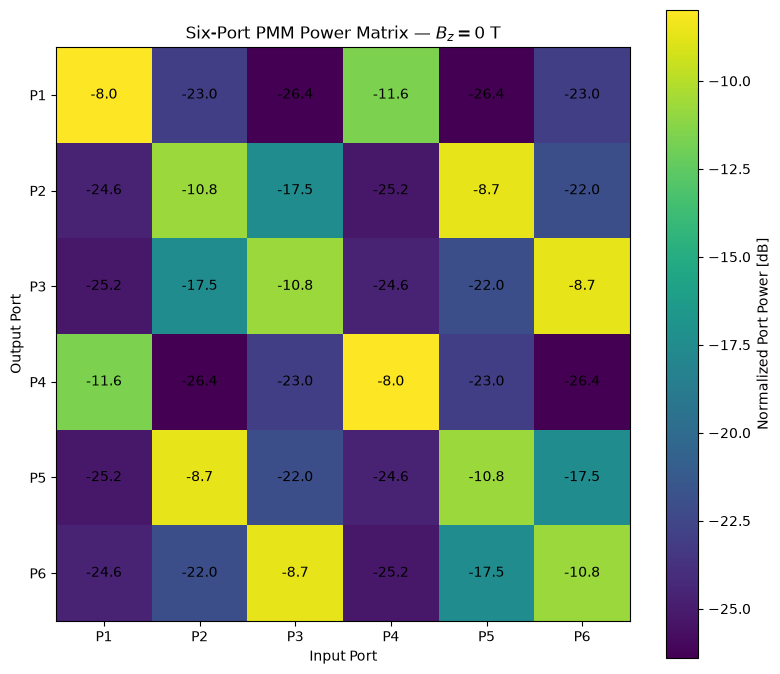


B = 0 RECIPROCITY SUMMARY
P21 vs P12: 1.638 dB
P31 vs P13: 1.186 dB
P41 vs P14: 0.001 dB
P51 vs P15: 1.186 dB
P61 vs P16: 1.638 dB
P32 vs P23: 0.000 dB
P42 vs P24: 1.185 dB
P52 vs P25: 0.000 dB
P62 vs P26: 0.000 dB
P43 vs P34: 1.636 dB
P53 vs P35: 0.000 dB
P63 vs P36: 0.000 dB
P54 vs P45: 1.636 dB
P64 vs P46: 1.185 dB
P65 vs P56: 0.000 dB

Mean reciprocity difference = 0.7527197713162599 dB
Maximum reciprocity difference = 1.6378764252828049 dB

Negative matrix entries: 0

B = 0 matrix visualization complete.


In [36]:
# HEATMAP — FULL 6 x 6 POWER MATRIX AT B = 0
#
# Rows    = OUTPUT ports
# Columns = INPUT ports
#
# At B = 0, reciprocity should make the matrix
# approximately symmetric about the main diagonal.
# ============================================================


# ------------------------------------------------------------
# 1. Plot the normalized matrix in dB
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8,7)
)


im = ax.imshow(
    power_matrix_B0_dB,
    origin="upper",
    aspect="equal"
)


# ------------------------------------------------------------
# 2. Axis labels
# ------------------------------------------------------------

port_labels = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6"
]


ax.set_xticks(
    np.arange(6)
)

ax.set_yticks(
    np.arange(6)
)


ax.set_xticklabels(
    port_labels
)

ax.set_yticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)

ax.set_ylabel(
    "Output Port"
)


ax.set_title(
    r"Six-Port PMM Power Matrix — $B_z = 0$ T"
)


# ------------------------------------------------------------
# 3. Add numerical dB values inside each square
# ------------------------------------------------------------

for i in range(6):

    for j in range(6):

        value = power_matrix_B0_dB[
            i,
            j
        ]


        if np.isfinite(value):

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center"
            )

        else:

            ax.text(
                j,
                i,
                "nan",
                ha="center",
                va="center"
            )


# ------------------------------------------------------------
# 4. Color bar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax
)


cbar.set_label(
    "Normalized Port Power [dB]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 5. Print reciprocity summary
#
# Compare every off-diagonal pair:
#
#       Pij vs Pji
# ============================================================

print()
print(
    "======================================================"
)

print(
    "B = 0 RECIPROCITY SUMMARY"
)

print(
    "======================================================"
)


pair_differences = []


for i in range(6):

    for j in range(
        i+1,
        6
    ):

        a_ij = power_matrix_B0_dB[
            i,
            j
        ]

        a_ji = power_matrix_B0_dB[
            j,
            i
        ]


        if (
            np.isfinite(a_ij)
            and
            np.isfinite(a_ji)
        ):

            difference = abs(
                a_ij
                - a_ji
            )


            pair_differences.append(
                difference
            )


            print(
                f"P{j+1}{i+1} vs P{i+1}{j+1}: "
                f"{difference:.3f} dB"
            )


# ------------------------------------------------------------
# 6. Overall reciprocity error
# ------------------------------------------------------------

if len(pair_differences) > 0:

    print()
    print(
        "Mean reciprocity difference =",
        np.mean(pair_differences),
        "dB"
    )

    print(
        "Maximum reciprocity difference =",
        np.max(pair_differences),
        "dB"
    )


# ------------------------------------------------------------
# 7. Check for invalid/negative normalized powers
# ------------------------------------------------------------

negative_entries = np.argwhere(
    power_matrix_B0 < 0
)


print()
print(
    "Negative matrix entries:",
    len(negative_entries)
)


if len(negative_entries) > 0:

    print(
        "Locations:"
    )

    for i, j in negative_entries:

        print(
            f"  output P{i+1}, input P{j+1}: "
            f"{power_matrix_B0[i,j]:.6e}"
        )


print()
print(
    "B = 0 matrix visualization complete."
)

In [37]:
# FULL 6 x 6 PORT-POWER MATRIX AT Bz = -0.05 T
#
# Matrix convention:
#
#       row    = OUTPUT port
#       column = INPUT port
#
# We already have:
#       P1 input column
#       P2 input column
#
# This cell calculates:
#       P3, P4, P5, P6 input columns
#
# IMPORTANT:
# This is a normalized POWER matrix,
# not yet the complex S-matrix.
# ============================================================


# ------------------------------------------------------------
# 1. Initialize matrix
# ------------------------------------------------------------

power_matrix_Bminus = np.full(
    (6,6),
    np.nan
)


# ------------------------------------------------------------
# 2. Insert existing P1-input column
# ------------------------------------------------------------

power_matrix_Bminus[:,0] = np.array([
    R11_B,
    T21_B,
    T31_B,
    T41_B,
    T51_B,
    T61_B
])


# ------------------------------------------------------------
# 3. Insert existing P2-input column
# ------------------------------------------------------------

power_matrix_Bminus[:,1] = np.array([
    T12_B,
    R22_B,
    T32_B,
    T42_B,
    T52_B,
    T62_B
])


# ============================================================
# 4. Function to calculate one magnetized matrix column
#
# Uses:
#       P_B
#
# which already contains the full device at:
#
#       Bz = -0.05 T
#
# Also reuses each port's straight-feed normalization from
# the B = 0 calculations.
# ============================================================

def run_Bminus_port_column(source_port):

    print()
    print(
        "======================================================"
    )

    print(
        f"INPUT PORT P{source_port+1}"
    )

    print(
        "Bz = -0.05 T"
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # 1. Create source for this input port
    # --------------------------------------------------------

    sources_i = make_port_source(
        source_port
    )


    # --------------------------------------------------------
    # 2. Put source into magnetized device
    # --------------------------------------------------------

    P_B.sources = (
        sources_i
    )


    sim_i = (
        P_B.Get_Sim()
    )


    # --------------------------------------------------------
    # 3. Add six flux monitors
    # --------------------------------------------------------

    monitors_i = []
    signs_i = []


    for output_port in range(6):

        region, sign = make_flux_region(
            port_monitor_centers[output_port],
            port_dirs[output_port]
        )


        monitor = sim_i.add_flux(
            fs_a,
            0,
            1,
            region
        )


        monitors_i.append(
            monitor
        )

        signs_i.append(
            sign
        )


    # --------------------------------------------------------
    # 4. Load negative incident field at SOURCE port
    #
    # We already calculated this straight-feed reference
    # during the B = 0 matrix calculation.
    # --------------------------------------------------------

    sim_i.load_minus_flux_data(
        monitors_i[source_port],
        incident_flux_data_by_port[source_port]
    )


    # --------------------------------------------------------
    # 5. Run
    # --------------------------------------------------------

    print(
        f"Running P{source_port+1} -> magnetized device..."
    )


    sim_i.run(
        until_after_sources=80
    )


    print(
        f"P{source_port+1} run complete."
    )


    # --------------------------------------------------------
    # 6. Extract signed outward flux
    # --------------------------------------------------------

    flux_i = np.zeros(
        6
    )


    for output_port in range(6):

        raw = mp.get_fluxes(
            monitors_i[output_port]
        )[0]


        flux_i[output_port] = (
            signs_i[output_port]
            * raw
        )


    # --------------------------------------------------------
    # 7. Normalize by incident power for THIS source port
    # --------------------------------------------------------

    incident_i = (
        incident_power_by_port[source_port]
    )


    column_i = (
        flux_i
        / incident_i
    )


    # --------------------------------------------------------
    # 8. Print column
    # --------------------------------------------------------

    print()


    for output_port in range(6):

        value = column_i[
            output_port
        ]


        print(
            f"P{source_port+1} -> P{output_port+1}: "
            f"{value:.6e}"
        )


    return column_i


# ============================================================
# 5. Calculate P3-P6 input columns
#
# Four new Meep runs total.
# ============================================================

for source_port in range(
    2,
    6
):

    power_matrix_Bminus[:,source_port] = (
        run_Bminus_port_column(
            source_port
        )
    )


# ============================================================
# 6. Print complete LINEAR matrix
# ============================================================

print()
print(
    "======================================================"
)

print(
    "FULL Bz = -0.05 T PORT-POWER MATRIX"
)

print(
    "rows = output port"
)

print(
    "columns = input port"
)

print(
    "======================================================"
)


print(
    "          IN P1       IN P2       IN P3       "
    "IN P4       IN P5       IN P6"
)


for i in range(6):

    values = "  ".join(

        f"{power_matrix_Bminus[i,j]:9.3e}"

        for j in range(6)
    )


    print(
        f"OUT P{i+1}   {values}"
    )


# ============================================================
# 7. Convert valid positive powers to dB
# ============================================================

power_matrix_Bminus_dB = np.full(
    (6,6),
    np.nan
)


positive_entries = (
    power_matrix_Bminus > 0
)


power_matrix_Bminus_dB[
    positive_entries
] = (

    10
    * np.log10(
        power_matrix_Bminus[
            positive_entries
        ]
    )
)


# ============================================================
# 8. Print dB matrix
# ============================================================

print()
print(
    "======================================================"
)

print(
    "Bz = -0.05 T PORT-POWER MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    "          IN P1       IN P2       IN P3       "
    "IN P4       IN P5       IN P6"
)


for i in range(6):

    values = "  ".join(

        (
            f"{power_matrix_Bminus_dB[i,j]:9.2f}"

            if np.isfinite(
                power_matrix_Bminus_dB[i,j]
            )

            else "      nan"
        )

        for j in range(6)
    )


    print(
        f"OUT P{i+1}   {values}"
    )


# ============================================================
# 9. Measure matrix asymmetry
#
# At B = 0:
#
#       Pij ≈ Pji
#
# At B != 0:
#
#       Pij and Pji are allowed to differ.
# ============================================================

nonreciprocity_matrix_Bminus = (

    power_matrix_Bminus_dB

    - power_matrix_Bminus_dB.T

)


np.fill_diagonal(
    nonreciprocity_matrix_Bminus,
    np.nan
)


print()
print(
    "======================================================"
)

print(
    "PAIRWISE NONRECIPROCITY"
)

print(
    "Bz = -0.05 T"
)

print(
    "======================================================"
)


for i in range(6):

    for j in range(
        i+1,
        6
    ):

        difference = (
            nonreciprocity_matrix_Bminus[
                j,
                i
            ]
        )


        print(
            f"P{i+1} -> P{j+1} minus "
            f"P{j+1} -> P{i+1}: "
            f"{difference:+.3f} dB"
        )


# ============================================================
# 10. Find strongest directional port pair
# ============================================================

abs_nonreciprocity = abs(
    nonreciprocity_matrix_Bminus
)


max_index = np.nanargmax(
    abs_nonreciprocity
)


max_row, max_col = np.unravel_index(
    max_index,
    abs_nonreciprocity.shape
)


max_difference = (
    nonreciprocity_matrix_Bminus[
        max_row,
        max_col
    ]
)


print()
print(
    "======================================================"
)

print(
    "STRONGEST DIRECTIONAL DIFFERENCE"
)

print(
    "======================================================"
)


print(
    f"P{max_col+1} -> P{max_row+1} "
    f"versus "
    f"P{max_row+1} -> P{max_col+1}"
)


print(
    "Difference =",
    max_difference,
    "dB"
)


# ============================================================
# 11. Compare overall matrix asymmetry to B = 0
# ============================================================

B0_asymmetry = (
    power_matrix_B0_dB
    - power_matrix_B0_dB.T
)


np.fill_diagonal(
    B0_asymmetry,
    np.nan
)


mean_B0_asymmetry = np.nanmean(
    abs(
        B0_asymmetry
    )
)


mean_Bminus_asymmetry = np.nanmean(
    abs(
        nonreciprocity_matrix_Bminus
    )
)


print()
print(
    "======================================================"
)

print(
    "B = 0 vs B = -0.05 T"
)

print(
    "======================================================"
)


print(
    "Mean |Pij-Pji| at B = 0:",
    mean_B0_asymmetry,
    "dB"
)


print(
    "Mean |Pij-Pji| at B = -0.05 T:",
    mean_Bminus_asymmetry,
    "dB"
)


print()
print(
    "Bz = -0.05 T six-port matrix complete."
)


INPUT PORT P3
Bz = -0.05 T
-----------
Initializing structure...
time for choose_chunkdivision = 0.00289702 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
  

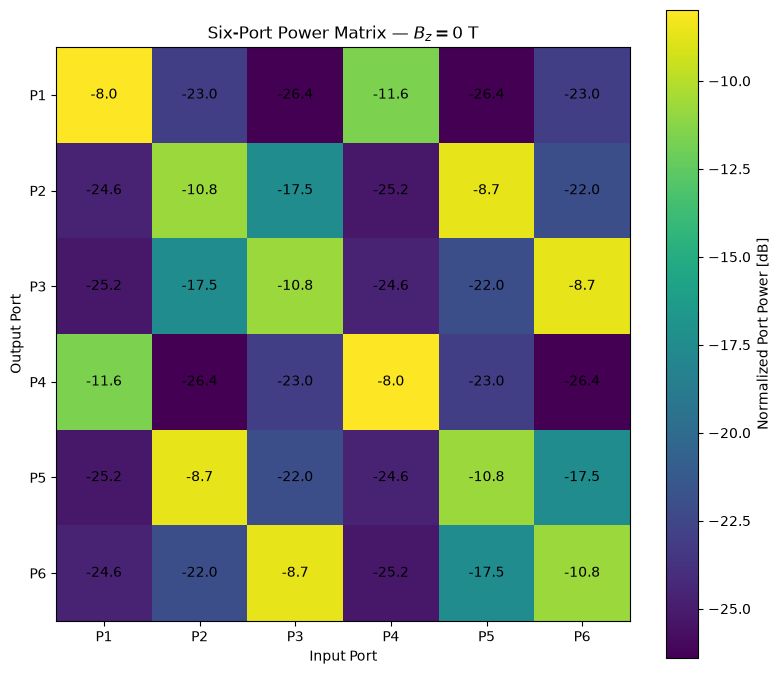

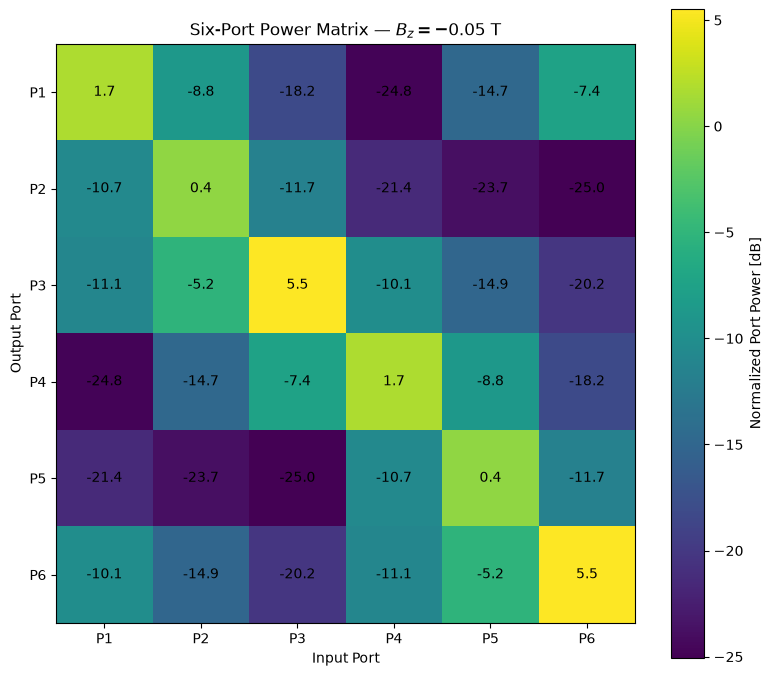

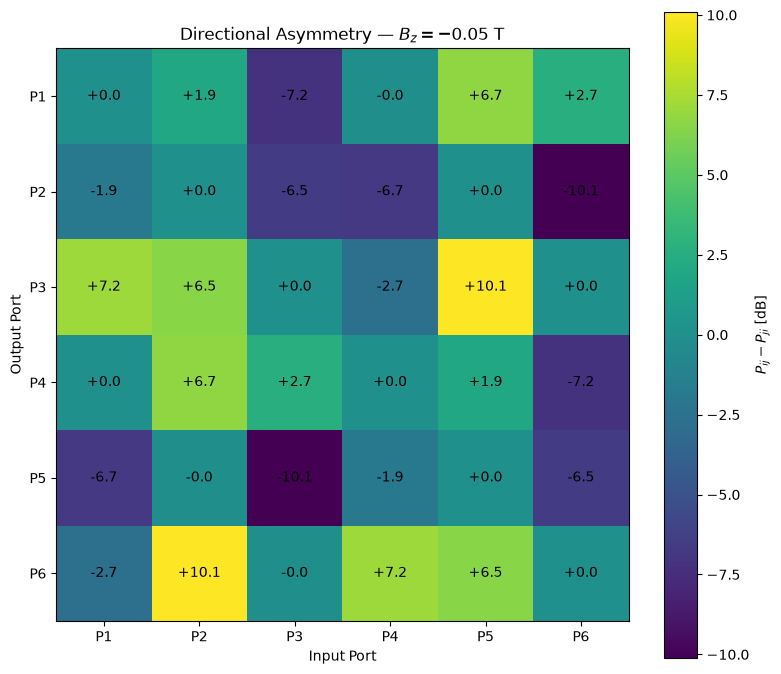

STRONGEST NONRECIPROCAL PORT PAIR
P3 -> P5: -25.047 dB
P5 -> P3: -14.945 dB
Directional difference: -10.101069231824562 dB

OVERALL MATRIX ASYMMETRY
B = 0:
  mean |Pij-Pji| = 0.7527197713162599 dB
  max  |Pij-Pji| = 1.6378764252828049 dB

B = -0.05 T:
  mean |Pij-Pji| = 4.675182600509019 dB
  max  |Pij-Pji| = 10.101069231824562 dB


In [38]:
# VISUALIZE FULL SIX-PORT NONRECIPROCITY
#
# Figure 1:
#       B = 0 power matrix
#
# Figure 2:
#       B = -0.05 T power matrix
#
# Figure 3:
#       Pij - Pji at B = -0.05 T
#
# Rows    = OUTPUT ports
# Columns = INPUT ports
# ============================================================


port_labels = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6"
]


# ============================================================
# 1. B = 0 MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,7)
)


im = ax.imshow(
    power_matrix_B0_dB,
    origin="upper",
    aspect="equal"
)


ax.set_xticks(
    np.arange(6)
)

ax.set_yticks(
    np.arange(6)
)


ax.set_xticklabels(
    port_labels
)

ax.set_yticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)

ax.set_ylabel(
    "Output Port"
)


ax.set_title(
    r"Six-Port Power Matrix — $B_z=0$ T"
)


for i in range(6):

    for j in range(6):

        value = power_matrix_B0_dB[
            i,
            j
        ]


        if np.isfinite(value):

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center"
            )


cbar = fig.colorbar(
    im,
    ax=ax
)


cbar.set_label(
    "Normalized Port Power [dB]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 2. B = -0.05 T MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,7)
)


im = ax.imshow(
    power_matrix_Bminus_dB,
    origin="upper",
    aspect="equal"
)


ax.set_xticks(
    np.arange(6)
)

ax.set_yticks(
    np.arange(6)
)


ax.set_xticklabels(
    port_labels
)

ax.set_yticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)

ax.set_ylabel(
    "Output Port"
)


ax.set_title(
    r"Six-Port Power Matrix — $B_z=-0.05$ T"
)


for i in range(6):

    for j in range(6):

        value = power_matrix_Bminus_dB[
            i,
            j
        ]


        if np.isfinite(value):

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center"
            )


cbar = fig.colorbar(
    im,
    ax=ax
)


cbar.set_label(
    "Normalized Port Power [dB]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 3. NONRECIPROCITY MATRIX
#
# Define:
#
#     Delta_ij = Pij - Pji
#
# For our matrix convention:
#
#     matrix[row, column]
#
#     = output row
#       from input column
#
# A reciprocal system gives approximately zero everywhere.
# ============================================================

delta_matrix_Bminus = (

    power_matrix_Bminus_dB

    - power_matrix_Bminus_dB.T
)


np.fill_diagonal(
    delta_matrix_Bminus,
    0.0
)


fig, ax = plt.subplots(
    figsize=(8,7)
)


im = ax.imshow(
    delta_matrix_Bminus,
    origin="upper",
    aspect="equal"
)


ax.set_xticks(
    np.arange(6)
)

ax.set_yticks(
    np.arange(6)
)


ax.set_xticklabels(
    port_labels
)

ax.set_yticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)

ax.set_ylabel(
    "Output Port"
)


ax.set_title(
    r"Directional Asymmetry — $B_z=-0.05$ T"
)


for i in range(6):

    for j in range(6):

        value = delta_matrix_Bminus[
            i,
            j
        ]


        if np.isfinite(value):

            ax.text(
                j,
                i,
                f"{value:+.1f}",
                ha="center",
                va="center"
            )


cbar = fig.colorbar(
    im,
    ax=ax
)


cbar.set_label(
    r"$P_{ij}-P_{ji}$ [dB]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 4. FIND THE STRONGEST UNIQUE PORT PAIR
#
# Only look at one half of the matrix so we don't count
# each pair twice.
# ============================================================

best_difference = -1

best_i = None
best_j = None


for i in range(6):

    for j in range(
        i+1,
        6
    ):

        value = abs(
            delta_matrix_Bminus[
                j,
                i
            ]
        )


        if (
            np.isfinite(value)
            and
            value > best_difference
        ):

            best_difference = value
            best_i = i
            best_j = j


print(
    "======================================================"
)

print(
    "STRONGEST NONRECIPROCAL PORT PAIR"
)

print(
    "======================================================"
)


if best_i is not None:

    forward = (
        power_matrix_Bminus_dB[
            best_j,
            best_i
        ]
    )

    reverse = (
        power_matrix_Bminus_dB[
            best_i,
            best_j
        ]
    )


    print(
        f"P{best_i+1} -> P{best_j+1}: "
        f"{forward:.3f} dB"
    )


    print(
        f"P{best_j+1} -> P{best_i+1}: "
        f"{reverse:.3f} dB"
    )


    print(
        "Directional difference:",
        forward - reverse,
        "dB"
    )


# ============================================================
# 5. Compare overall reciprocity at B = 0 and B != 0
# ============================================================

delta_matrix_B0 = (

    power_matrix_B0_dB

    - power_matrix_B0_dB.T
)


np.fill_diagonal(
    delta_matrix_B0,
    np.nan
)


delta_B0_values = abs(
    delta_matrix_B0[
        np.isfinite(
            delta_matrix_B0
        )
    ]
)


delta_Bminus_values = abs(
    delta_matrix_Bminus[
        ~np.eye(
            6,
            dtype=bool
        )
        &
        np.isfinite(
            delta_matrix_Bminus
        )
    ]
)


print()
print(
    "======================================================"
)

print(
    "OVERALL MATRIX ASYMMETRY"
)

print(
    "======================================================"
)


print(
    "B = 0:"
)

print(
    "  mean |Pij-Pji| =",
    np.mean(
        delta_B0_values
    ),
    "dB"
)

print(
    "  max  |Pij-Pji| =",
    np.max(
        delta_B0_values
    ),
    "dB"
)


print()
print(
    "B = -0.05 T:"
)

print(
    "  mean |Pij-Pji| =",
    np.mean(
        delta_Bminus_values
    ),
    "dB"
)

print(
    "  max  |Pij-Pji| =",
    np.max(
        delta_Bminus_values
    ),
    "dB"
)

In [39]:
# FULL 6 x 6 PORT-POWER MATRIX AT Bz = +0.05 T
#
# Rows    = OUTPUT ports
# Columns = INPUT ports
#
# P1 and P2 columns already exist.
# This cell calculates P3-P6.
# ============================================================


# ------------------------------------------------------------
# 1. Initialize matrix
# ------------------------------------------------------------

power_matrix_Bplus = np.full(
    (6, 6),
    np.nan
)


# ------------------------------------------------------------
# 2. Existing P1-input column
# ------------------------------------------------------------

power_matrix_Bplus[:, 0] = np.array([
    R11_Brev,
    T21_Brev,
    T31_Brev,
    T41_Brev,
    T51_Brev,
    T61_Brev
])


# ------------------------------------------------------------
# 3. Existing P2-input column
# ------------------------------------------------------------

power_matrix_Bplus[:, 1] = np.array([
    T12_Brev,
    R22_Brev,
    T32_Brev,
    T42_Brev,
    T52_Brev,
    T62_Brev
])


# ============================================================
# 4. Calculate one +0.05 T matrix column
# ============================================================

def run_Bplus_port_column(source_port):

    print()
    print(
        "======================================================"
    )

    print(
        f"INPUT PORT P{source_port+1}"
    )

    print(
        "Bz = +0.05 T"
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # Source for this port
    # --------------------------------------------------------

    sources_i = make_port_source(
        source_port
    )


    # --------------------------------------------------------
    # Existing +0.05 T geometry
    # --------------------------------------------------------

    P_Brev.sources = (
        sources_i
    )


    sim_i = (
        P_Brev.Get_Sim()
    )


    # --------------------------------------------------------
    # Add six flux monitors
    # --------------------------------------------------------

    monitors_i = []
    signs_i = []


    for output_port in range(6):

        region, sign = make_flux_region(
            port_monitor_centers[output_port],
            port_dirs[output_port]
        )


        monitor = sim_i.add_flux(
            fs_a,
            0,
            1,
            region
        )


        monitors_i.append(
            monitor
        )

        signs_i.append(
            sign
        )


    # --------------------------------------------------------
    # Subtract incident field at the SOURCE port
    #
    # Reuse straight-feed normalization data.
    # --------------------------------------------------------

    sim_i.load_minus_flux_data(
        monitors_i[source_port],
        incident_flux_data_by_port[source_port]
    )


    # --------------------------------------------------------
    # Run
    # --------------------------------------------------------

    print(
        f"Running P{source_port+1} -> +0.05 T device..."
    )


    sim_i.run(
        until_after_sources=80
    )


    print(
        f"P{source_port+1} run complete."
    )


    # --------------------------------------------------------
    # Extract outward flux
    # --------------------------------------------------------

    flux_i = np.zeros(
        6
    )


    for output_port in range(6):

        raw = mp.get_fluxes(
            monitors_i[output_port]
        )[0]


        flux_i[output_port] = (
            signs_i[output_port]
            * raw
        )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    incident_i = (
        incident_power_by_port[source_port]
    )


    column_i = (
        flux_i
        / incident_i
    )


    # --------------------------------------------------------
    # Print column
    # --------------------------------------------------------

    print()


    for output_port in range(6):

        print(
            f"P{source_port+1} -> P{output_port+1}: "
            f"{column_i[output_port]:.6e}"
        )


    return column_i


# ============================================================
# 5. Run P3-P6
#
# Four Meep simulations total.
# ============================================================

for source_port in range(
    2,
    6
):

    power_matrix_Bplus[:, source_port] = (
        run_Bplus_port_column(
            source_port
        )
    )


# ============================================================
# 6. Print linear matrix
# ============================================================

print()
print(
    "======================================================"
)

print(
    "FULL Bz = +0.05 T PORT-POWER MATRIX"
)

print(
    "rows = output port"
)

print(
    "columns = input port"
)

print(
    "======================================================"
)


print(
    "          IN P1       IN P2       IN P3       "
    "IN P4       IN P5       IN P6"
)


for i in range(6):

    values = "  ".join(

        f"{power_matrix_Bplus[i,j]:9.3e}"

        for j in range(6)
    )


    print(
        f"OUT P{i+1}   {values}"
    )


# ============================================================
# 7. Convert positive entries to dB
# ============================================================

power_matrix_Bplus_dB = np.full(
    (6, 6),
    np.nan
)


positive_entries = (
    power_matrix_Bplus > 0
)


power_matrix_Bplus_dB[
    positive_entries
] = (

    10
    * np.log10(
        power_matrix_Bplus[
            positive_entries
        ]
    )
)


# ============================================================
# 8. Print dB matrix
# ============================================================

print()
print(
    "======================================================"
)

print(
    "Bz = +0.05 T PORT-POWER MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    "          IN P1       IN P2       IN P3       "
    "IN P4       IN P5       IN P6"
)


for i in range(6):

    values = "  ".join(

        (
            f"{power_matrix_Bplus_dB[i,j]:9.2f}"

            if np.isfinite(
                power_matrix_Bplus_dB[i,j]
            )

            else "      nan"
        )

        for j in range(6)
    )


    print(
        f"OUT P{i+1}   {values}"
    )


# ============================================================
# 9. Directional-asymmetry matrix
# ============================================================

nonreciprocity_matrix_Bplus = (

    power_matrix_Bplus_dB

    - power_matrix_Bplus_dB.T

)


np.fill_diagonal(
    nonreciprocity_matrix_Bplus,
    np.nan
)


print()
print(
    "======================================================"
)

print(
    "PAIRWISE NONRECIPROCITY"
)

print(
    "Bz = +0.05 T"
)

print(
    "======================================================"
)


for i in range(6):

    for j in range(
        i+1,
        6
    ):

        difference = (
            nonreciprocity_matrix_Bplus[
                j,
                i
            ]
        )


        print(
            f"P{i+1} -> P{j+1} minus "
            f"P{j+1} -> P{i+1}: "
            f"{difference:+.3f} dB"
        )


# ============================================================
# 10. Strongest directional port pair
# ============================================================

abs_nonreciprocity_Bplus = abs(
    nonreciprocity_matrix_Bplus
)


max_index = np.nanargmax(
    abs_nonreciprocity_Bplus
)


max_row, max_col = np.unravel_index(
    max_index,
    abs_nonreciprocity_Bplus.shape
)


max_difference = (
    nonreciprocity_matrix_Bplus[
        max_row,
        max_col
    ]
)


print()
print(
    "======================================================"
)

print(
    "STRONGEST DIRECTIONAL DIFFERENCE"
)

print(
    "Bz = +0.05 T"
)

print(
    "======================================================"
)


print(
    f"P{max_col+1} -> P{max_row+1} "
    f"versus "
    f"P{max_row+1} -> P{max_col+1}"
)


print(
    "Difference =",
    max_difference,
    "dB"
)


print()
print(
    "Bz = +0.05 T six-port matrix complete."
)


INPUT PORT P3
Bz = +0.05 T
-----------
Initializing structure...
time for choose_chunkdivision = 0.00288105 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
  

WHOLE-MATRIX FIELD-REVERSAL TEST
P(+B) vs P(-B)^T
P1 -> P1 (+B)  vs  P1 -> P1 (-B): -0.000 dB
P1 -> P2 (+B)  vs  P2 -> P1 (-B): -1.325 dB
P1 -> P3 (+B)  vs  P3 -> P1 (-B): -3.203 dB
P1 -> P4 (+B)  vs  P4 -> P1 (-B): +0.001 dB
P1 -> P5 (+B)  vs  P5 -> P1 (-B): +3.656 dB
P1 -> P6 (+B)  vs  P6 -> P1 (-B): -3.259 dB
P2 -> P1 (+B)  vs  P1 -> P2 (-B): +3.259 dB
P2 -> P2 (+B)  vs  P2 -> P2 (-B): +5.070 dB
P2 -> P3 (+B)  vs  P3 -> P2 (-B): -0.000 dB
P2 -> P4 (+B)  vs  P4 -> P2 (-B): +3.205 dB
P2 -> P5 (+B)  vs  P5 -> P2 (-B): +3.573 dB
P2 -> P6 (+B)  vs  P6 -> P2 (-B): +0.000 dB
P3 -> P1 (+B)  vs  P1 -> P3 (-B): -3.656 dB
P3 -> P2 (+B)  vs  P2 -> P3 (-B): -0.000 dB
P3 -> P3 (+B)  vs  P3 -> P3 (-B): -5.070 dB
P3 -> P4 (+B)  vs  P4 -> P3 (-B): +1.325 dB
P3 -> P5 (+B)  vs  P5 -> P3 (-B): +0.000 dB
P3 -> P6 (+B)  vs  P6 -> P3 (-B): -3.573 dB
P4 -> P1 (+B)  vs  P1 -> P4 (-B): -0.001 dB
P4 -> P2 (+B)  vs  P2 -> P4 (-B): +3.655 dB
P4 -> P3 (+B)  vs  P3 -> P4 (-B): -3.260 dB
P4 -> P4 (+B)  vs  P4 -> P

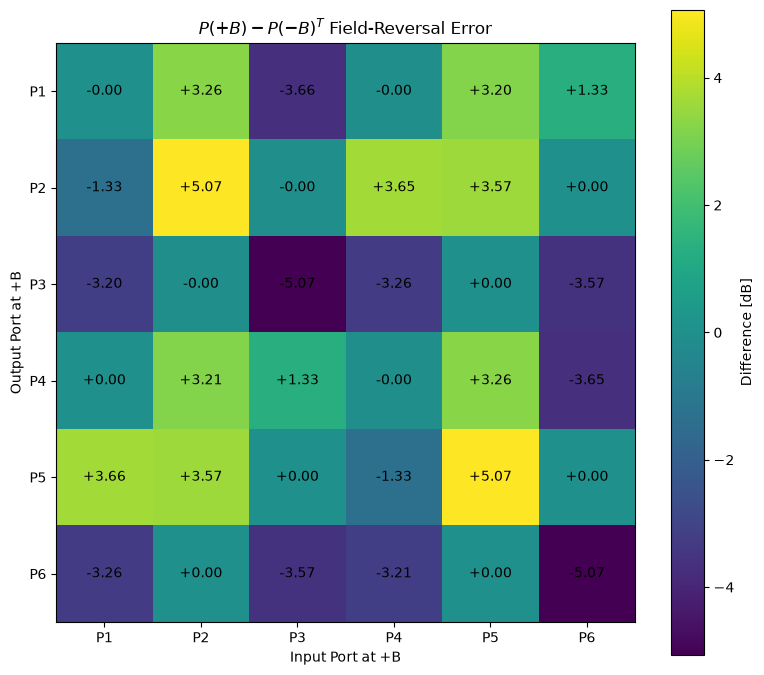


ACTUAL +B MATRIX [dB]
[[  1.74  -7.41 -14.73 -24.77 -18.24  -8.76]
 [-10.09   5.51  -5.16 -11.08 -20.17 -14.95]
 [-21.44 -11.67   0.44 -10.67 -25.05 -23.75]
 [-24.76 -18.24  -8.76   1.74  -7.41 -14.73]
 [-11.08 -20.17 -14.95 -10.09   5.51  -5.16]
 [-10.67 -25.05 -23.75 -21.44 -11.67   0.44]]

EXPECTED +B FROM TRANSPOSE OF -B [dB]
[[  1.74 -10.67 -11.08 -24.76 -21.44 -10.09]
 [ -8.76   0.44  -5.16 -14.73 -23.75 -14.95]
 [-18.24 -11.67   5.51  -7.41 -25.05 -20.17]
 [-24.77 -21.44 -10.09   1.74 -10.67 -11.08]
 [-14.73 -23.75 -14.95  -8.76   0.44  -5.16]
 [ -7.41 -25.05 -20.17 -18.24 -11.67   5.51]]

Whole-device field-reversal test complete.


In [40]:
# WHOLE-DEVICE MAGNETIC-FIELD REVERSAL TEST
#
# Test:
#
#       P(+B) ≈ P(-B)^T
#
# Here:
#       +B = +0.05 T
#       -B = -0.05 T
#
# Rows    = output ports
# Columns = input ports
#
# No Meep run in this cell.
# ============================================================


# ------------------------------------------------------------
# 1. Build the expected +B matrix from the -B result
#
# Magnetic-field reversal predicts approximately:
#
#       P_plus[i,j] = P_minus[j,i]
# ------------------------------------------------------------

expected_Bplus_dB = (
    power_matrix_Bminus_dB.T
)


# ------------------------------------------------------------
# 2. Difference matrix
#
# Ideally this should be close to zero.
# ------------------------------------------------------------

field_reversal_error_dB = (

    power_matrix_Bplus_dB

    - expected_Bplus_dB
)


# ------------------------------------------------------------
# 3. Print pair-by-pair comparison
# ------------------------------------------------------------

print(
    "======================================================"
)

print(
    "WHOLE-MATRIX FIELD-REVERSAL TEST"
)

print(
    "P(+B) vs P(-B)^T"
)

print(
    "======================================================"
)


for input_port in range(6):

    for output_port in range(6):

        plus_value = (
            power_matrix_Bplus_dB[
                output_port,
                input_port
            ]
        )

        reverse_value = (
            power_matrix_Bminus_dB[
                input_port,
                output_port
            ]
        )


        if (
            np.isfinite(plus_value)
            and
            np.isfinite(reverse_value)
        ):

            error = (
                plus_value
                - reverse_value
            )


            print(
                f"P{input_port+1} -> P{output_port+1} (+B)"
                f"  vs  "
                f"P{output_port+1} -> P{input_port+1} (-B): "
                f"{error:+.3f} dB"
            )


# ------------------------------------------------------------
# 4. Overall error statistics
# ------------------------------------------------------------

valid = np.isfinite(
    field_reversal_error_dB
)


errors = abs(
    field_reversal_error_dB[
        valid
    ]
)


print()
print(
    "======================================================"
)

print(
    "FIELD-REVERSAL ERROR SUMMARY"
)

print(
    "======================================================"
)


print(
    "Mean absolute error =",
    np.mean(errors),
    "dB"
)


print(
    "Median absolute error =",
    np.median(errors),
    "dB"
)


print(
    "Maximum absolute error =",
    np.max(errors),
    "dB"
)


# ------------------------------------------------------------
# 5. Find the worst entry
# ------------------------------------------------------------

error_for_search = np.where(
    valid,
    abs(field_reversal_error_dB),
    -np.inf
)


worst_index = np.unravel_index(
    np.argmax(error_for_search),
    error_for_search.shape
)


worst_output = worst_index[0]
worst_input = worst_index[1]


print()
print(
    "Worst comparison:"
)


print(
    f"P{worst_input+1} -> P{worst_output+1} at +B"
)


print(
    "=",
    power_matrix_Bplus_dB[
        worst_output,
        worst_input
    ],
    "dB"
)


print(
    f"P{worst_output+1} -> P{worst_input+1} at -B"
)


print(
    "=",
    power_matrix_Bminus_dB[
        worst_input,
        worst_output
    ],
    "dB"
)


print(
    "difference =",
    field_reversal_error_dB[
        worst_output,
        worst_input
    ],
    "dB"
)


# ============================================================
# 6. Heatmap of field-reversal error
#
# Zero everywhere would be ideal.
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,7)
)


im = ax.imshow(
    field_reversal_error_dB,
    origin="upper",
    aspect="equal"
)


ax.set_xticks(
    np.arange(6)
)

ax.set_yticks(
    np.arange(6)
)


ax.set_xticklabels(
    port_labels
)

ax.set_yticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port at +B"
)

ax.set_ylabel(
    "Output Port at +B"
)


ax.set_title(
    r"$P(+B)-P(-B)^T$ Field-Reversal Error"
)


for i in range(6):

    for j in range(6):

        value = (
            field_reversal_error_dB[
                i,
                j
            ]
        )


        if np.isfinite(value):

            ax.text(
                j,
                i,
                f"{value:+.2f}",
                ha="center",
                va="center"
            )


cbar = fig.colorbar(
    im,
    ax=ax
)


cbar.set_label(
    "Difference [dB]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 7. Compare the actual +B matrix against predicted +B
#
# Print them directly for easy inspection.
# ============================================================

print()
print(
    "======================================================"
)

print(
    "ACTUAL +B MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        power_matrix_Bplus_dB,
        2
    )
)


print()
print(
    "======================================================"
)

print(
    "EXPECTED +B FROM TRANSPOSE OF -B [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        expected_Bplus_dB,
        2
    )
)


print()
print(
    "Whole-device field-reversal test complete."
)

In [41]:
# SIX-PORT CIRCULATION METRIC
#
# Port ordering around the hexagon:
#
#       P1 -> P2 -> P3 -> P4 -> P5 -> P6 -> P1
#
# Increasing port number = CCW
# Decreasing port number = CW
#
# For each input port:
#
#       CCW output = next port
#       CW output  = previous port
#
# Directionality:
#
#       Delta = P_CCW[dB] - P_CW[dB]
#
# Positive Delta --> CCW favored
# Negative Delta --> CW favored
#
# Compare:
#       B = 0
#       B = -0.05 T
#       B = +0.05 T
#
# No Meep run in this cell.
# ============================================================


# ------------------------------------------------------------
# 1. Helper to evaluate circulation for one power matrix
# ------------------------------------------------------------

def circulation_metrics(
    power_matrix,
    label
):

    ccw_power = np.full(
        6,
        np.nan
    )

    cw_power = np.full(
        6,
        np.nan
    )


    ccw_dB = np.full(
        6,
        np.nan
    )

    cw_dB = np.full(
        6,
        np.nan
    )


    directionality_dB = np.full(
        6,
        np.nan
    )


    # --------------------------------------------------------
    # For each INPUT port
    # --------------------------------------------------------

    for input_port in range(6):

        # Next port around hexagon
        ccw_output = (
            input_port + 1
        ) % 6


        # Previous port around hexagon
        cw_output = (
            input_port - 1
        ) % 6


        # Matrix convention:
        #
        #     row    = output
        #     column = input
        # ----------------------------------------------------

        ccw_power[input_port] = (
            power_matrix[
                ccw_output,
                input_port
            ]
        )


        cw_power[input_port] = (
            power_matrix[
                cw_output,
                input_port
            ]
        )


        # ----------------------------------------------------
        # Convert valid positive powers to dB
        # ----------------------------------------------------

        if ccw_power[input_port] > 0:

            ccw_dB[input_port] = (
                10
                * np.log10(
                    ccw_power[input_port]
                )
            )


        if cw_power[input_port] > 0:

            cw_dB[input_port] = (
                10
                * np.log10(
                    cw_power[input_port]
                )
            )


        # ----------------------------------------------------
        # Directional isolation
        # ----------------------------------------------------

        if (
            np.isfinite(
                ccw_dB[input_port]
            )
            and
            np.isfinite(
                cw_dB[input_port]
            )
        ):

            directionality_dB[input_port] = (
                ccw_dB[input_port]
                - cw_dB[input_port]
            )


    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print()
    print(
        "======================================================"
    )

    print(
        label
    )

    print(
        "======================================================"
    )


    print(
        "Input     CCW output     CW output      "
        "CCW [dB]     CW [dB]     CCW-CW [dB]"
    )


    for input_port in range(6):

        ccw_output = (
            input_port + 1
        ) % 6


        cw_output = (
            input_port - 1
        ) % 6


        print(
            f"P{input_port+1}        "
            f"P{ccw_output+1}             "
            f"P{cw_output+1}          "
            f"{ccw_dB[input_port]:8.2f}     "
            f"{cw_dB[input_port]:8.2f}       "
            f"{directionality_dB[input_port]:+8.2f}"
        )


    # --------------------------------------------------------
    # Overall circulation statistics
    # --------------------------------------------------------

    mean_directionality = np.nanmean(
        directionality_dB
    )


    mean_abs_directionality = np.nanmean(
        np.abs(
            directionality_dB
        )
    )


    worst_directionality = np.nanmin(
        directionality_dB
    )


    best_directionality = np.nanmax(
        directionality_dB
    )


    print()
    print(
        "Mean signed directionality =",
        mean_directionality,
        "dB"
    )


    print(
        "Mean |directionality| =",
        mean_abs_directionality,
        "dB"
    )


    print(
        "Most CW-favored port =",
        worst_directionality,
        "dB"
    )


    print(
        "Most CCW-favored port =",
        best_directionality,
        "dB"
    )


    return {
        "ccw_power": ccw_power,
        "cw_power": cw_power,

        "ccw_dB": ccw_dB,
        "cw_dB": cw_dB,

        "directionality_dB":
            directionality_dB,

        "mean_directionality_dB":
            mean_directionality
    }


# ============================================================
# 2. Evaluate B = 0
# ============================================================

circ_B0 = circulation_metrics(

    power_matrix_B0,

    "CIRCULATION — Bz = 0 T"
)


# ============================================================
# 3. Evaluate B = -0.05 T
# ============================================================

circ_Bminus = circulation_metrics(

    power_matrix_Bminus,

    "CIRCULATION — Bz = -0.05 T"
)


# ============================================================
# 4. Evaluate B = +0.05 T
# ============================================================

circ_Bplus = circulation_metrics(

    power_matrix_Bplus,

    "CIRCULATION — Bz = +0.05 T"
)


# ============================================================
# 5. Compare average directional preference
# ============================================================

print()
print(
    "======================================================"
)

print(
    "OVERALL CIRCULATION COMPARISON"
)

print(
    "======================================================"
)


print(
    "Bz = -0.05 T :",
    circ_Bminus[
        "mean_directionality_dB"
    ],
    "dB"
)


print(
    "Bz =  0.00 T :",
    circ_B0[
        "mean_directionality_dB"
    ],
    "dB"
)


print(
    "Bz = +0.05 T :",
    circ_Bplus[
        "mean_directionality_dB"
    ],
    "dB"
)


# ============================================================
# 6. Field-reversal circulation check
#
# Ideally:
#
#       B = 0       --> near zero
#
#       -B and +B   --> opposite signs
# ============================================================

minus_direction = (
    circ_Bminus[
        "mean_directionality_dB"
    ]
)


zero_direction = (
    circ_B0[
        "mean_directionality_dB"
    ]
)


plus_direction = (
    circ_Bplus[
        "mean_directionality_dB"
    ]
)


print()
print(
    "======================================================"
)

print(
    "CIRCULATION HANDEDNESS CHECK"
)

print(
    "======================================================"
)


print(
    "B = 0 directionality =",
    zero_direction,
    "dB"
)


print(
    "B = -0.05 T directionality =",
    minus_direction,
    "dB"
)


print(
    "B = +0.05 T directionality =",
    plus_direction,
    "dB"
)


if (
    np.sign(minus_direction)
    != np.sign(plus_direction)
):

    print()
    print(
        "Circulation direction reverses with B: PASS"
    )

else:

    print()
    print(
        "Circulation reversal: NOT CLEAR"
    )


CIRCULATION — Bz = 0 T
Input     CCW output     CW output      CCW [dB]     CW [dB]     CCW-CW [dB]
P1        P2             P6            -24.64       -24.64          +0.00
P2        P3             P1            -17.46       -23.00          +5.54
P3        P4             P2            -23.00       -17.46          -5.54
P4        P5             P3            -24.64       -24.64          -0.00
P5        P6             P4            -17.46       -23.00          +5.54
P6        P1             P5            -23.00       -17.46          -5.54

Mean signed directionality = -2.510584333019021e-13 dB
Mean |directionality| = 3.6915254298111755 dB
Most CW-favored port = -5.537288144716992 dB
Most CCW-favored port = 5.537288144716296 dB

CIRCULATION — Bz = -0.05 T
Input     CCW output     CW output      CCW [dB]     CW [dB]     CCW-CW [dB]
P1        P2             P6            -10.67       -10.09          -0.58
P2        P3             P1             -5.16        -8.76          +3.60
P3        

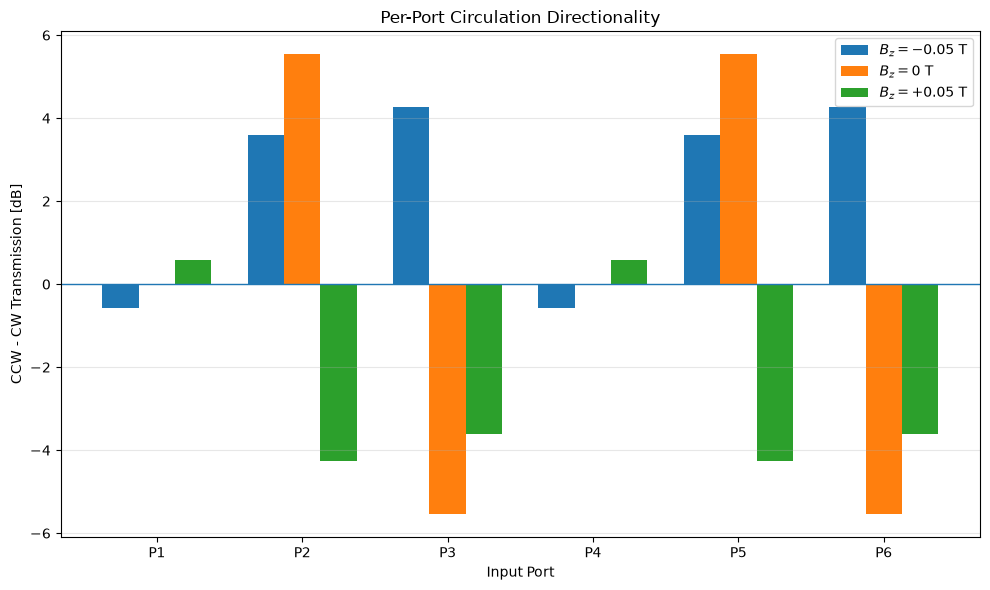

PER-PORT CIRCULATION
Positive = CCW favored
Negative = CW favored
Port      -0.05 T       0 T        +0.05 T
P1          -0.582      +0.000      +0.582
P2          +3.600      +5.537      -4.259
P3          +4.259      -5.537      -3.600
P4          -0.582      -0.000      +0.582
P5          +3.600      +5.537      -4.259
P6          +4.259      -5.537      -3.600

WHOLE-DEVICE CIRCULATION CONSISTENCY
B = -0.05 T:
  Different input ports favor different directions.

B = +0.05 T:
  Different input ports favor different directions.

PORT-BY-PORT B-REVERSAL CHECK
P1:  -0.582 dB ->  +0.582 dB    reversed = True
P2:  +3.600 dB ->  -4.259 dB    reversed = True
P3:  +4.259 dB ->  -3.600 dB    reversed = True
P4:  -0.582 dB ->  +0.582 dB    reversed = True
P5:  +3.600 dB ->  -4.259 dB    reversed = True
P6:  +4.259 dB ->  -3.600 dB    reversed = True

Ports reversing handedness: 6 / 6

SUMMARY
Mean directionality at -0.05 T: 2.42545617137047 dB
Mean directionality at 0 T: -2.510584333019021e-1

In [42]:
# PER-PORT CIRCULATION COMPARISON
#
# Shows whether the circulation behavior is consistent
# around the entire six-port device.
#
# Positive = CCW favored
# Negative = CW favored
#
# Compare:
#       B = -0.05 T
#       B =  0.00 T
#       B = +0.05 T
# ============================================================


# ------------------------------------------------------------
# 1. Collect per-port directionality
# ------------------------------------------------------------

dir_Bminus = np.asarray(
    circ_Bminus["directionality_dB"]
)

dir_B0 = np.asarray(
    circ_B0["directionality_dB"]
)

dir_Bplus = np.asarray(
    circ_Bplus["directionality_dB"]
)


ports = np.arange(6)

port_labels = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6"
]


# ============================================================
# 2. Grouped bar plot
# ============================================================

bar_width = 0.25


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.bar(
    ports - bar_width,
    dir_Bminus,
    width=bar_width,
    label=r"$B_z=-0.05$ T"
)


ax.bar(
    ports,
    dir_B0,
    width=bar_width,
    label=r"$B_z=0$ T"
)


ax.bar(
    ports + bar_width,
    dir_Bplus,
    width=bar_width,
    label=r"$B_z=+0.05$ T"
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xticks(
    ports
)

ax.set_xticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)


ax.set_ylabel(
    "CCW - CW Transmission [dB]"
)


ax.set_title(
    "Per-Port Circulation Directionality"
)


ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 3. Print numerical values
# ============================================================

print(
    "======================================================"
)

print(
    "PER-PORT CIRCULATION"
)

print(
    "Positive = CCW favored"
)

print(
    "Negative = CW favored"
)

print(
    "======================================================"
)


print(
    "Port      -0.05 T       0 T        +0.05 T"
)


for i in range(6):

    print(
        f"P{i+1:<2}      "
        f"{dir_Bminus[i]:+9.3f}   "
        f"{dir_B0[i]:+9.3f}   "
        f"{dir_Bplus[i]:+9.3f}"
    )


# ============================================================
# 4. Check whether all six ports prefer the SAME direction
# ============================================================

def circulation_consistency(directionality):

    valid = directionality[
        np.isfinite(
            directionality
        )
    ]

    if len(valid) == 0:

        return False, 0


    positive = np.sum(
        valid > 0
    )

    negative = np.sum(
        valid < 0
    )


    if positive == len(valid):

        return True, +1


    if negative == len(valid):

        return True, -1


    return False, 0


consistent_minus, sign_minus = (
    circulation_consistency(
        dir_Bminus
    )
)


consistent_plus, sign_plus = (
    circulation_consistency(
        dir_Bplus
    )
)


# ============================================================
# 5. Print whole-device circulation check
# ============================================================

print()
print(
    "======================================================"
)

print(
    "WHOLE-DEVICE CIRCULATION CONSISTENCY"
)

print(
    "======================================================"
)


print(
    "B = -0.05 T:"
)


if consistent_minus:

    if sign_minus > 0:

        print(
            "  All six ports favor CCW."
        )

    else:

        print(
            "  All six ports favor CW."
        )

else:

    print(
        "  Different input ports favor different directions."
    )


print()


print(
    "B = +0.05 T:"
)


if consistent_plus:

    if sign_plus > 0:

        print(
            "  All six ports favor CCW."
        )

    else:

        print(
            "  All six ports favor CW."
        )

else:

    print(
        "  Different input ports favor different directions."
    )


# ============================================================
# 6. Check B-reversal port by port
#
# Ideally each port should reverse its preferred direction
# when B changes sign.
# ============================================================

print()
print(
    "======================================================"
)

print(
    "PORT-BY-PORT B-REVERSAL CHECK"
)

print(
    "======================================================"
)


reversal_by_port = np.zeros(
    6,
    dtype=bool
)


for i in range(6):

    reversal_by_port[i] = (

        np.sign(
            dir_Bminus[i]
        )

        !=

        np.sign(
            dir_Bplus[i]
        )

    )


    print(
        f"P{i+1}: "
        f"{dir_Bminus[i]:+7.3f} dB -> "
        f"{dir_Bplus[i]:+7.3f} dB    "
        f"reversed = {reversal_by_port[i]}"
    )


print()
print(
    "Ports reversing handedness:",
    np.sum(
        reversal_by_port
    ),
    "/ 6"
)


# ============================================================
# 7. Useful summary numbers
# ============================================================

print()
print(
    "======================================================"
)

print(
    "SUMMARY"
)

print(
    "======================================================"
)


print(
    "Mean directionality at -0.05 T:",
    np.nanmean(
        dir_Bminus
    ),
    "dB"
)


print(
    "Mean directionality at 0 T:",
    np.nanmean(
        dir_B0
    ),
    "dB"
)


print(
    "Mean directionality at +0.05 T:",
    np.nanmean(
        dir_Bplus
    ),
    "dB"
)


print(
    "Worst |directionality| at -0.05 T:",
    np.nanmin(
        np.abs(
            dir_Bminus
        )
    ),
    "dB"
)


print(
    "Worst |directionality| at +0.05 T:",
    np.nanmin(
        np.abs(
            dir_Bplus
        )
    ),
    "dB"
)

## Now we are starting the sim setup

In [43]:
# SIX-PORT CIRCULATOR OBJECTIVE
#
# Matrix convention:
#
#       row    = OUTPUT port
#       column = INPUT port
#
# For CCW circulation:
#
#       P1 -> P2
#       P2 -> P3
#       P3 -> P4
#       P4 -> P5
#       P5 -> P6
#       P6 -> P1
#
# For CW circulation, the desired direction is reversed.
#
# Objective:
#
#   reward desired adjacent transmission
#
#   penalize:
#       reverse adjacent transmission
#       reflection
#       leakage to all other ports
#
# Larger objective = better circulator.
#
# No Meep run in this cell.
# ============================================================


def circulator_objective(
    power_matrix,
    direction="CCW",
    w_reverse=1.0,
    w_reflection=0.5,
    w_leakage=0.25
):

    power_matrix = np.asarray(
        power_matrix,
        dtype=float
    )


    if power_matrix.shape != (6, 6):

        raise ValueError(
            "power_matrix must have shape (6, 6)"
        )


    direction = direction.upper()


    if direction not in [
        "CCW",
        "CW"
    ]:

        raise ValueError(
            "direction must be 'CCW' or 'CW'"
        )


    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------

    desired_power = np.zeros(6)

    reverse_power = np.zeros(6)

    reflection_power = np.zeros(6)

    leakage_power = np.zeros(6)


    # --------------------------------------------------------
    # Evaluate every input port
    # --------------------------------------------------------

    for input_port in range(6):

        # ----------------------------------------------------
        # Desired and reverse adjacent outputs
        # ----------------------------------------------------

        if direction == "CCW":

            desired_output = (
                input_port + 1
            ) % 6

            reverse_output = (
                input_port - 1
            ) % 6


        else:

            desired_output = (
                input_port - 1
            ) % 6

            reverse_output = (
                input_port + 1
            ) % 6


        # ----------------------------------------------------
        # Desired circulation path
        # ----------------------------------------------------

        desired_power[input_port] = (
            power_matrix[
                desired_output,
                input_port
            ]
        )


        # ----------------------------------------------------
        # Wrong-way adjacent path
        # ----------------------------------------------------

        reverse_power[input_port] = (
            power_matrix[
                reverse_output,
                input_port
            ]
        )


        # ----------------------------------------------------
        # Reflection
        # ----------------------------------------------------

        reflection_power[input_port] = (
            power_matrix[
                input_port,
                input_port
            ]
        )


        # ----------------------------------------------------
        # Everything else = leakage
        #
        # Exclude:
        #       desired output
        #       reverse output
        #       source/reflection port
        # ----------------------------------------------------

        leakage_outputs = [

            output_port

            for output_port in range(6)

            if output_port not in [

                desired_output,
                reverse_output,
                input_port

            ]
        ]


        leakage_power[input_port] = np.sum(

            power_matrix[
                leakage_outputs,
                input_port
            ]

        )


    # ========================================================
    # GLOBAL SIX-PORT SCORE
    # ========================================================

    desired_mean = np.mean(
        desired_power
    )


    reverse_mean = np.mean(
        reverse_power
    )


    reflection_mean = np.mean(
        reflection_power
    )


    leakage_mean = np.mean(
        leakage_power
    )


    objective = (

        desired_mean

        - w_reverse
        * reverse_mean

        - w_reflection
        * reflection_mean

        - w_leakage
        * leakage_mean

    )


    # --------------------------------------------------------
    # Useful isolation values
    #
    # Desired / reverse for each input port
    # --------------------------------------------------------

    isolation_dB = np.full(
        6,
        np.nan
    )


    for i in range(6):

        if (
            desired_power[i] > 0
            and
            reverse_power[i] > 0
        ):

            isolation_dB[i] = (

                10
                * np.log10(
                    desired_power[i]
                    /
                    reverse_power[i]
                )

            )


    return {

        "objective":
            objective,

        "desired_power":
            desired_power,

        "reverse_power":
            reverse_power,

        "reflection_power":
            reflection_power,

        "leakage_power":
            leakage_power,

        "desired_mean":
            desired_mean,

        "reverse_mean":
            reverse_mean,

        "reflection_mean":
            reflection_mean,

        "leakage_mean":
            leakage_mean,

        "isolation_dB":
            isolation_dB,

        "mean_isolation_dB":
            np.nanmean(
                isolation_dB
            )

    }


# ============================================================
# TEST THE OBJECTIVE ON OUR THREE EXISTING CASES
#
# Evaluate BOTH possible circulation directions.
# ============================================================

objective_B0_CCW = circulator_objective(
    power_matrix_B0,
    direction="CCW"
)


objective_Bminus_CCW = circulator_objective(
    power_matrix_Bminus,
    direction="CCW"
)


objective_Bminus_CW = circulator_objective(
    power_matrix_Bminus,
    direction="CW"
)


objective_Bplus_CCW = circulator_objective(
    power_matrix_Bplus,
    direction="CCW"
)


objective_Bplus_CW = circulator_objective(
    power_matrix_Bplus,
    direction="CW"
)


# ============================================================
# PRINT SUMMARY
# ============================================================

print(
    "======================================================"
)

print(
    "CIRCULATOR OBJECTIVE"
)

print(
    "larger = better"
)

print(
    "======================================================"
)


print(
    "B = 0 T, CCW objective:",
    objective_B0_CCW["objective"]
)


print()


print(
    "B = -0.05 T:"
)

print(
    "  CCW objective =",
    objective_Bminus_CCW["objective"]
)

print(
    "  CW objective  =",
    objective_Bminus_CW["objective"]
)


print()


print(
    "B = +0.05 T:"
)

print(
    "  CCW objective =",
    objective_Bplus_CCW["objective"]
)

print(
    "  CW objective  =",
    objective_Bplus_CW["objective"]
)


# ============================================================
# ISOLATION AROUND ALL SIX PORTS
# ============================================================

print()
print(
    "======================================================"
)

print(
    "PER-PORT ADJACENT ISOLATION"
)

print(
    "======================================================"
)


print(
    "B = -0.05 T, CCW target:"
)

print(
    np.round(
        objective_Bminus_CCW[
            "isolation_dB"
        ],
        2
    )
)


print(
    "Mean isolation =",
    objective_Bminus_CCW[
        "mean_isolation_dB"
    ],
    "dB"
)


print()


print(
    "B = +0.05 T, CCW target:"
)

print(
    np.round(
        objective_Bplus_CCW[
            "isolation_dB"
        ],
        2
    )
)


print(
    "Mean isolation =",
    objective_Bplus_CCW[
        "mean_isolation_dB"
    ],
    "dB"
)


# ============================================================
# DETERMINE WHICH B SIGN CURRENTLY FAVORS WHICH HANDEDNESS
# ============================================================

print()
print(
    "======================================================"
)

print(
    "CURRENT PREFERRED CIRCULATION"
)

print(
    "======================================================"
)


if (
    objective_Bminus_CCW["objective"]
    >
    objective_Bminus_CW["objective"]
):

    print(
        "B = -0.05 T currently favors CCW."
    )

else:

    print(
        "B = -0.05 T currently favors CW."
    )


if (
    objective_Bplus_CCW["objective"]
    >
    objective_Bplus_CW["objective"]
):

    print(
        "B = +0.05 T currently favors CCW."
    )

else:

    print(
        "B = +0.05 T currently favors CW."
    )

CIRCULATOR OBJECTIVE
larger = better
B = 0 T, CCW objective: -0.08470972213156455

B = -0.05 T:
  CCW objective = -0.9509178622767767
  CW objective  = -1.1327050929282025

B = +0.05 T:
  CCW objective = -1.1327050929273375
  CW objective  = -0.9509178622755887

PER-PORT ADJACENT ISOLATION
B = -0.05 T, CCW target:
[-0.58  3.6   4.26 -0.58  3.6   4.26]
Mean isolation = 2.42545617137047 dB

B = +0.05 T, CCW target:
[ 0.58 -4.26 -3.6   0.58 -4.26 -3.6 ]
Mean isolation = -2.425456171377545 dB

CURRENT PREFERRED CIRCULATION
B = -0.05 T currently favors CCW.
B = +0.05 T currently favors CW.


In [44]:
# FULL SIX-PORT CIRCULATOR FORWARD MODEL
#
# Main interface:
#
#       result = simulate_circulator(rho, B)
#
# Inputs:
#       rho : 91 plasma-frequency design variables
#       B   : [Bx, By, Bz] in Tesla
#
# Returns:
#       full 6x6 normalized power matrix
#       dB matrix
#       circulator objective
#       plasma frequencies
#
# Each call requires SIX Meep device simulations:
#       one source at each port.
#
# Straight-feed normalization data are reused from the
# B = 0 reference calculations already completed.
# ============================================================


def simulate_circulator(
    rho,
    B,
    direction="CCW",
    run_time=80,
    verbose=True
):

    # --------------------------------------------------------
    # 1. Check inputs
    # --------------------------------------------------------

    rho = np.asarray(
        rho,
        dtype=float
    ).flatten()


    B = np.asarray(
        B,
        dtype=float
    ).flatten()


    if len(rho) != 91:

        raise ValueError(
            f"Expected 91 rho values, got {len(rho)}."
        )


    if len(B) != 3:

        raise ValueError(
            "B must be [Bx, By, Bz]."
        )


    if verbose:

        print(
            "======================================================"
        )

        print(
            "SIX-PORT CIRCULATOR FORWARD MODEL"
        )

        print(
            "======================================================"
        )

        print(
            "B =",
            B,
            "T"
        )

        print(
            "rho elements =",
            len(rho)
        )


    # ========================================================
    # PART A — BUILD DEVICE
    # ========================================================

    pmm_device = PMMI(
        a=a,
        res=DEV_RES,
        nx=nx_ports,
        ny=ny_ports,
        dpml=dpml_ports,
        B=B
    )


    array_center_device = np.array([
        nx_ports/2,
        ny_ports/2
    ])


    # --------------------------------------------------------
    # 2. Create the 91 trainable discharge locations
    # --------------------------------------------------------

    pmm_device.Rod_Array_Hexagon_train(
        xy_cen=array_center_device,
        side_dim=6,
        r=r_plasma,
        d=d_exp,
        bulbs=False,
        uniform=True
    )


    if len(
        pmm_device.train_elem_locs
    ) != 91:

        raise RuntimeError(
            "Expected 91 discharge locations."
        )


    # --------------------------------------------------------
    # 3. rho -> plasma frequency
    # --------------------------------------------------------

    wp_values, elem_locations = (
        pmm_device.Scale_Rho_wp(
            rho,
            w_src=fs_a,
            wp_max=0,
            gamma=gamma_a
        )
    )


    # --------------------------------------------------------
    # 4. Build PlasMEEP object
    # --------------------------------------------------------

    P_device = (
        pmm_device.Build_Sim()
    )


    # --------------------------------------------------------
    # 5. Add all 91 physical bulbs
    # --------------------------------------------------------

    locs = np.asarray(
        pmm_device.train_elem_locs,
        dtype=float
    )


    for i in range(91):

        center_meep = np.array([

            locs[i,0]
            - nx_ports/2,

            locs[i,1]
            - ny_ports/2,

            0.0
        ])


        P_device.Add_Bulb(

            r_bulb=(
                r_bulb_inner,
                r_bulb_outer
            ),

            center=center_meep,

            wp=wp_values[i],

            gamma=gamma_a,

            axis=np.array([
                0,
                0,
                1
            ]),

            profile=0
        )


    # --------------------------------------------------------
    # 6. Add six PEC horns
    # --------------------------------------------------------

    for horn in full_horns:

        for wall_name in [

            "left_flare",
            "right_flare",
            "left_feed",
            "right_feed"

        ]:

            wall = horn[
                wall_name
            ]


            vertices = np.zeros(
                (4,3)
            )


            vertices[:,0] = (
                wall[:,0]
            )


            vertices[:,1] = (
                wall[:,1]
            )


            P_device.Add_Prism(

                vertices=vertices,

                axis=np.array([
                    0,
                    0,
                    1
                ]),

                PEC=True
            )


    # ========================================================
    # PART B — SIX SOURCE-PORT RUNS
    # ========================================================

    power_matrix = np.full(
        (6,6),
        np.nan
    )


    for source_port in range(6):

        if verbose:

            print()
            print(
                "------------------------------------------------------"
            )

            print(
                f"Input P{source_port+1}  "
                f"({source_port+1}/6)"
            )

            print(
                "------------------------------------------------------"
            )


        # ----------------------------------------------------
        # 7. Source at this port
        # ----------------------------------------------------

        sources_i = make_port_source(
            source_port
        )


        P_device.sources = (
            sources_i
        )


        # Fresh Meep simulation
        sim_i = (
            P_device.Get_Sim()
        )


        # ----------------------------------------------------
        # 8. Six flux monitors
        # ----------------------------------------------------

        monitors_i = []

        signs_i = []


        for output_port in range(6):

            region, sign = make_flux_region(
                port_monitor_centers[
                    output_port
                ],
                port_dirs[
                    output_port
                ]
            )


            monitor = sim_i.add_flux(
                fs_a,
                0,
                1,
                region
            )


            monitors_i.append(
                monitor
            )


            signs_i.append(
                sign
            )


        # ----------------------------------------------------
        # 9. Incident-field subtraction at SOURCE port
        # ----------------------------------------------------

        sim_i.load_minus_flux_data(

            monitors_i[
                source_port
            ],

            incident_flux_data_by_port[
                source_port
            ]

        )


        # ----------------------------------------------------
        # 10. Run Meep
        # ----------------------------------------------------

        if verbose:

            print(
                "Running Meep..."
            )


        sim_i.run(
            until_after_sources=run_time
        )


        # ----------------------------------------------------
        # 11. Extract outward flux
        # ----------------------------------------------------

        flux_i = np.zeros(
            6
        )


        for output_port in range(6):

            raw_flux = mp.get_fluxes(

                monitors_i[
                    output_port
                ]

            )[0]


            flux_i[
                output_port
            ] = (

                signs_i[
                    output_port
                ]

                * raw_flux

            )


        # ----------------------------------------------------
        # 12. Normalize by incident source power
        # ----------------------------------------------------

        incident_i = (
            incident_power_by_port[
                source_port
            ]
        )


        column_i = (
            flux_i
            /
            incident_i
        )


        power_matrix[
            :,
            source_port
        ] = column_i


        if verbose:

            print(
                f"P{source_port+1} column:"
            )


            for output_port in range(6):

                print(
                    f"  -> P{output_port+1}: "
                    f"{column_i[output_port]:.6e}"
                )


    # ========================================================
    # PART C — CONVERT TO dB
    # ========================================================

    power_matrix_dB = np.full(
        (6,6),
        np.nan
    )


    positive = (
        power_matrix > 0
    )


    power_matrix_dB[
        positive
    ] = (

        10
        * np.log10(
            power_matrix[
                positive
            ]
        )
    )


    # ========================================================
    # PART D — SANITY CHECKS
    # ========================================================

    negative_entries = np.argwhere(
        power_matrix < 0
    )


    if len(
        negative_entries
    ) > 0:

        print()
        print(
            "WARNING:"
        )

        print(
            len(negative_entries),
            "negative normalized power entries were found."
        )

        print(
            "Do not send this result to an optimizer "
            "until those entries are understood."
        )


        objective_result = None


    else:

        # ----------------------------------------------------
        # 13. Circulator objective
        # ----------------------------------------------------

        objective_result = (
            circulator_objective(
                power_matrix,
                direction=direction
            )
        )


    # ========================================================
    # PART E — PRINT SUMMARY
    # ========================================================

    if verbose:

        print()
        print(
            "======================================================"
        )

        print(
            "SIMULATION COMPLETE"
        )

        print(
            "======================================================"
        )


        print(
            "Power matrix [dB]:"
        )


        print(
            np.round(
                power_matrix_dB,
                2
            )
        )


        if objective_result is not None:

            print()
            print(
                direction,
                "circulator objective =",
                objective_result[
                    "objective"
                ]
            )


            print(
                "Mean adjacent isolation =",
                objective_result[
                    "mean_isolation_dB"
                ],
                "dB"
            )


    # ========================================================
    # PART F — RETURN EVERYTHING USEFUL
    # ========================================================

    return {

        "rho":
            rho.copy(),

        "B":
            B.copy(),

        "wp":
            np.asarray(
                wp_values
            ).copy(),

        "power_matrix":
            power_matrix,

        "power_matrix_dB":
            power_matrix_dB,

        "objective":
            objective_result,

        "negative_entries":
            negative_entries

    }


print(
    "simulate_circulator(rho, B) defined."
)

print(
    "No Meep simulation was run by this cell."
)

simulate_circulator(rho, B) defined.
No Meep simulation was run by this cell.


In [45]:
# VALIDATE simulate_circulator()
#
# Test case:
#
#       all 91 bulbs: fp = 8 GHz
#       B = 0 T
#
# Compare the new forward-model result against:
#
#       power_matrix_B0
#
# already calculated earlier.
#
# This WILL run Meep:
#       6 device simulations
# ============================================================


# ------------------------------------------------------------
# 1. Uniform 8 GHz plasma configuration
# ------------------------------------------------------------

rho_validation = (
    np.ones(91)
    * fp_a
)


# ------------------------------------------------------------
# 2. Run the packaged forward model
# ------------------------------------------------------------

print(
    "Running simulate_circulator() validation..."
)


validation_B0 = simulate_circulator(

    rho=rho_validation,

    B=[
        0.0,
        0.0,
        0.0
    ],

    direction="CCW",

    run_time=80,

    verbose=False
)


print(
    "Forward-model run complete."
)


# ------------------------------------------------------------
# 3. Extract returned matrices
# ------------------------------------------------------------

validation_matrix = (
    validation_B0[
        "power_matrix"
    ]
)


validation_matrix_dB = (
    validation_B0[
        "power_matrix_dB"
    ]
)


# ------------------------------------------------------------
# 4. Compare against earlier B = 0 matrix
# ------------------------------------------------------------

linear_difference = (

    validation_matrix

    - power_matrix_B0
)


dB_difference = (

    validation_matrix_dB

    - power_matrix_B0_dB
)


# ------------------------------------------------------------
# 5. Print new matrix
# ------------------------------------------------------------

print()
print(
    "======================================================"
)

print(
    "simulate_circulator() B = 0 MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        validation_matrix_dB,
        2
    )
)


# ------------------------------------------------------------
# 6. Print difference matrix
# ------------------------------------------------------------

print()
print(
    "======================================================"
)

print(
    "NEW FUNCTION - PREVIOUS B=0 MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        dB_difference,
        3
    )
)


# ------------------------------------------------------------
# 7. Overall agreement
# ------------------------------------------------------------

valid_difference = np.isfinite(
    dB_difference
)


if np.any(
    valid_difference
):

    mean_difference = np.mean(

        np.abs(
            dB_difference[
                valid_difference
            ]
        )

    )


    max_difference = np.max(

        np.abs(
            dB_difference[
                valid_difference
            ]
        )

    )


    print()
    print(
        "Mean absolute difference =",
        mean_difference,
        "dB"
    )


    print(
        "Maximum absolute difference =",
        max_difference,
        "dB"
    )


# ------------------------------------------------------------
# 8. Check each INPUT column separately
#
# This is especially useful because our original P1
# calculation used a different source construction.
# ------------------------------------------------------------

print()
print(
    "======================================================"
)

print(
    "COLUMN-BY-COLUMN AGREEMENT"
)

print(
    "======================================================"
)


column_errors = np.full(
    6,
    np.nan
)


for source_port in range(6):

    diff_column = (
        dB_difference[
            :,
            source_port
        ]
    )


    valid_column = np.isfinite(
        diff_column
    )


    if np.any(
        valid_column
    ):

        column_errors[
            source_port
        ] = np.mean(

            np.abs(
                diff_column[
                    valid_column
                ]
            )

        )


    print(
        f"P{source_port+1} input column: "
        f"{column_errors[source_port]:.4f} dB "
        f"mean difference"
    )


# ------------------------------------------------------------
# 9. Identify the least-consistent column
# ------------------------------------------------------------

worst_column = np.nanargmax(
    column_errors
)


print()
print(
    "Largest column disagreement:"
)

print(
    f"Input P{worst_column+1}"
)

print(
    "Mean difference =",
    column_errors[
        worst_column
    ],
    "dB"
)


# ------------------------------------------------------------
# 10. Reciprocity of the NEW B = 0 result
# ------------------------------------------------------------

validation_reciprocity = (

    validation_matrix_dB

    - validation_matrix_dB.T
)


np.fill_diagonal(
    validation_reciprocity,
    np.nan
)


print()
print(
    "======================================================"
)

print(
    "NEW FORWARD-MODEL RECIPROCITY CHECK"
)

print(
    "======================================================"
)


print(
    "Mean |Pij-Pji| =",
    np.nanmean(
        np.abs(
            validation_reciprocity
        )
    ),
    "dB"
)


print(
    "Max |Pij-Pji| =",
    np.nanmax(
        np.abs(
            validation_reciprocity
        )
    ),
    "dB"
)


# ------------------------------------------------------------
# 11. Objective from packaged model
# ------------------------------------------------------------

if (
    validation_B0[
        "objective"
    ]
    is not None
):

    print()
    print(
        "CCW objective =",
        validation_B0[
            "objective"
        ][
            "objective"
        ]
    )


print()
print(
    "simulate_circulator() validation complete."
)

Running simulate_circulator() validation...
-----------
Initializing structure...
time for choose_chunkdivision = 0.0028832 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (

In [46]:
# STANDARDIZE SOURCE NORMALIZATION FOR ALL SIX PORTS
#
# Every port now uses:
#
#       make_port_source()
#
# for BOTH:
#       reference normalization
#       device simulation
#
# This removes the earlier special P1 line-source case.
#
# This cell runs:
#       6 straight-feed Meep simulations
# ============================================================


# ------------------------------------------------------------
# 1. Fresh dictionaries
# ------------------------------------------------------------

incident_power_by_port = {}

incident_flux_data_by_port = {}


# ============================================================
# 2. Reference-normalization helper
# ============================================================

def normalize_port(source_port):

    print()
    print(
        "======================================================"
    )

    print(
        f"NORMALIZING PORT P{source_port+1}"
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # Port direction
    # --------------------------------------------------------

    u = np.asarray(
        port_dirs[source_port],
        dtype=float
    )

    u = (
        u
        / np.linalg.norm(u)
    )


    # Perpendicular direction
    n = np.array([
        -u[1],
         u[0]
    ])


    # --------------------------------------------------------
    # Empty reference PMMI / PlasMEEP model
    # --------------------------------------------------------

    pmm_ref = PMMI(
        a=a,
        res=DEV_RES,
        nx=nx_ports,
        ny=ny_ports,
        dpml=dpml_ports,
        B=np.array([
            0.0,
            0.0,
            0.0
        ])
    )


    P_ref = (
        pmm_ref.Build_Sim()
    )


    # --------------------------------------------------------
    # Straight feed centered on this source location
    # --------------------------------------------------------

    reference_center = np.asarray(
        full_horns[source_port]["source_center"],
        dtype=float
    )


    guide_length = (
        2.0
        * np.hypot(
            nx_ports,
            ny_ports
        )
    )


    wall_center_offset = (
        clear_width/2
        + wall_thickness/2
    )


    # --------------------------------------------------------
    # Two PEC walls
    # --------------------------------------------------------

    wall_A = rotated_wall(
        centerline=reference_center,
        axis=u,
        normal=n,
        normal_offset=+wall_center_offset,
        length=guide_length,
        thickness=wall_thickness
    )


    wall_B = rotated_wall(
        centerline=reference_center,
        axis=u,
        normal=n,
        normal_offset=-wall_center_offset,
        length=guide_length,
        thickness=wall_thickness
    )


    P_ref.Add_Prism(
        vertices=wall_A,
        axis=np.array([
            0,
            0,
            1
        ]),
        PEC=True
    )


    P_ref.Add_Prism(
        vertices=wall_B,
        axis=np.array([
            0,
            0,
            1
        ]),
        PEC=True
    )


    # --------------------------------------------------------
    # EXACT SAME source construction used in device runs
    # --------------------------------------------------------

    P_ref.sources = (
        make_port_source(
            source_port
        )
    )


    # --------------------------------------------------------
    # Build simulation
    # --------------------------------------------------------

    ref_sim = (
        P_ref.Get_Sim()
    )


    # --------------------------------------------------------
    # Same monitor location as device
    # --------------------------------------------------------

    region, sign = make_flux_region(
        port_monitor_centers[source_port],
        port_dirs[source_port]
    )


    monitor = ref_sim.add_flux(
        fs_a,
        0,
        1,
        region
    )


    # --------------------------------------------------------
    # Run
    # --------------------------------------------------------

    print(
        "Running reference..."
    )


    ref_sim.run(
        until_after_sources=80
    )


    # --------------------------------------------------------
    # Incident power
    # --------------------------------------------------------

    raw_flux = (
        mp.get_fluxes(
            monitor
        )[0]
    )


    signed_flux = (
        sign
        * raw_flux
    )


    incident_power = abs(
        signed_flux
    )


    # --------------------------------------------------------
    # Save Fourier fields for later subtraction
    # --------------------------------------------------------

    incident_data = (
        ref_sim.get_flux_data(
            monitor
        )
    )


    # --------------------------------------------------------
    # Print checks
    # --------------------------------------------------------

    print(
        "signed incident flux =",
        signed_flux
    )


    print(
        "incident power =",
        incident_power
    )


    if signed_flux < 0:

        print(
            "Direction check: PASS"
        )

    else:

        print(
            "WARNING: expected inward incident flux."
        )


    return (
        incident_power,
        incident_data
    )


# ============================================================
# 3. Normalize ALL SIX PORTS
# ============================================================

for source_port in range(6):

    (
        incident_i,
        incident_data_i
    ) = normalize_port(
        source_port
    )


    incident_power_by_port[
        source_port
    ] = incident_i


    incident_flux_data_by_port[
        source_port
    ] = incident_data_i


# ============================================================
# 4. Print normalization powers
# ============================================================

print()
print(
    "======================================================"
)

print(
    "STANDARDIZED SIX-PORT NORMALIZATION"
)

print(
    "======================================================"
)


for i in range(6):

    print(
        f"P{i+1}: "
        f"{incident_power_by_port[i]:.6e}"
    )


# ============================================================
# 5. Check rotational consistency
#
# Since all six numerical feeds have the same dimensions,
# their incident powers should be reasonably similar.
# ============================================================

incident_values = np.array([

    incident_power_by_port[i]

    for i in range(6)

])


mean_incident = np.mean(
    incident_values
)


relative_spread = (

    (
        np.max(incident_values)
        - np.min(incident_values)
    )

    / mean_incident

)


print()
print(
    "Mean incident power =",
    mean_incident
)


print(
    "Max/min relative spread =",
    relative_spread
)


print()
print(
    "All future device runs can now use:"
)

print(
    "incident_power_by_port"
)

print(
    "incident_flux_data_by_port"
)


NORMALIZING PORT P1
Running reference...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000321865 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     prism, center = (8.03938,0.785714,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-23.1054,0.714286,0)
          (39.1842,0.714286,0)
          (39.1842,0.857143,0)
          (-23.1054,0.857143,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (8.03938,-0.785714,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-23.1054,-0.857143,0)
          (39.1842,-0.857143,0)
          (39.1842,-0.714286,0)
          (-23.1054,-0.714286,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
time for set_epsilon = 1.27151 s
-----------
Meep progress: 6.9453125/358.1006164550781 = 1.9% done in 4.0s, 202.4s to go
on time step 889 (time=6.9

In [47]:
# CANONICAL B = 0 BASELINE
#
# Re-run the uniform 8 GHz device using:
#
#       standardized source construction
#       standardized normalization for all 6 ports
#
# After this cell:
#
#       power_matrix_B0
#       power_matrix_B0_dB
#
# become the official B = 0 baseline.
#
# This runs 6 Meep device simulations.
# ============================================================


# ------------------------------------------------------------
# 1. Save old baseline for comparison
# ------------------------------------------------------------

power_matrix_B0_old = (
    power_matrix_B0.copy()
)

power_matrix_B0_old_dB = (
    power_matrix_B0_dB.copy()
)


# ------------------------------------------------------------
# 2. Uniform plasma configuration
# ------------------------------------------------------------

rho_B0_canonical = (
    np.ones(91)
    * fp_a
)


# ------------------------------------------------------------
# 3. Run canonical forward model
# ------------------------------------------------------------

print(
    "Running canonical B = 0 six-port baseline..."
)


result_B0 = simulate_circulator(
    rho=rho_B0_canonical,
    B=[
        0.0,
        0.0,
        0.0
    ],
    direction="CCW",
    run_time=80,
    verbose=True
)


print()
print(
    "Canonical B = 0 run complete."
)


# ============================================================
# 4. Extract NEW official matrices
# ============================================================

power_matrix_B0 = (
    result_B0[
        "power_matrix"
    ].copy()
)


power_matrix_B0_dB = (
    result_B0[
        "power_matrix_dB"
    ].copy()
)


# ============================================================
# 5. Compare new standardized result to old baseline
# ============================================================

B0_update_difference_dB = (

    power_matrix_B0_dB

    - power_matrix_B0_old_dB
)


print()
print(
    "======================================================"
)

print(
    "NEW STANDARDIZED B=0 MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        power_matrix_B0_dB,
        2
    )
)


print()
print(
    "======================================================"
)

print(
    "CHANGE FROM OLD MIXED-SOURCE BASELINE [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        B0_update_difference_dB,
        3
    )
)


# ============================================================
# 6. Column-by-column change
# ============================================================

print()
print(
    "======================================================"
)

print(
    "CHANGE BY INPUT PORT"
)

print(
    "======================================================"
)


for source_port in range(6):

    diff = (
        B0_update_difference_dB[
            :,
            source_port
        ]
    )


    valid = np.isfinite(
        diff
    )


    if np.any(valid):

        mean_change = np.mean(
            np.abs(
                diff[valid]
            )
        )

        max_change = np.max(
            np.abs(
                diff[valid]
            )
        )


        print(
            f"P{source_port+1}: "
            f"mean = {mean_change:.4f} dB, "
            f"max = {max_change:.4f} dB"
        )


# ============================================================
# 7. Reciprocity check on the standardized baseline
# ============================================================

B0_reciprocity_error = (

    power_matrix_B0_dB

    - power_matrix_B0_dB.T
)


np.fill_diagonal(
    B0_reciprocity_error,
    np.nan
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL B=0 RECIPROCITY"
)

print(
    "======================================================"
)


print(
    "Mean |Pij-Pji| =",
    np.nanmean(
        np.abs(
            B0_reciprocity_error
        )
    ),
    "dB"
)


print(
    "Max |Pij-Pji| =",
    np.nanmax(
        np.abs(
            B0_reciprocity_error
        )
    ),
    "dB"
)


# ============================================================
# 8. Check rotational consistency of the diagonal
# ============================================================

reflection_B0_dB = np.diag(
    power_matrix_B0_dB
)


print()
print(
    "Reflection at each input port [dB]:"
)

for i in range(6):

    print(
        f"  P{i+1}: "
        f"{reflection_B0_dB[i]:.3f} dB"
    )


# ============================================================
# 9. Negative-power sanity check
# ============================================================

negative_B0 = np.argwhere(
    power_matrix_B0 < 0
)


print()
print(
    "Negative normalized-power entries:",
    len(
        negative_B0
    )
)


if len(
    negative_B0
) > 0:

    for output_port, input_port in negative_B0:

        print(
            f"  P{input_port+1} -> P{output_port+1}: "
            f"{power_matrix_B0[output_port,input_port]:.6e}"
        )


# ============================================================
# 10. Save objective for this canonical baseline
# ============================================================

objective_B0_CCW = (
    result_B0[
        "objective"
    ]
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL B=0 BASELINE SAVED"
)

print(
    "======================================================"
)


if objective_B0_CCW is not None:

    print(
        "CCW objective =",
        objective_B0_CCW[
            "objective"
        ]
    )


print()
print(
    "power_matrix_B0 and power_matrix_B0_dB "
    "now refer to the standardized baseline."
)

Running canonical B = 0 six-port baseline...
SIX-PORT CIRCULATOR FORWARD MODEL
B = [0. 0. 0.] T
rho elements = 91

------------------------------------------------------
Input P1  (1/6)
------------------------------------------------------
-----------
Initializing structure...
time for choose_chunkdivision = 0.00294185 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon dia

In [48]:
# CANONICAL Bz = -0.05 T RESULT
#
# Same standardized:
#   source construction
#   six-port normalization
#   forward-model function
#
# Only change from canonical B = 0:
#
#       Bz = -0.05 T
#
# This runs 6 Meep device simulations.
# ============================================================


# ------------------------------------------------------------
# 1. Keep previous -B result for comparison
# ------------------------------------------------------------

power_matrix_Bminus_old = (
    power_matrix_Bminus.copy()
)

power_matrix_Bminus_old_dB = (
    power_matrix_Bminus_dB.copy()
)


# ------------------------------------------------------------
# 2. Run standardized -B forward model
# ------------------------------------------------------------

print(
    "Running canonical Bz = -0.05 T six-port case..."
)


result_Bminus = simulate_circulator(
    rho=rho_B0_canonical,
    B=[
        0.0,
        0.0,
        -0.05
    ],
    direction="CCW",
    run_time=80,
    verbose=True
)


print()
print(
    "Canonical Bz = -0.05 T run complete."
)


# ============================================================
# 3. Replace old matrices with canonical result
# ============================================================

power_matrix_Bminus = (
    result_Bminus[
        "power_matrix"
    ].copy()
)


power_matrix_Bminus_dB = (
    result_Bminus[
        "power_matrix_dB"
    ].copy()
)


# ============================================================
# 4. Compare against earlier -B result
# ============================================================

Bminus_update_difference_dB = (

    power_matrix_Bminus_dB

    - power_matrix_Bminus_old_dB
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL Bz = -0.05 T MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        power_matrix_Bminus_dB,
        2
    )
)


print()
print(
    "======================================================"
)

print(
    "CHANGE FROM EARLIER -B MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        Bminus_update_difference_dB,
        3
    )
)


# ============================================================
# 5. Calculate nonreciprocity matrix
#
# At fixed nonzero B:
#
#       Pij does NOT have to equal Pji
# ============================================================

nonreciprocity_matrix_Bminus = (

    power_matrix_Bminus_dB

    - power_matrix_Bminus_dB.T
)


np.fill_diagonal(
    nonreciprocity_matrix_Bminus,
    np.nan
)


# ------------------------------------------------------------
# 6. Overall directional asymmetry
# ------------------------------------------------------------

print()
print(
    "======================================================"
)

print(
    "CANONICAL -B NONRECIPROCITY"
)

print(
    "======================================================"
)


print(
    "Mean |Pij-Pji| =",
    np.nanmean(
        np.abs(
            nonreciprocity_matrix_Bminus
        )
    ),
    "dB"
)


print(
    "Max |Pij-Pji| =",
    np.nanmax(
        np.abs(
            nonreciprocity_matrix_Bminus
        )
    ),
    "dB"
)


# ============================================================
# 7. Compare to B = 0
# ============================================================

print()
print(
    "======================================================"
)

print(
    "B = 0 vs B = -0.05 T"
)

print(
    "======================================================"
)


print(
    "Mean B=0 reciprocity error =",
    np.nanmean(
        np.abs(
            B0_reciprocity_error
        )
    ),
    "dB"
)


print(
    "Mean -B directional asymmetry =",
    np.nanmean(
        np.abs(
            nonreciprocity_matrix_Bminus
        )
    ),
    "dB"
)


# ============================================================
# 8. Recalculate circulation metrics
# ============================================================

circ_Bminus = circulation_metrics(
    power_matrix_Bminus,
    "CANONICAL CIRCULATION — Bz = -0.05 T"
)


# ============================================================
# 9. Recalculate objective
# ============================================================

objective_Bminus_CCW = (
    circulator_objective(
        power_matrix_Bminus,
        direction="CCW"
    )
)


objective_Bminus_CW = (
    circulator_objective(
        power_matrix_Bminus,
        direction="CW"
    )
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL -B CIRCULATOR OBJECTIVE"
)

print(
    "======================================================"
)


print(
    "CCW objective =",
    objective_Bminus_CCW[
        "objective"
    ]
)


print(
    "CW objective =",
    objective_Bminus_CW[
        "objective"
    ]
)


print(
    "CCW mean isolation =",
    objective_Bminus_CCW[
        "mean_isolation_dB"
    ],
    "dB"
)


print(
    "CW mean isolation =",
    objective_Bminus_CW[
        "mean_isolation_dB"
    ],
    "dB"
)


# ============================================================
# 10. Preferred handedness
# ============================================================

print()


if (
    objective_Bminus_CCW[
        "objective"
    ]
    >
    objective_Bminus_CW[
        "objective"
    ]
):

    print(
        "At Bz = -0.05 T, the uniform device favors CCW."
    )

else:

    print(
        "At Bz = -0.05 T, the uniform device favors CW."
    )


print()
print(
    "power_matrix_Bminus and power_matrix_Bminus_dB "
    "now refer to the standardized -0.05 T result."
)

Running canonical Bz = -0.05 T six-port case...
SIX-PORT CIRCULATOR FORWARD MODEL
B = [ 0.    0.   -0.05] T
rho elements = 91

------------------------------------------------------
Input P1  (1/6)
------------------------------------------------------
-----------
Initializing structure...
time for choose_chunkdivision = 0.00286794 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant

In [49]:
# CANONICAL Bz = +0.05 T RESULT
#
# Same standardized:
#   source construction
#   six-port normalization
#   forward-model function
#
# Only change:
#
#       Bz = +0.05 T
#
# This runs 6 Meep device simulations.
# ============================================================


# ------------------------------------------------------------
# 1. Keep previous +B result for comparison
# ------------------------------------------------------------

power_matrix_Bplus_old = (
    power_matrix_Bplus.copy()
)

power_matrix_Bplus_old_dB = (
    power_matrix_Bplus_dB.copy()
)


# ------------------------------------------------------------
# 2. Run standardized +B forward model
# ------------------------------------------------------------

print(
    "Running canonical Bz = +0.05 T six-port case..."
)


result_Bplus = simulate_circulator(
    rho=rho_B0_canonical,
    B=[
        0.0,
        0.0,
        +0.05
    ],
    direction="CCW",
    run_time=80,
    verbose=True
)


print()
print(
    "Canonical Bz = +0.05 T run complete."
)


# ============================================================
# 3. Replace old matrices with canonical result
# ============================================================

power_matrix_Bplus = (
    result_Bplus[
        "power_matrix"
    ].copy()
)


power_matrix_Bplus_dB = (
    result_Bplus[
        "power_matrix_dB"
    ].copy()
)


# ============================================================
# 4. Compare against earlier +B result
# ============================================================

Bplus_update_difference_dB = (

    power_matrix_Bplus_dB

    - power_matrix_Bplus_old_dB
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL Bz = +0.05 T MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        power_matrix_Bplus_dB,
        2
    )
)


print()
print(
    "======================================================"
)

print(
    "CHANGE FROM EARLIER +B MATRIX [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        Bplus_update_difference_dB,
        3
    )
)


# ============================================================
# 5. Calculate +B nonreciprocity matrix
# ============================================================

nonreciprocity_matrix_Bplus = (

    power_matrix_Bplus_dB

    - power_matrix_Bplus_dB.T
)


np.fill_diagonal(
    nonreciprocity_matrix_Bplus,
    np.nan
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL +B NONRECIPROCITY"
)

print(
    "======================================================"
)


print(
    "Mean |Pij-Pji| =",
    np.nanmean(
        np.abs(
            nonreciprocity_matrix_Bplus
        )
    ),
    "dB"
)


print(
    "Max |Pij-Pji| =",
    np.nanmax(
        np.abs(
            nonreciprocity_matrix_Bplus
        )
    ),
    "dB"
)


# ============================================================
# 6. Recalculate circulation metrics
# ============================================================

circ_Bplus = circulation_metrics(
    power_matrix_Bplus,
    "CANONICAL CIRCULATION — Bz = +0.05 T"
)


# ============================================================
# 7. Recalculate objectives
# ============================================================

objective_Bplus_CCW = (
    circulator_objective(
        power_matrix_Bplus,
        direction="CCW"
    )
)


objective_Bplus_CW = (
    circulator_objective(
        power_matrix_Bplus,
        direction="CW"
    )
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL +B CIRCULATOR OBJECTIVE"
)

print(
    "======================================================"
)


print(
    "CCW objective =",
    objective_Bplus_CCW[
        "objective"
    ]
)


print(
    "CW objective =",
    objective_Bplus_CW[
        "objective"
    ]
)


print(
    "CCW mean isolation =",
    objective_Bplus_CCW[
        "mean_isolation_dB"
    ],
    "dB"
)


print(
    "CW mean isolation =",
    objective_Bplus_CW[
        "mean_isolation_dB"
    ],
    "dB"
)


# ============================================================
# 8. Preferred handedness
# ============================================================

print()


if (
    objective_Bplus_CCW[
        "objective"
    ]
    >
    objective_Bplus_CW[
        "objective"
    ]
):

    print(
        "At Bz = +0.05 T, the uniform device favors CCW."
    )

else:

    print(
        "At Bz = +0.05 T, the uniform device favors CW."
    )


# ============================================================
# 9. Canonical whole-matrix field-reversal check
#
# Expect approximately:
#
#       P(+B) ≈ P(-B)^T
# ============================================================

canonical_field_reversal_error = (

    power_matrix_Bplus_dB

    - power_matrix_Bminus_dB.T
)


valid = np.isfinite(
    canonical_field_reversal_error
)


print()
print(
    "======================================================"
)

print(
    "CANONICAL FIELD-REVERSAL CHECK"
)

print(
    "======================================================"
)


print(
    "Mean |P(+B) - P(-B)^T| =",
    np.mean(
        np.abs(
            canonical_field_reversal_error[
                valid
            ]
        )
    ),
    "dB"
)


print(
    "Max |P(+B) - P(-B)^T| =",
    np.max(
        np.abs(
            canonical_field_reversal_error[
                valid
            ]
        )
    ),
    "dB"
)


print()
print(
    "power_matrix_Bplus and power_matrix_Bplus_dB "
    "now refer to the standardized +0.05 T result."
)

Running canonical Bz = +0.05 T six-port case...
SIX-PORT CIRCULATOR FORWARD MODEL
B = [0.   0.   0.05] T
rho elements = 91

------------------------------------------------------
Input P1  (1/6)
------------------------------------------------------
-----------
Initializing structure...
time for choose_chunkdivision = 0.00311184 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant ep

CANONICAL SIX-PORT VALIDATION SUMMARY

1. B = 0 reciprocity
   mean |Pij-Pji| = 0.7522213489357139 dB
   max  |Pij-Pji| = 1.6355813862285409 dB

2. Magnetic-field reversal
   mean |P(+B)-P(-B)^T| = 2.2320336018209668 dB
   max  |P(+B)-P(-B)^T| = 5.070240462807305 dB

3. Mean circulation directionality
   B = -0.05 T : +2.425 dB
   B =  0.00 T : -0.000 dB
   B = +0.05 T : -2.425 dB

4. Circulator objective
                 CCW             CW
B = -0.05 T   -9.508937e-01   -1.132682e+00
B =  0.00 T   -8.470650e-02   -8.470650e-02
B = +0.05 T   -1.132682e+00   -9.508937e-01

HANDEDNESS
Mean circulation reverses when B reverses.

B = 0 directionality magnitude = 2.510584333019021e-13 dB


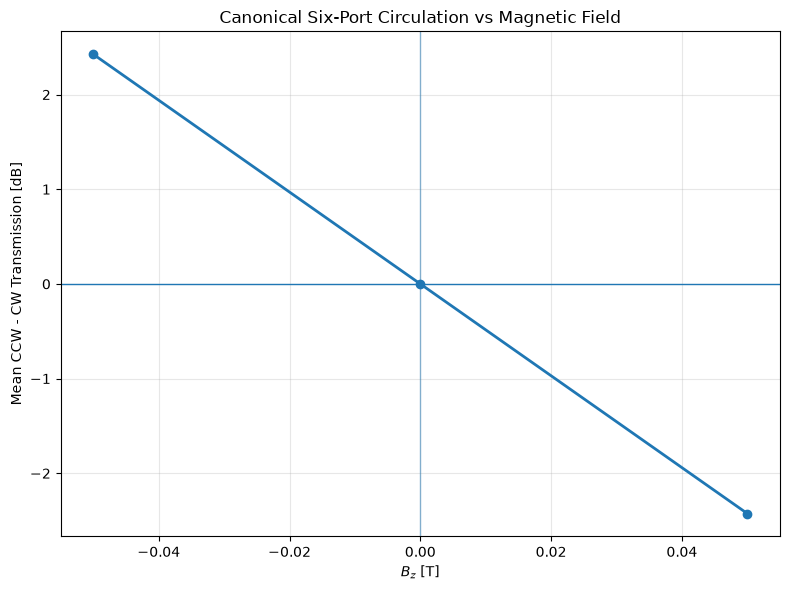

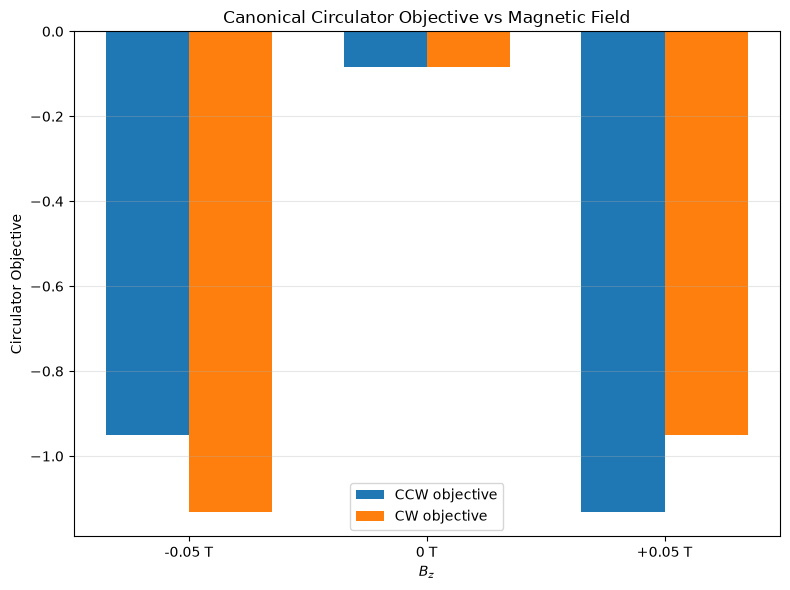


Canonical validation summary complete.


In [50]:
# FINAL CANONICAL VALIDATION SUMMARY
#
# Uses the standardized results:
#
#       Bz = -0.05 T
#       Bz =  0.00 T
#       Bz = +0.05 T
#
# Checks:
#
#   1. Reciprocity at B = 0
#
#          P(0) ≈ P(0)^T
#
#   2. Magnetic-field reversal
#
#          P(+B) ≈ P(-B)^T
#
#   3. Circulation direction
#
#          B = 0       -> near zero preference
#          +B / -B     -> opposite handedness
#
#   4. CCW vs CW circulator objective
#
# No Meep simulation in this cell.
# ============================================================


# ============================================================
# 1. B = 0 RECIPROCITY
# ============================================================

reciprocity_error_B0 = (

    power_matrix_B0_dB

    - power_matrix_B0_dB.T
)


np.fill_diagonal(
    reciprocity_error_B0,
    np.nan
)


reciprocity_values = np.abs(

    reciprocity_error_B0[
        np.isfinite(
            reciprocity_error_B0
        )
    ]

)


mean_reciprocity_error = np.mean(
    reciprocity_values
)


max_reciprocity_error = np.max(
    reciprocity_values
)


# ============================================================
# 2. +B / -B FIELD-REVERSAL RELATION
#
# Expect:
#
#       P(+B) ≈ P(-B)^T
# ============================================================

field_reversal_error = (

    power_matrix_Bplus_dB

    - power_matrix_Bminus_dB.T
)


field_reversal_values = np.abs(

    field_reversal_error[
        np.isfinite(
            field_reversal_error
        )
    ]

)


mean_field_reversal_error = np.mean(
    field_reversal_values
)


max_field_reversal_error = np.max(
    field_reversal_values
)


# ============================================================
# 3. CIRCULATION DIRECTIONALITY
# ============================================================

mean_directionality_Bminus = (
    circ_Bminus[
        "mean_directionality_dB"
    ]
)


mean_directionality_B0 = (
    circ_B0[
        "mean_directionality_dB"
    ]
)


mean_directionality_Bplus = (
    circ_Bplus[
        "mean_directionality_dB"
    ]
)


# ============================================================
# 4. OBJECTIVE VALUES
# ============================================================

objective_summary = np.array([

    [
        objective_Bminus_CCW["objective"],
        objective_Bminus_CW["objective"]
    ],

    [
        circulator_objective(
            power_matrix_B0,
            direction="CCW"
        )["objective"],

        circulator_objective(
            power_matrix_B0,
            direction="CW"
        )["objective"]
    ],

    [
        objective_Bplus_CCW["objective"],
        objective_Bplus_CW["objective"]
    ]

])


# ============================================================
# 5. PRINT VALIDATION SUMMARY
# ============================================================

print(
    "======================================================"
)

print(
    "CANONICAL SIX-PORT VALIDATION SUMMARY"
)

print(
    "======================================================"
)


print()
print(
    "1. B = 0 reciprocity"
)

print(
    "   mean |Pij-Pji| =",
    mean_reciprocity_error,
    "dB"
)

print(
    "   max  |Pij-Pji| =",
    max_reciprocity_error,
    "dB"
)


print()
print(
    "2. Magnetic-field reversal"
)

print(
    "   mean |P(+B)-P(-B)^T| =",
    mean_field_reversal_error,
    "dB"
)

print(
    "   max  |P(+B)-P(-B)^T| =",
    max_field_reversal_error,
    "dB"
)


print()
print(
    "3. Mean circulation directionality"
)

print(
    f"   B = -0.05 T : "
    f"{mean_directionality_Bminus:+.3f} dB"
)

print(
    f"   B =  0.00 T : "
    f"{mean_directionality_B0:+.3f} dB"
)

print(
    f"   B = +0.05 T : "
    f"{mean_directionality_Bplus:+.3f} dB"
)


print()
print(
    "4. Circulator objective"
)

print(
    "                 CCW             CW"
)

print(
    f"B = -0.05 T   "
    f"{objective_summary[0,0]: .6e}   "
    f"{objective_summary[0,1]: .6e}"
)

print(
    f"B =  0.00 T   "
    f"{objective_summary[1,0]: .6e}   "
    f"{objective_summary[1,1]: .6e}"
)

print(
    f"B = +0.05 T   "
    f"{objective_summary[2,0]: .6e}   "
    f"{objective_summary[2,1]: .6e}"
)


# ============================================================
# 6. HANDEDNESS REVERSAL CHECK
# ============================================================

print()
print(
    "======================================================"
)

print(
    "HANDEDNESS"
)

print(
    "======================================================"
)


if (
    np.sign(
        mean_directionality_Bminus
    )
    !=
    np.sign(
        mean_directionality_Bplus
    )
):

    print(
        "Mean circulation reverses when B reverses."
    )

else:

    print(
        "Mean circulation does NOT clearly reverse with B."
    )


print()
print(
    "B = 0 directionality magnitude =",
    abs(
        mean_directionality_B0
    ),
    "dB"
)


# ============================================================
# 7. PLOT MEAN CIRCULATION VS B
# ============================================================

B_summary = np.array([
    -0.05,
     0.00,
    +0.05
])


directionality_summary = np.array([
    mean_directionality_Bminus,
    mean_directionality_B0,
    mean_directionality_Bplus
])


fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    B_summary,
    directionality_summary,
    marker="o",
    linewidth=2
)


ax.axhline(
    0,
    linewidth=1
)


ax.axvline(
    0,
    linewidth=1,
    alpha=0.5
)


ax.set_xlabel(
    r"$B_z$ [T]"
)


ax.set_ylabel(
    "Mean CCW - CW Transmission [dB]"
)


ax.set_title(
    "Canonical Six-Port Circulation vs Magnetic Field"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 8. PLOT CCW / CW OBJECTIVES
# ============================================================

x = np.arange(3)

bar_width = 0.35


fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.bar(
    x - bar_width/2,
    objective_summary[:,0],
    width=bar_width,
    label="CCW objective"
)


ax.bar(
    x + bar_width/2,
    objective_summary[:,1],
    width=bar_width,
    label="CW objective"
)


ax.set_xticks(
    x
)


ax.set_xticklabels([
    "-0.05 T",
    "0 T",
    "+0.05 T"
])


ax.set_xlabel(
    r"$B_z$"
)


ax.set_ylabel(
    "Circulator Objective"
)


ax.set_title(
    "Canonical Circulator Objective vs Magnetic Field"
)


ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()
plt.show()


print()
print(
    "Canonical validation summary complete."
)

## Final validation summary of those three canonical results before we start varying the 91 rho values

In [51]:
# FIRST NONUNIFORM-rho TEST
#
# Change ONE discharge only:
#
#       baseline: fp = 8 GHz
#       selected bulb: fp = 6 GHz
#
# Keep:
#
#       Bz = -0.05 T
#
# Goal:
#   verify that an individual rho variable actually changes
#   the six-port response through simulate_circulator().
# ============================================================


# ------------------------------------------------------------
# 1. Get the 91 discharge locations
# ------------------------------------------------------------

rho_test_locs = np.asarray(
    pmm_ports.train_elem_locs,
    dtype=float
)


array_center_test = np.array([
    nx_ports/2,
    ny_ports/2
])


rho_test_offsets = (
    rho_test_locs
    - array_center_test
)


# ------------------------------------------------------------
# 2. Find a bulb on the P2-facing outer edge
#
# P2 = Python index 1
# ------------------------------------------------------------

p2_dir = np.asarray(
    port_dirs[1],
    dtype=float
)


p2_dir = (
    p2_dir
    / np.linalg.norm(p2_dir)
)


p2_tangent = np.array([
    -p2_dir[1],
     p2_dir[0]
])


# Projection toward P2
p2_projection = (
    rho_test_offsets
    @ p2_dir
)


# All bulbs lying on the outermost P2-facing row
p2_face_value = np.max(
    p2_projection
)


p2_face_indices = np.where(
    np.isclose(
        p2_projection,
        p2_face_value,
        atol=1e-8
    )
)[0]


# Of those bulbs, choose the one closest to the
# center of the P2-facing edge.
p2_transverse = (
    rho_test_offsets
    @ p2_tangent
)


perturb_index = p2_face_indices[
    np.argmin(
        np.abs(
            p2_transverse[
                p2_face_indices
            ]
        )
    )
]


print(
    "Selected discharge index:",
    perturb_index
)


print(
    "Selected discharge position [simulation units]:",
    rho_test_offsets[
        perturb_index
    ]
)


# ------------------------------------------------------------
# 3. Start from uniform 8 GHz configuration
# ------------------------------------------------------------

rho_single_perturb = (
    np.ones(91)
    * fp_a
)


# ------------------------------------------------------------
# 4. Change ONLY selected discharge to 6 GHz
#
# fp_a corresponds to 8 GHz, so:
#
#       fp_6GHz = fp_a * 6/8
# ------------------------------------------------------------

fp_6GHz_a = (
    fp_a
    * 6.0/8.0
)


rho_single_perturb[
    perturb_index
] = fp_6GHz_a


print()
print(
    "Baseline fp = 8.0 GHz"
)

print(
    "Perturbed bulb fp =",
    rho_single_perturb[
        perturb_index
    ] * c/a/1e9,
    "GHz"
)


print(
    "Number of changed rho values =",
    np.sum(
        rho_single_perturb
        != fp_a
    )
)


# ============================================================
# 5. Run the perturbed device
# ============================================================

print()
print(
    "Running single-bulb perturbation..."
)


result_single_perturb = simulate_circulator(

    rho=rho_single_perturb,

    B=[
        0.0,
        0.0,
        -0.05
    ],

    direction="CCW",

    run_time=80,

    verbose=True
)


print()
print(
    "Single-bulb perturbation complete."
)


# ============================================================
# 6. Extract matrix
# ============================================================

power_matrix_single_perturb = (
    result_single_perturb[
        "power_matrix"
    ]
)


power_matrix_single_perturb_dB = (
    result_single_perturb[
        "power_matrix_dB"
    ]
)


# ============================================================
# 7. Compare against canonical uniform -0.05 T baseline
# ============================================================

single_perturb_change_dB = (

    power_matrix_single_perturb_dB

    - power_matrix_Bminus_dB
)


print()
print(
    "======================================================"
)

print(
    "CHANGE CAUSED BY ONE rho VARIABLE [dB]"
)

print(
    "perturbed bulb:",
    perturb_index
)

print(
    "8 GHz -> 6 GHz"
)

print(
    "======================================================"
)


print(
    np.round(
        single_perturb_change_dB,
        3
    )
)


# ============================================================
# 8. Find largest change anywhere in matrix
# ============================================================

valid_change = np.isfinite(
    single_perturb_change_dB
)


change_for_search = np.where(

    valid_change,

    np.abs(
        single_perturb_change_dB
    ),

    -np.inf
)


largest_index = np.unravel_index(

    np.argmax(
        change_for_search
    ),

    change_for_search.shape
)


largest_output = (
    largest_index[0]
)


largest_input = (
    largest_index[1]
)


largest_change = (
    single_perturb_change_dB[
        largest_output,
        largest_input
    ]
)


print()
print(
    "======================================================"
)

print(
    "LARGEST RESPONSE CHANGE"
)

print(
    "======================================================"
)


print(
    f"Input P{largest_input+1} "
    f"-> Output P{largest_output+1}"
)


print(
    "Baseline =",
    power_matrix_Bminus_dB[
        largest_output,
        largest_input
    ],
    "dB"
)


print(
    "Perturbed =",
    power_matrix_single_perturb_dB[
        largest_output,
        largest_input
    ],
    "dB"
)


print(
    "Change =",
    largest_change,
    "dB"
)


# ============================================================
# 9. Overall matrix sensitivity
# ============================================================

absolute_changes = np.abs(
    single_perturb_change_dB[
        valid_change
    ]
)


print()
print(
    "======================================================"
)

print(
    "SINGLE-BULB SENSITIVITY"
)

print(
    "======================================================"
)


print(
    "Mean absolute matrix change =",
    np.mean(
        absolute_changes
    ),
    "dB"
)


print(
    "Maximum absolute matrix change =",
    np.max(
        absolute_changes
    ),
    "dB"
)


# ============================================================
# 10. Compare circulator objective
# ============================================================

perturbed_objective = (
    result_single_perturb[
        "objective"
    ]
)


print()
print(
    "======================================================"
)

print(
    "OBJECTIVE CHANGE"
)

print(
    "======================================================"
)


if perturbed_objective is not None:

    baseline_objective = (
        objective_Bminus_CCW[
            "objective"
        ]
    )


    new_objective = (
        perturbed_objective[
            "objective"
        ]
    )


    print(
        "Uniform -B objective =",
        baseline_objective
    )


    print(
        "Perturbed objective =",
        new_objective
    )


    print(
        "Objective change =",
        new_objective
        - baseline_objective
    )


# ============================================================
# 11. Verify rho -> wp mapping for selected bulb
# ============================================================

print()
print(
    "======================================================"
)

print(
    "rho -> wp CHECK"
)

print(
    "======================================================"
)


print(
    "Selected rho =",
    rho_single_perturb[
        perturb_index
    ]
)


print(
    "Returned wp =",
    result_single_perturb[
        "wp"
    ][
        perturb_index
    ]
)


print(
    "Returned physical fp =",
    result_single_perturb[
        "wp"
    ][
        perturb_index
    ] * c/a/1e9,
    "GHz"
)

Selected discharge index: 27
Selected discharge position [simulation units]: [1.23717915 2.85714286]

Baseline fp = 8.0 GHz
Perturbed bulb fp = 6.000000000000001 GHz
Number of changed rho values = 1

Running single-bulb perturbation...
SIX-PORT CIRCULATOR FORWARD MODEL
B = [ 0.    0.   -0.05] T
rho elements = 91

------------------------------------------------------
Input P1  (1/6)
------------------------------------------------------
-----------
Initializing structure...
time for choose_chunkdivision = 0.00291705 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0

In [52]:
# FINITE-DIFFERENCE SENSITIVITY OF ONE rho VARIABLE
#
# Same bulb selected previously:
#
#       perturb_index
#
# Test:
#
#       7.5 GHz
#       8.0 GHz  <-- existing canonical baseline
#       8.5 GHz
#
# Keep:
#
#       Bz = -0.05 T
#       all other 90 bulbs = 8 GHz
#
# Purpose:
#   check that the response changes smoothly with rho
#   and estimate a local finite-difference sensitivity.
#
# This runs:
#       2 x simulate_circulator()
#       = 12 Meep device simulations
# ============================================================


# ------------------------------------------------------------
# 1. Frequencies for the finite-difference test
# ------------------------------------------------------------

fp_minus_GHz = 7.5
fp_center_GHz = 8.0
fp_plus_GHz = 8.5


fp_minus_a = (
    fp_a
    * fp_minus_GHz/8.0
)


fp_plus_a = (
    fp_a
    * fp_plus_GHz/8.0
)


# ------------------------------------------------------------
# 2. Build the two perturbed rho vectors
# ------------------------------------------------------------

rho_fd_minus = (
    np.ones(91)
    * fp_a
)


rho_fd_plus = (
    np.ones(91)
    * fp_a
)


rho_fd_minus[
    perturb_index
] = fp_minus_a


rho_fd_plus[
    perturb_index
] = fp_plus_a


print(
    "Finite-difference discharge index:",
    perturb_index
)


print(
    "Testing:",
    fp_minus_GHz,
    "GHz,",
    fp_center_GHz,
    "GHz,",
    fp_plus_GHz,
    "GHz"
)


# ============================================================
# 3. Run 7.5 GHz case
# ============================================================

print()
print(
    "Running 7.5 GHz perturbation..."
)


result_fd_minus = simulate_circulator(

    rho=rho_fd_minus,

    B=[
        0.0,
        0.0,
        -0.05
    ],

    direction="CCW",

    run_time=80,

    verbose=False
)


print(
    "7.5 GHz case complete."
)


# ============================================================
# 4. Run 8.5 GHz case
# ============================================================

print()
print(
    "Running 8.5 GHz perturbation..."
)


result_fd_plus = simulate_circulator(

    rho=rho_fd_plus,

    B=[
        0.0,
        0.0,
        -0.05
    ],

    direction="CCW",

    run_time=80,

    verbose=False
)


print(
    "8.5 GHz case complete."
)


# ============================================================
# 5. Extract matrices
#
# 8.0 GHz is the canonical uniform -B baseline:
#
#       power_matrix_Bminus
# ============================================================

matrix_fd_minus = (
    result_fd_minus[
        "power_matrix"
    ]
)


matrix_fd_center = (
    power_matrix_Bminus
)


matrix_fd_plus = (
    result_fd_plus[
        "power_matrix"
    ]
)


matrix_fd_minus_dB = (
    result_fd_minus[
        "power_matrix_dB"
    ]
)


matrix_fd_center_dB = (
    power_matrix_Bminus_dB
)


matrix_fd_plus_dB = (
    result_fd_plus[
        "power_matrix_dB"
    ]
)


# ============================================================
# 6. Central finite-difference derivative
#
# Units:
#
#       dB / GHz
#
# for every entry of the 6x6 power matrix.
# ============================================================

df_GHz = (
    fp_plus_GHz
    - fp_minus_GHz
)


matrix_sensitivity_dB_per_GHz = (

    matrix_fd_plus_dB

    - matrix_fd_minus_dB

) / df_GHz


print()
print(
    "======================================================"
)

print(
    "LOCAL MATRIX SENSITIVITY [dB/GHz]"
)

print(
    "======================================================"
)


print(
    np.round(
        matrix_sensitivity_dB_per_GHz,
        3
    )
)


# ============================================================
# 7. Find matrix element most sensitive to this bulb
# ============================================================

valid = np.isfinite(
    matrix_sensitivity_dB_per_GHz
)


search_matrix = np.where(

    valid,

    np.abs(
        matrix_sensitivity_dB_per_GHz
    ),

    -np.inf
)


max_index = np.unravel_index(

    np.argmax(
        search_matrix
    ),

    search_matrix.shape
)


max_output = (
    max_index[0]
)


max_input = (
    max_index[1]
)


max_sensitivity = (
    matrix_sensitivity_dB_per_GHz[
        max_output,
        max_input
    ]
)


print()
print(
    "======================================================"
)

print(
    "MOST SENSITIVE PORT PAIR"
)

print(
    "======================================================"
)


print(
    f"Input P{max_input+1} "
    f"-> Output P{max_output+1}"
)


print(
    "Sensitivity =",
    max_sensitivity,
    "dB/GHz"
)


print()
print(
    "7.5 GHz:",
    matrix_fd_minus_dB[
        max_output,
        max_input
    ],
    "dB"
)


print(
    "8.0 GHz:",
    matrix_fd_center_dB[
        max_output,
        max_input
    ],
    "dB"
)


print(
    "8.5 GHz:",
    matrix_fd_plus_dB[
        max_output,
        max_input
    ],
    "dB"
)


# ============================================================
# 8. Check local smoothness
#
# Compare:
#
#   change from 7.5 -> 8.0
#
# versus
#
#   change from 8.0 -> 8.5
#
# If the response is locally smooth, these should be
# reasonably similar.
# ============================================================

lower_step_change = (

    matrix_fd_center_dB

    - matrix_fd_minus_dB
)


upper_step_change = (

    matrix_fd_plus_dB

    - matrix_fd_center_dB
)


smoothness_error = (

    upper_step_change

    - lower_step_change
)


valid_smoothness = np.isfinite(
    smoothness_error
)


print()
print(
    "======================================================"
)

print(
    "LOCAL SMOOTHNESS CHECK"
)

print(
    "======================================================"
)


print(
    "Mean |upper step - lower step| =",
    np.mean(
        np.abs(
            smoothness_error[
                valid_smoothness
            ]
        )
    ),
    "dB"
)


print(
    "Maximum |upper step - lower step| =",
    np.max(
        np.abs(
            smoothness_error[
                valid_smoothness
            ]
        )
    ),
    "dB"
)


# ============================================================
# 9. Objective sensitivity
# ============================================================

objective_fd_minus = (
    result_fd_minus[
        "objective"
    ]
)


objective_fd_center = (
    objective_Bminus_CCW
)


objective_fd_plus = (
    result_fd_plus[
        "objective"
    ]
)


if (
    objective_fd_minus is not None
    and
    objective_fd_center is not None
    and
    objective_fd_plus is not None
):

    obj_minus = (
        objective_fd_minus[
            "objective"
        ]
    )


    obj_center = (
        objective_fd_center[
            "objective"
        ]
    )


    obj_plus = (
        objective_fd_plus[
            "objective"
        ]
    )


    objective_derivative = (

        obj_plus
        - obj_minus

    ) / df_GHz


    objective_curvature = (

        obj_plus
        - 2*obj_center
        + obj_minus

    ) / (
        0.5*df_GHz
    )**2


    print()
    print(
        "======================================================"
    )

    print(
        "OBJECTIVE SENSITIVITY"
    )

    print(
        "======================================================"
    )


    print(
        f"7.5 GHz objective = {obj_minus:.6e}"
    )


    print(
        f"8.0 GHz objective = {obj_center:.6e}"
    )


    print(
        f"8.5 GHz objective = {obj_plus:.6e}"
    )


    print()
    print(
        "dObjective/dfp ≈",
        objective_derivative,
        "per GHz"
    )


    print(
        "Local curvature ≈",
        objective_curvature,
        "per GHz^2"
    )


# ============================================================
# 10. Plot the MOST sensitive transmission versus fp
# ============================================================

fd_frequencies = np.array([
    fp_minus_GHz,
    fp_center_GHz,
    fp_plus_GHz
])


fd_response = np.array([

    matrix_fd_minus_dB[
        max_output,
        max_input
    ],

    matrix_fd_center_dB[
        max_output,
        max_input
    ],

    matrix_fd_plus_dB[
        max_output,
        max_input
    ]

])


fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    fd_frequencies,
    fd_response,
    marker="o",
    linewidth=2
)


ax.set_xlabel(
    "Selected Bulb Plasma Frequency [GHz]"
)


ax.set_ylabel(
    "Normalized Port Power [dB]"
)


ax.set_title(
    f"Sensitivity of P{max_input+1} → P{max_output+1} "
    f"to Bulb {perturb_index}"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


print()
print(
    "Finite-difference sensitivity test complete."
)

Finite-difference discharge index: 27
Testing: 7.5 GHz, 8.0 GHz, 8.5 GHz

Running 7.5 GHz perturbation...
-----------
Initializing structure...
time for choose_chunkdivision = 0.00284505 s
Working in 2D dimensions.
Computational cell is 23 x 21 x 0 with resolution 64
     cylinder, center = (0,-3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,-3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,-3.57143,0)
          radius 0.164286, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,3.57143,0)
          radius 0.267857, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.8,3.8,3.8)
     cylinder, center = (0,3.57143,0)
          radius 0.232143, height 1e+20, axis (0, 0, 1)
          dielectri

KeyboardInterrupt: 

In [ ]:
# SPATIAL SENSITIVITY TEST
#
# Compare three representative discharge locations:
#
#       1. center bulb
#       2. inner-ring bulb
#       3. outer-edge bulb
#
# For each test:
#
#       selected bulb: 8 GHz -> 6 GHz
#       other 90 bulbs: 8 GHz
#       Bz = -0.05 T
#
# Baseline:
#       canonical uniform -0.05 T result
#
# This runs:
#       3 x simulate_circulator()
#       = 18 Meep device simulations
# ============================================================


# ------------------------------------------------------------
# 1. Distance of every discharge from array center
# ------------------------------------------------------------

rho_radii = np.linalg.norm(
    rho_test_offsets,
    axis=1
)


# ============================================================
# 2. CENTER BULB
# ============================================================

center_index = np.argmin(
    rho_radii
)


# ============================================================
# 3. INNER-RING BULB
#
# First lattice ring should be approximately one
# center-to-center spacing from the array center.
# ============================================================

inner_ring_candidates = np.where(
    np.isclose(
        rho_radii,
        d_exp,
        atol=1e-6
    )
)[0]


if len(inner_ring_candidates) == 0:

    # Fallback: simply choose radius closest to d_exp
    inner_index = np.argmin(
        np.abs(
            rho_radii - d_exp
        )
    )

else:

    # Choose the inner-ring bulb most closely facing P2
    inner_projection = (
        rho_test_offsets[
            inner_ring_candidates
        ]
        @ p2_dir
    )

    inner_index = inner_ring_candidates[
        np.argmax(
            inner_projection
        )
    ]


# ============================================================
# 4. OUTER-EDGE BULB
#
# Reuse the P2-facing outer bulb chosen previously.
# ============================================================

outer_index = (
    perturb_index
)


# ------------------------------------------------------------
# 5. Collect test locations
# ------------------------------------------------------------

spatial_test_indices = {

    "center":
        center_index,

    "inner":
        inner_index,

    "outer":
        outer_index

}


print(
    "======================================================"
)

print(
    "SELECTED DISCHARGES"
)

print(
    "======================================================"
)


for name, index in spatial_test_indices.items():

    print(
        f"{name:>6}: "
        f"index {index:2d}, "
        f"position = "
        f"{np.round(rho_test_offsets[index], 3)}, "
        f"radius = {rho_radii[index]*a*1000:.1f} mm"
    )


# ============================================================
# 6. Run identical perturbation at each location
# ============================================================

spatial_results = {}

spatial_matrix_change_dB = {}

spatial_objective_change = {}


for name, index in spatial_test_indices.items():

    print()
    print(
        "======================================================"
    )

    print(
        f"RUNNING {name.upper()} BULB PERTURBATION"
    )

    print(
        f"discharge index = {index}"
    )

    print(
        "8 GHz -> 6 GHz"
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # Uniform baseline
    # --------------------------------------------------------

    rho_test = (
        np.ones(91)
        * fp_a
    )


    # --------------------------------------------------------
    # Perturb ONE bulb
    # --------------------------------------------------------

    rho_test[index] = (
        fp_6GHz_a
    )


    # --------------------------------------------------------
    # Run full forward model
    # --------------------------------------------------------

    result = simulate_circulator(

        rho=rho_test,

        B=[
            0.0,
            0.0,
            -0.05
        ],

        direction="CCW",

        run_time=80,

        verbose=False
    )


    spatial_results[
        name
    ] = result


    # --------------------------------------------------------
    # Matrix change relative to uniform -B baseline
    # --------------------------------------------------------

    matrix_change = (

        result[
            "power_matrix_dB"
        ]

        - power_matrix_Bminus_dB

    )


    spatial_matrix_change_dB[
        name
    ] = matrix_change


    # --------------------------------------------------------
    # Objective change
    # --------------------------------------------------------

    if (
        result["objective"] is not None
        and
        objective_Bminus_CCW is not None
    ):

        spatial_objective_change[
            name
        ] = (

            result[
                "objective"
            ][
                "objective"
            ]

            - objective_Bminus_CCW[
                "objective"
            ]

        )

    else:

        spatial_objective_change[
            name
        ] = np.nan


    print(
        f"{name} perturbation complete."
    )


# ============================================================
# 7. Summarize how strongly each bulb affects the matrix
# ============================================================

print()
print(
    "======================================================"
)

print(
    "SPATIAL SENSITIVITY SUMMARY"
)

print(
    "======================================================"
)


spatial_mean_change = {}

spatial_max_change = {}


for name in spatial_test_indices:

    change = (
        spatial_matrix_change_dB[
            name
        ]
    )


    valid = np.isfinite(
        change
    )


    spatial_mean_change[
        name
    ] = np.mean(

        np.abs(
            change[
                valid
            ]
        )

    )


    spatial_max_change[
        name
    ] = np.max(

        np.abs(
            change[
                valid
            ]
        )

    )


    print()
    print(
        name.upper()
    )


    print(
        "  mean |matrix change| =",
        spatial_mean_change[
            name
        ],
        "dB"
    )


    print(
        "  max  |matrix change| =",
        spatial_max_change[
            name
        ],
        "dB"
    )


    print(
        "  objective change =",
        spatial_objective_change[
            name
        ]
    )


# ============================================================
# 8. Find the most affected port pair for each bulb
# ============================================================

print()
print(
    "======================================================"
)

print(
    "MOST AFFECTED PORT PAIR BY BULB LOCATION"
)

print(
    "======================================================"
)


for name in spatial_test_indices:

    change = (
        spatial_matrix_change_dB[
            name
        ]
    )


    search = np.where(

        np.isfinite(
            change
        ),

        np.abs(
            change
        ),

        -np.inf
    )


    max_index = np.unravel_index(
        np.argmax(
            search
        ),
        search.shape
    )


    output_port = (
        max_index[0]
    )

    input_port = (
        max_index[1]
    )


    print()
    print(
        f"{name.upper()} bulb "
        f"(index {spatial_test_indices[name]}):"
    )


    print(
        f"  strongest response: "
        f"P{input_port+1} -> P{output_port+1}"
    )


    print(
        "  change =",
        change[
            output_port,
            input_port
        ],
        "dB"
    )


# ============================================================
# 9. Direct comparison
# ============================================================

print()
print(
    "======================================================"
)

print(
    "RELATIVE INFLUENCE"
)

print(
    "======================================================"
)


for name in [
    "center",
    "inner",
    "outer"
]:

    print(
        f"{name:>6}: "
        f"mean = {spatial_mean_change[name]:.3f} dB, "
        f"max = {spatial_max_change[name]:.3f} dB, "
        f"dObjective = "
        f"{spatial_objective_change[name]:+.6e}"
    )


# ============================================================
# 10. Identify which tested location affects the
# circulator objective the most
# ============================================================

valid_objectives = {

    name: value

    for name, value
    in spatial_objective_change.items()

    if np.isfinite(value)

}


if len(valid_objectives) > 0:

    strongest_objective_location = max(

        valid_objectives,

        key=lambda name:
            abs(
                valid_objectives[
                    name
                ]
            )
    )


    print()
    print(
        "Largest objective sensitivity among these locations:"
    )


    print(
        strongest_objective_location,
        "bulb"
    )


    print(
        "dObjective =",
        valid_objectives[
            strongest_objective_location
        ]
    )

In [ ]:
# IDENTIFY ROTATIONAL SYMMETRY CLASSES OF THE 91 BULBS
#
# Uniform six-port hexagon has 60-degree rotational symmetry.
#
# Therefore, at the uniform baseline:
#
#       91 bulbs
#
# reduce to:
#
#       1 center bulb
#       + 15 groups of 6 rotationally equivalent bulbs
#
#       = 16 unique sensitivity classes
#
# This lets us test 16 representative bulbs first
# instead of immediately testing all 91.
#
# No Meep simulation in this cell.
# ============================================================


# ------------------------------------------------------------
# 1. Use bulb positions relative to the array center
# ------------------------------------------------------------

symmetry_positions = np.asarray(
    rho_test_offsets,
    dtype=float
)


# ------------------------------------------------------------
# 2. 60-degree rotation matrix
# ------------------------------------------------------------

theta60 = np.pi / 3


R60 = np.array([

    [
        np.cos(theta60),
        -np.sin(theta60)
    ],

    [
        np.sin(theta60),
        np.cos(theta60)
    ]

])


# ------------------------------------------------------------
# 3. Helper:
# find which actual bulb is closest to a rotated position
# ------------------------------------------------------------

def nearest_bulb_index(position):

    distances = np.linalg.norm(

        symmetry_positions
        - position,

        axis=1
    )


    index = np.argmin(
        distances
    )


    return (
        index,
        distances[index]
    )


# ------------------------------------------------------------
# 4. Build rotational orbit for one bulb
# ------------------------------------------------------------

def rotational_orbit(index):

    original_position = (
        symmetry_positions[index]
    )


    orbit = []


    rotated_position = (
        original_position.copy()
    )


    for rotation_number in range(6):

        matching_index, error = nearest_bulb_index(
            rotated_position
        )


        if error > 1e-6:

            raise RuntimeError(

                f"Could not match rotated bulb position. "
                f"index={index}, "
                f"rotation={rotation_number}, "
                f"error={error}"

            )


        if matching_index not in orbit:

            orbit.append(
                matching_index
            )


        rotated_position = (
            R60
            @ rotated_position
        )


    return sorted(
        orbit
    )


# ============================================================
# 5. Find all unique rotational symmetry classes
# ============================================================

unassigned = set(
    range(91)
)


symmetry_orbits = []


while len(unassigned) > 0:

    index = min(
        unassigned
    )


    orbit = rotational_orbit(
        index
    )


    symmetry_orbits.append(
        orbit
    )


    for member in orbit:

        unassigned.discard(
            member
        )


# ============================================================
# 6. Sort classes from center outward
# ============================================================

def orbit_radius(orbit):

    representative = (
        orbit[0]
    )


    return np.linalg.norm(
        symmetry_positions[
            representative
        ]
    )


symmetry_orbits = sorted(
    symmetry_orbits,
    key=orbit_radius
)


# ------------------------------------------------------------
# Representative bulb for each symmetry class
# ------------------------------------------------------------

symmetry_representatives = [

    orbit[0]

    for orbit in symmetry_orbits

]


# ============================================================
# 7. Print symmetry classes
# ============================================================

print(
    "======================================================"
)

print(
    "91-BULB ROTATIONAL SYMMETRY"
)

print(
    "======================================================"
)


print(
    "Number of bulbs:",
    len(
        symmetry_positions
    )
)


print(
    "Number of symmetry classes:",
    len(
        symmetry_orbits
    )
)


print()


for class_number, orbit in enumerate(
    symmetry_orbits
):

    representative = (
        orbit[0]
    )


    radius_mm = (

        np.linalg.norm(
            symmetry_positions[
                representative
            ]
        )

        * a
        * 1000
    )


    print(
        f"Class {class_number:2d}: "
        f"representative = {representative:2d}, "
        f"members = {orbit}, "
        f"radius = {radius_mm:.1f} mm"
    )


# ============================================================
# 8. Validate expected structure
# ============================================================

orbit_sizes = np.array([

    len(orbit)

    for orbit in symmetry_orbits

])


print()
print(
    "======================================================"
)

print(
    "SYMMETRY CHECK"
)

print(
    "======================================================"
)


print(
    "Orbit sizes:",
    orbit_sizes
)


print(
    "Total bulbs represented:",
    np.sum(
        orbit_sizes
    )
)


print(
    "Center classes:",
    np.sum(
        orbit_sizes == 1
    )
)


print(
    "Six-member classes:",
    np.sum(
        orbit_sizes == 6
    )
)


if (
    len(symmetry_orbits) == 16
    and
    np.sum(orbit_sizes == 1) == 1
    and
    np.sum(orbit_sizes == 6) == 15
    and
    np.sum(orbit_sizes) == 91
):

    print()
    print(
        "91-bulb C6 symmetry check: PASS"
    )

else:

    print()
    print(
        "Symmetry grouping is not what we expected."
    )


# ============================================================
# 9. Plot the representative bulbs
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8)
)


ax.scatter(
    symmetry_positions[:,0],
    symmetry_positions[:,1],
    s=25,
    alpha=0.35
)


representative_positions = symmetry_positions[
    symmetry_representatives
]


ax.scatter(
    representative_positions[:,0],
    representative_positions[:,1],
    s=90
)


for class_number, index in enumerate(
    symmetry_representatives
):

    xy = symmetry_positions[
        index
    ]


    ax.text(
        xy[0],
        xy[1],
        str(
            class_number
        ),
        ha="center",
        va="center"
    )


ax.set_aspect(
    "equal"
)


ax.set_xlabel(
    "x [simulation units]"
)


ax.set_ylabel(
    "y [simulation units]"
)


ax.set_title(
    "16 Rotationally Unique Bulb Classes"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


print()
print(
    "Representative bulb indices:"
)

print(
    symmetry_representatives
)

## ideally we want something like:
Number of symmetry classes: 16
Center classes: 1
Six-member classes: 15
91-bulb C6 symmetry check: PASS

In [ ]:
# 16-CLASS OBJECTIVE SENSITIVITY MAP
#
# Uniform baseline:
#
#       all 91 bulbs = 8.0 GHz
#       Bz = -0.05 T
#
# Perturb ONE representative bulb from each C6 symmetry class:
#
#       8.0 GHz -> 7.5 GHz
#
# Because the baseline geometry/objective are rotationally
# symmetric, each representative supplies the sensitivity
# for all bulbs in its six-member rotational orbit.
#
# This runs:
#
#       16 forward-model evaluations
#       x 6 source ports each
#       = 96 Meep simulations
# ============================================================


# ------------------------------------------------------------
# 1. Perturbation size
# ------------------------------------------------------------

fp_baseline_GHz = 8.0
fp_test_GHz = 7.5

delta_fp_GHz = (
    fp_test_GHz
    - fp_baseline_GHz
)


fp_test_a = (
    fp_a
    * fp_test_GHz
    / fp_baseline_GHz
)


print(
    "Baseline fp =",
    fp_baseline_GHz,
    "GHz"
)

print(
    "Perturbed fp =",
    fp_test_GHz,
    "GHz"
)

print(
    "delta fp =",
    delta_fp_GHz,
    "GHz"
)


# ------------------------------------------------------------
# 2. Baseline CCW objective
# ------------------------------------------------------------

baseline_objective = (
    objective_Bminus_CCW[
        "objective"
    ]
)


print()
print(
    "Baseline CCW objective =",
    baseline_objective
)


# ============================================================
# 3. Storage for all 16 symmetry classes
# ============================================================

class_objectives = np.full(
    len(symmetry_orbits),
    np.nan
)


class_sensitivity = np.full(
    len(symmetry_orbits),
    np.nan
)


class_results = {}


# ============================================================
# 4. Perturb each representative bulb
# ============================================================

for class_number, representative in enumerate(
    symmetry_representatives
):

    print()
    print(
        "======================================================"
    )

    print(
        f"SYMMETRY CLASS {class_number+1} / "
        f"{len(symmetry_representatives)}"
    )

    print(
        "representative bulb =",
        representative
    )

    print(
        "orbit =",
        symmetry_orbits[
            class_number
        ]
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # Start from uniform 8 GHz array
    # --------------------------------------------------------

    rho_class_test = (
        np.ones(91)
        * fp_a
    )


    # --------------------------------------------------------
    # Change ONE representative bulb only
    # --------------------------------------------------------

    rho_class_test[
        representative
    ] = fp_test_a


    # --------------------------------------------------------
    # Run complete six-port forward model
    # --------------------------------------------------------

    result_class = simulate_circulator(

        rho=rho_class_test,

        B=[
            0.0,
            0.0,
            -0.05
        ],

        direction="CCW",

        run_time=80,

        verbose=False
    )


    class_results[
        class_number
    ] = result_class


    # --------------------------------------------------------
    # Extract objective
    # --------------------------------------------------------

    if result_class["objective"] is None:

        print(
            "WARNING: objective unavailable for this class."
        )

        continue


    objective_test = (
        result_class[
            "objective"
        ][
            "objective"
        ]
    )


    class_objectives[
        class_number
    ] = objective_test


    # --------------------------------------------------------
    # One-sided finite-difference sensitivity
    #
    #       dJ / dfp
    #
    # Units:
    #       objective / GHz
    # --------------------------------------------------------

    class_sensitivity[
        class_number
    ] = (

        objective_test
        - baseline_objective

    ) / delta_fp_GHz


    print(
        "objective =",
        objective_test
    )


    print(
        "objective change =",
        objective_test
        - baseline_objective
    )


    print(
        "dJ/dfp ≈",
        class_sensitivity[
            class_number
        ],
        "per GHz"
    )


# ============================================================
# 5. Map the 16 class sensitivities back onto all 91 bulbs
# ============================================================

rho_sensitivity_91 = np.full(
    91,
    np.nan
)


for class_number, orbit in enumerate(
    symmetry_orbits
):

    for bulb_index in orbit:

        rho_sensitivity_91[
            bulb_index
        ] = class_sensitivity[
            class_number
        ]


# ============================================================
# 6. Print class ranking
# ============================================================

print()
print(
    "======================================================"
)

print(
    "SYMMETRY-CLASS SENSITIVITY RANKING"
)

print(
    "======================================================"
)


ranking = np.argsort(
    -np.abs(
        class_sensitivity
    )
)


for rank, class_number in enumerate(
    ranking
):

    representative = (
        symmetry_representatives[
            class_number
        ]
    )


    orbit = (
        symmetry_orbits[
            class_number
        ]
    )


    radius_mm = (

        np.linalg.norm(
            symmetry_positions[
                representative
            ]
        )

        * a
        * 1000
    )


    print(
        f"{rank+1:2d}. "
        f"class {class_number:2d}   "
        f"rep={representative:2d}   "
        f"radius={radius_mm:6.1f} mm   "
        f"dJ/dfp={class_sensitivity[class_number]:+.6e} /GHz   "
        f"members={orbit}"
    )


# ============================================================
# 7. Most influential class
# ============================================================

strongest_class = ranking[0]


strongest_rep = (
    symmetry_representatives[
        strongest_class
    ]
)


print()
print(
    "======================================================"
)

print(
    "MOST SENSITIVE CLASS"
)

print(
    "======================================================"
)


print(
    "Class =",
    strongest_class
)


print(
    "Representative bulb =",
    strongest_rep
)


print(
    "Members =",
    symmetry_orbits[
        strongest_class
    ]
)


print(
    "dJ/dfp =",
    class_sensitivity[
        strongest_class
    ],
    "per GHz"
)


# ============================================================
# 8. Interpretation of sensitivity sign
#
# Positive dJ/dfp:
#       increasing fp locally should increase objective
#
# Negative dJ/dfp:
#       decreasing fp locally should increase objective
# ============================================================

print()
print(
    "Positive sensitivity:"
)

print(
    "  increasing that bulb's fp should improve the "
    "local CCW objective."
)


print()
print(
    "Negative sensitivity:"
)

print(
    "  decreasing that bulb's fp should improve the "
    "local CCW objective."
)


# ============================================================
# 9. Plot 91-bulb objective sensitivity map
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8)
)


sc = ax.scatter(

    symmetry_positions[:,0],

    symmetry_positions[:,1],

    c=rho_sensitivity_91,

    s=110
)


cbar = fig.colorbar(
    sc,
    ax=ax
)


cbar.set_label(
    r"$\partial J/\partial f_p$  [1/GHz]"
)


ax.set_aspect(
    "equal"
)


ax.set_xlabel(
    "x [simulation units]"
)


ax.set_ylabel(
    "y [simulation units]"
)


ax.set_title(
    "91-Bulb Circulator Objective Sensitivity"
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. Plot sensitivity versus radial position
# ============================================================

class_radii_mm = np.array([

    np.linalg.norm(
        symmetry_positions[
            symmetry_representatives[
                class_number
            ]
        ]
    )

    * a
    * 1000

    for class_number
    in range(
        len(symmetry_orbits)
    )

])


fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.scatter(
    class_radii_mm,
    class_sensitivity,
    s=70
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "Distance from Array Center [mm]"
)


ax.set_ylabel(
    r"$\partial J/\partial f_p$ [1/GHz]"
)


ax.set_title(
    "Circulator Sensitivity vs Bulb Radius"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


print()
print(
    "16-class sensitivity sweep complete."
)

## First desgin to improve circulation

In [ ]:
# FIRST SENSITIVITY-GUIDED 91-BULB DESIGN
#
# Use the sensitivity map to make ONE small deterministic
# update to all 91 plasma frequencies.
#
# This is NOT an optimizer.
#
# It is our first test of:
#
#       sensitivity map
#               ↓
#       modify 91-bulb design
#               ↓
#       run full Meep model
#               ↓
#       check whether objective improves
#
# This WILL run Meep:
#
#       1 simulate_circulator()
#       = 6 Meep device simulations
# ============================================================


# ------------------------------------------------------------
# 1. Choose a deliberately small plasma-frequency step
# ------------------------------------------------------------

step_GHz = 0.25


# Convert GHz step to our nondimensional frequency units.
step_a = (
    fp_a
    * step_GHz
    / 8.0
)


print(
    "Sensitivity-guided step =",
    step_GHz,
    "GHz"
)


# ============================================================
# 2. Start from the uniform 8 GHz baseline
# ============================================================

rho_guided = (
    np.ones(91)
    * fp_a
)


# ============================================================
# 3. Move each bulb in the locally favorable direction
#
# If:
#
#       dJ/dfp > 0
#
# increasing fp should improve J.
#
# If:
#
#       dJ/dfp < 0
#
# decreasing fp should improve J.
# ============================================================

update_direction = np.sign(
    rho_sensitivity_91
)


rho_guided = (

    rho_guided

    + step_a
    * update_direction
)


# ============================================================
# 4. Keep plasma frequencies inside physical/design bounds
#
# For this first test:
#
#       4 GHz <= fp <= 10 GHz
# ============================================================

fp_min_GHz = 4.0
fp_max_GHz = 10.0


fp_min_a = (
    fp_a
    * fp_min_GHz
    / 8.0
)


fp_max_a = (
    fp_a
    * fp_max_GHz
    / 8.0
)


rho_guided = np.clip(
    rho_guided,
    fp_min_a,
    fp_max_a
)


# ============================================================
# 5. Inspect the proposed 91-bulb pattern BEFORE running
# ============================================================

rho_guided_GHz = (

    rho_guided
    / fp_a
    * 8.0

)


print()
print(
    "======================================================"
)

print(
    "PROPOSED DESIGN"
)

print(
    "======================================================"
)


print(
    "Minimum fp =",
    np.min(
        rho_guided_GHz
    ),
    "GHz"
)


print(
    "Maximum fp =",
    np.max(
        rho_guided_GHz
    ),
    "GHz"
)


print(
    "Bulbs increased:",
    np.sum(
        update_direction > 0
    )
)


print(
    "Bulbs decreased:",
    np.sum(
        update_direction < 0
    )
)


print(
    "Bulbs unchanged:",
    np.sum(
        update_direction == 0
    )
)


# ============================================================
# 6. Plot proposed plasma-frequency pattern
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8)
)


sc = ax.scatter(

    symmetry_positions[:,0],

    symmetry_positions[:,1],

    c=rho_guided_GHz,

    s=110
)


cbar = fig.colorbar(
    sc,
    ax=ax
)


cbar.set_label(
    "Plasma Frequency [GHz]"
)


ax.set_aspect(
    "equal"
)


ax.set_xlabel(
    "x [simulation units]"
)


ax.set_ylabel(
    "y [simulation units]"
)


ax.set_title(
    "First Sensitivity-Guided 91-Bulb Design"
)


plt.tight_layout()
plt.show()


# ============================================================
# 7. RUN THE NEW DESIGN
#
# Keep magnetic field fixed:
#
#       Bz = -0.05 T
# ============================================================

print()
print(
    "======================================================"
)

print(
    "RUNNING FIRST GUIDED DESIGN"
)

print(
    "======================================================"
)


result_guided = simulate_circulator(

    rho=rho_guided,

    B=[
        0.0,
        0.0,
        -0.05
    ],

    direction="CCW",

    run_time=80,

    verbose=True
)


# ============================================================
# 8. Extract new objective
# ============================================================

guided_objective_result = (
    result_guided[
        "objective"
    ]
)


print()
print(
    "======================================================"
)

print(
    "OBJECTIVE COMPARISON"
)

print(
    "======================================================"
)


baseline_J = (
    objective_Bminus_CCW[
        "objective"
    ]
)


print(
    "Uniform 8 GHz objective =",
    baseline_J
)


if guided_objective_result is not None:

    guided_J = (
        guided_objective_result[
            "objective"
        ]
    )


    delta_J = (
        guided_J
        - baseline_J
    )


    print(
        "Guided-design objective =",
        guided_J
    )


    print(
        "Objective change =",
        delta_J
    )


    print(
        "Relative objective change =",
        delta_J
        / abs(
            baseline_J
        )
    )


    if guided_J > baseline_J:

        print()
        print(
            "Sensitivity-guided update improved the objective: PASS"
        )

    else:

        print()
        print(
            "Sensitivity-guided update did not improve the objective."
        )


# ============================================================
# 9. Compare mean adjacent isolation
# ============================================================

if guided_objective_result is not None:

    baseline_isolation = (
        objective_Bminus_CCW[
            "mean_isolation_dB"
        ]
    )


    guided_isolation = (
        guided_objective_result[
            "mean_isolation_dB"
        ]
    )


    print()
    print(
        "======================================================"
    )

    print(
        "ISOLATION COMPARISON"
    )

    print(
        "======================================================"
    )


    print(
        "Uniform mean isolation =",
        baseline_isolation,
        "dB"
    )


    print(
        "Guided mean isolation =",
        guided_isolation,
        "dB"
    )


    print(
        "Isolation change =",
        guided_isolation
        - baseline_isolation,
        "dB"
    )


# ============================================================
# 10. Save matrices
# ============================================================

power_matrix_guided = (
    result_guided[
        "power_matrix"
    ]
)


power_matrix_guided_dB = (
    result_guided[
        "power_matrix_dB"
    ]
)


print()
print(
    "First sensitivity-guided design test complete."
)

In [ ]:
# SENSITIVITY-GUIDED STEP-SIZE TEST
#
# Test movement along the SAME 91-dimensional direction:
#
#       step = 0.00 GHz   baseline, already known
#       step = 0.10 GHz   NEW
#       step = 0.25 GHz   already calculated
#       step = 0.50 GHz   NEW
#
# Keep:
#
#       Bz = -0.05 T
#       CCW target
#
# Goal:
#   determine whether the sensitivity direction really
#   improves the objective and choose a sensible step size.
#
# This runs:
#       2 simulate_circulator() calls
#       = 12 Meep simulations
# ============================================================


# ------------------------------------------------------------
# 1. Helper to construct a design for any step size
# ------------------------------------------------------------

def make_guided_design(step_GHz):

    step_a = (
        fp_a
        * step_GHz
        / 8.0
    )


    rho = (
        np.ones(91)
        * fp_a
    )


    rho = (
        rho
        + step_a
        * update_direction
    )


    rho = np.clip(
        rho,
        fp_min_a,
        fp_max_a
    )


    return rho


# ============================================================
# 2. Build NEW 0.10 GHz design
# ============================================================

rho_guided_010 = make_guided_design(
    0.10
)


print(
    "Running 0.10 GHz guided step..."
)


result_guided_010 = simulate_circulator(

    rho=rho_guided_010,

    B=[
        0.0,
        0.0,
        -0.05
    ],

    direction="CCW",

    run_time=80,

    verbose=False
)


print(
    "0.10 GHz step complete."
)


# ============================================================
# 3. Build NEW 0.50 GHz design
# ============================================================

rho_guided_050 = make_guided_design(
    0.50
)


print()
print(
    "Running 0.50 GHz guided step..."
)


result_guided_050 = simulate_circulator(

    rho=rho_guided_050,

    B=[
        0.0,
        0.0,
        -0.05
    ],

    direction="CCW",

    run_time=80,

    verbose=False
)


print(
    "0.50 GHz step complete."
)


# ============================================================
# 4. Collect all four step sizes
#
# 0.00:
#       canonical uniform baseline
#
# 0.25:
#       result_guided from previous cell
# ============================================================

step_values_GHz = np.array([
    0.00,
    0.10,
    0.25,
    0.50
])


step_results = [

    result_Bminus,

    result_guided_010,

    result_guided,

    result_guided_050

]


# ============================================================
# 5. Extract objective and isolation
# ============================================================

step_objectives = np.full(
    len(step_values_GHz),
    np.nan
)


step_isolation = np.full(
    len(step_values_GHz),
    np.nan
)


for i, result in enumerate(
    step_results
):

    if result["objective"] is not None:

        step_objectives[i] = (
            result[
                "objective"
            ][
                "objective"
            ]
        )


        step_isolation[i] = (
            result[
                "objective"
            ][
                "mean_isolation_dB"
            ]
        )


# ============================================================
# 6. Print comparison
# ============================================================

print()
print(
    "======================================================"
)

print(
    "STEP-SIZE COMPARISON"
)

print(
    "======================================================"
)


print(
    "Step [GHz]      Objective        Mean isolation [dB]"
)


for i in range(
    len(step_values_GHz)
):

    print(
        f"{step_values_GHz[i]:8.2f}     "
        f"{step_objectives[i]: .6e}       "
        f"{step_isolation[i]:8.3f}"
    )


# ============================================================
# 7. Objective improvement relative to baseline
# ============================================================

objective_improvement = (

    step_objectives

    - step_objectives[0]

)


print()
print(
    "Objective improvement from uniform baseline:"
)


for i in range(
    len(step_values_GHz)
):

    print(
        f"  {step_values_GHz[i]:.2f} GHz: "
        f"{objective_improvement[i]:+.6e}"
    )


# ============================================================
# 8. Find best tested step
# ============================================================

valid_steps = np.isfinite(
    step_objectives
)


best_step_index = np.where(
    valid_steps
)[0][
    np.argmax(
        step_objectives[
            valid_steps
        ]
    )
]


best_step_GHz = (
    step_values_GHz[
        best_step_index
    ]
)


best_objective = (
    step_objectives[
        best_step_index
    ]
)


best_result = (
    step_results[
        best_step_index
    ]
)


print()
print(
    "======================================================"
)

print(
    "BEST TESTED STEP"
)

print(
    "======================================================"
)


print(
    "Best step =",
    best_step_GHz,
    "GHz"
)


print(
    "Objective =",
    best_objective
)


print(
    "Improvement over uniform =",
    best_objective
    - step_objectives[0]
)


print(
    "Mean isolation =",
    step_isolation[
        best_step_index
    ],
    "dB"
)


# ============================================================
# 9. Plot objective versus step size
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    step_values_GHz,
    step_objectives,
    marker="o",
    linewidth=2
)


ax.axhline(
    step_objectives[0],
    linewidth=1,
    alpha=0.5
)


ax.set_xlabel(
    "Sensitivity-Guided Step [GHz]"
)


ax.set_ylabel(
    "Circulator Objective"
)


ax.set_title(
    "Objective Along First Sensitivity-Guided Direction"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. Plot mean adjacent isolation versus step
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    step_values_GHz,
    step_isolation,
    marker="o",
    linewidth=2
)


ax.set_xlabel(
    "Sensitivity-Guided Step [GHz]"
)


ax.set_ylabel(
    "Mean Adjacent Isolation [dB]"
)


ax.set_title(
    "Isolation Along First Sensitivity-Guided Direction"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 11. Save best tested design
# ============================================================

rho_best_guided = make_guided_design(
    best_step_GHz
)


result_best_guided = (
    best_result
)


print()
print(
    "Saved:"
)

print(
    "  best_step_GHz"
)

print(
    "  rho_best_guided"
)

print(
    "  result_best_guided"
)

In [ ]:
# RECOMPUTE LOCAL SENSITIVITY AROUND BEST GUIDED DESIGN
#
# Previous sensitivity map was calculated around:
#
#       uniform 8 GHz array
#
# Now calculate a NEW local sensitivity around:
#
#       rho_best_guided
#
# Goal:
#   verify that the sensitivity direction updates after
#   moving through design space.
#
# Because rho_best_guided was constructed using the C6
# symmetry-class sensitivity map, the design remains
# rotationally symmetric, so the same 16 representative
# classes can still be used.
#
# This runs:
#
#       16 simulate_circulator() calls
#       = 96 Meep simulations
# ============================================================


# ------------------------------------------------------------
# 1. Current design and objective
# ------------------------------------------------------------

rho_local_base = (
    rho_best_guided.copy()
)


if (
    result_best_guided["objective"]
    is None
):

    raise RuntimeError(
        "Best guided design does not have a valid objective."
    )


J_local_base = (
    result_best_guided[
        "objective"
    ][
        "objective"
    ]
)


print(
    "======================================================"
)

print(
    "LOCAL SENSITIVITY AROUND GUIDED DESIGN"
)

print(
    "======================================================"
)


print(
    "Best previous step =",
    best_step_GHz,
    "GHz"
)


print(
    "Current objective =",
    J_local_base
)


# ============================================================
# 2. Local finite-difference step
#
# Use +0.25 GHz where possible.
#
# If a bulb is too close to the 10 GHz upper bound,
# automatically use -0.25 GHz instead.
# ============================================================

local_fd_step_GHz = 0.25


local_fd_step_a = (
    fp_a
    * local_fd_step_GHz
    / 8.0
)


# ============================================================
# 3. Storage
# ============================================================

local_class_sensitivity = np.full(
    len(symmetry_orbits),
    np.nan
)


local_class_objective = np.full(
    len(symmetry_orbits),
    np.nan
)


local_class_delta_GHz = np.full(
    len(symmetry_orbits),
    np.nan
)


local_class_results = {}


# ============================================================
# 4. Perturb each symmetry-class representative
# ============================================================

for class_number, representative in enumerate(
    symmetry_representatives
):

    print()
    print(
        "======================================================"
    )

    print(
        f"LOCAL CLASS {class_number+1} / "
        f"{len(symmetry_representatives)}"
    )

    print(
        "Representative bulb =",
        representative
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # Start from current best design
    # --------------------------------------------------------

    rho_test = (
        rho_local_base.copy()
    )


    current_value = (
        rho_test[
            representative
        ]
    )


    # --------------------------------------------------------
    # Prefer +0.25 GHz perturbation
    # --------------------------------------------------------

    proposed_value = (
        current_value
        + local_fd_step_a
    )


    delta_GHz = (
        +local_fd_step_GHz
    )


    # --------------------------------------------------------
    # If that exceeds upper bound, perturb downward instead
    # --------------------------------------------------------

    if proposed_value > fp_max_a:

        proposed_value = (
            current_value
            - local_fd_step_a
        )

        delta_GHz = (
            -local_fd_step_GHz
        )


    # --------------------------------------------------------
    # Final safety clipping
    # --------------------------------------------------------

    proposed_value = np.clip(
        proposed_value,
        fp_min_a,
        fp_max_a
    )


    actual_delta_a = (
        proposed_value
        - current_value
    )


    actual_delta_GHz = (
        actual_delta_a
        / fp_a
        * 8.0
    )


    if abs(
        actual_delta_GHz
    ) < 1e-12:

        print(
            "No available finite-difference step for this bulb."
        )

        continue


    rho_test[
        representative
    ] = proposed_value


    local_class_delta_GHz[
        class_number
    ] = actual_delta_GHz


    print(
        "Current fp =",
        current_value
        / fp_a
        * 8.0,
        "GHz"
    )


    print(
        "Test fp =",
        proposed_value
        / fp_a
        * 8.0,
        "GHz"
    )


    # --------------------------------------------------------
    # Run full six-port model
    # --------------------------------------------------------

    result_test = simulate_circulator(

        rho=rho_test,

        B=[
            0.0,
            0.0,
            -0.05
        ],

        direction="CCW",

        run_time=80,

        verbose=False
    )


    local_class_results[
        class_number
    ] = result_test


    # --------------------------------------------------------
    # Check objective
    # --------------------------------------------------------

    if result_test["objective"] is None:

        print(
            "WARNING: objective unavailable."
        )

        continue


    J_test = (
        result_test[
            "objective"
        ][
            "objective"
        ]
    )


    local_class_objective[
        class_number
    ] = J_test


    # --------------------------------------------------------
    # Local finite-difference sensitivity
    #
    #          J_test - J_base
    # dJ/df = -----------------
    #             delta fp
    #
    # Units:
    #       objective / GHz
    # --------------------------------------------------------

    local_class_sensitivity[
        class_number
    ] = (

        J_test
        - J_local_base

    ) / actual_delta_GHz


    print(
        "Test objective =",
        J_test
    )


    print(
        "Objective change =",
        J_test
        - J_local_base
    )


    print(
        "Local dJ/dfp =",
        local_class_sensitivity[
            class_number
        ],
        "per GHz"
    )


# ============================================================
# 5. Expand 16 sensitivities back to 91 bulbs
# ============================================================

rho_sensitivity_guided_91 = np.full(
    91,
    np.nan
)


for class_number, orbit in enumerate(
    symmetry_orbits
):

    rho_sensitivity_guided_91[
        orbit
    ] = (
        local_class_sensitivity[
            class_number
        ]
    )


# ============================================================
# 6. Rank the NEW local sensitivity classes
# ============================================================

valid_classes = np.isfinite(
    local_class_sensitivity
)


ranking_local = np.where(
    valid_classes
)[0]


ranking_local = ranking_local[
    np.argsort(
        -np.abs(
            local_class_sensitivity[
                ranking_local
            ]
        )
    )
]


print()
print(
    "======================================================"
)

print(
    "NEW LOCAL SENSITIVITY RANKING"
)

print(
    "======================================================"
)


for rank, class_number in enumerate(
    ranking_local
):

    representative = (
        symmetry_representatives[
            class_number
        ]
    )


    print(
        f"{rank+1:2d}. "
        f"class {class_number:2d}   "
        f"rep={representative:2d}   "
        f"dJ/dfp="
        f"{local_class_sensitivity[class_number]:+.6e} /GHz"
    )


# ============================================================
# 7. Compare OLD and NEW sensitivity vectors
# ============================================================

valid_compare = (

    np.isfinite(
        rho_sensitivity_91
    )

    &

    np.isfinite(
        rho_sensitivity_guided_91
    )

)


old_gradient = (
    rho_sensitivity_91[
        valid_compare
    ]
)


new_gradient = (
    rho_sensitivity_guided_91[
        valid_compare
    ]
)


# ------------------------------------------------------------
# Cosine similarity
#
# +1 = essentially same direction
#  0 = unrelated
# -1 = reversed
# ------------------------------------------------------------

old_norm = np.linalg.norm(
    old_gradient
)


new_norm = np.linalg.norm(
    new_gradient
)


if (
    old_norm > 0
    and
    new_norm > 0
):

    gradient_cosine_similarity = (

        np.dot(
            old_gradient,
            new_gradient
        )

        /

        (
            old_norm
            * new_norm
        )

    )

else:

    gradient_cosine_similarity = np.nan


# ------------------------------------------------------------
# Count how many bulb update directions changed sign
# ------------------------------------------------------------

old_sign = np.sign(
    old_gradient
)


new_sign = np.sign(
    new_gradient
)


sign_changes = np.sum(
    old_sign
    != new_sign
)


print()
print(
    "======================================================"
)

print(
    "OLD vs NEW SENSITIVITY"
)

print(
    "======================================================"
)


print(
    "Cosine similarity =",
    gradient_cosine_similarity
)


print(
    "Bulbs whose preferred direction changed sign =",
    sign_changes,
    "/",
    len(
        old_gradient
    )
)


# ============================================================
# 8. Plot old sensitivity map
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8)
)


sc = ax.scatter(

    symmetry_positions[:,0],

    symmetry_positions[:,1],

    c=rho_sensitivity_91,

    s=110
)


fig.colorbar(
    sc,
    ax=ax,
    label=r"$\partial J/\partial f_p$ [1/GHz]"
)


ax.set_aspect(
    "equal"
)


ax.set_title(
    "Sensitivity at Uniform 8 GHz Design"
)


ax.set_xlabel(
    "x [simulation units]"
)


ax.set_ylabel(
    "y [simulation units]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot NEW sensitivity map
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8)
)


sc = ax.scatter(

    symmetry_positions[:,0],

    symmetry_positions[:,1],

    c=rho_sensitivity_guided_91,

    s=110
)


fig.colorbar(
    sc,
    ax=ax,
    label=r"$\partial J/\partial f_p$ [1/GHz]"
)


ax.set_aspect(
    "equal"
)


ax.set_title(
    "Sensitivity After First Guided Design Update"
)


ax.set_xlabel(
    "x [simulation units]"
)


ax.set_ylabel(
    "y [simulation units]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. Prepare the NEXT update direction
# ============================================================

next_update_direction = np.sign(
    rho_sensitivity_guided_91
)


print()
print(
    "======================================================"
)

print(
    "NEXT DIRECTION READY"
)

print(
    "======================================================"
)


print(
    "Bulbs that want higher fp:",
    np.sum(
        next_update_direction > 0
    )
)


print(
    "Bulbs that want lower fp:",
    np.sum(
        next_update_direction < 0
    )
)


print(
    "Bulbs with zero/undefined local direction:",
    np.sum(
        next_update_direction == 0
    )
)


print()
print(
    "Local-sensitivity update validated."
)

print(
    "Next step: turn this into an iterative optimization loop."
)

## Optimization Loop now!! 
evaluate --> estimate sensitivity --> update rho --> evaluate again

In [ ]:
# RECOMPUTE LOCAL SENSITIVITY AROUND BEST GUIDED DESIGN
#
# Previous sensitivity map was calculated around:
#
#       uniform 8 GHz array
#
# Now calculate a NEW local sensitivity around:
#
#       rho_best_guided
#
# Goal:
#   verify that the sensitivity direction updates after
#   moving through design space.
#
# Because rho_best_guided was constructed using the C6
# symmetry-class sensitivity map, the design remains
# rotationally symmetric, so the same 16 representative
# classes can still be used.
#
# This runs:
#
#       16 simulate_circulator() calls
#       = 96 Meep simulations
# ============================================================


# ------------------------------------------------------------
# 1. Current design and objective
# ------------------------------------------------------------

rho_local_base = (
    rho_best_guided.copy()
)


if (
    result_best_guided["objective"]
    is None
):

    raise RuntimeError(
        "Best guided design does not have a valid objective."
    )


J_local_base = (
    result_best_guided[
        "objective"
    ][
        "objective"
    ]
)


print(
    "======================================================"
)

print(
    "LOCAL SENSITIVITY AROUND GUIDED DESIGN"
)

print(
    "======================================================"
)


print(
    "Best previous step =",
    best_step_GHz,
    "GHz"
)


print(
    "Current objective =",
    J_local_base
)


# ============================================================
# 2. Local finite-difference step
#
# Use +0.25 GHz where possible.
#
# If a bulb is too close to the 10 GHz upper bound,
# automatically use -0.25 GHz instead.
# ============================================================

local_fd_step_GHz = 0.25


local_fd_step_a = (
    fp_a
    * local_fd_step_GHz
    / 8.0
)


# ============================================================
# 3. Storage
# ============================================================

local_class_sensitivity = np.full(
    len(symmetry_orbits),
    np.nan
)


local_class_objective = np.full(
    len(symmetry_orbits),
    np.nan
)


local_class_delta_GHz = np.full(
    len(symmetry_orbits),
    np.nan
)


local_class_results = {}


# ============================================================
# 4. Perturb each symmetry-class representative
# ============================================================

for class_number, representative in enumerate(
    symmetry_representatives
):

    print()
    print(
        "======================================================"
    )

    print(
        f"LOCAL CLASS {class_number+1} / "
        f"{len(symmetry_representatives)}"
    )

    print(
        "Representative bulb =",
        representative
    )

    print(
        "======================================================"
    )


    # --------------------------------------------------------
    # Start from current best design
    # --------------------------------------------------------

    rho_test = (
        rho_local_base.copy()
    )


    current_value = (
        rho_test[
            representative
        ]
    )


    # --------------------------------------------------------
    # Prefer +0.25 GHz perturbation
    # --------------------------------------------------------

    proposed_value = (
        current_value
        + local_fd_step_a
    )


    delta_GHz = (
        +local_fd_step_GHz
    )


    # --------------------------------------------------------
    # If that exceeds upper bound, perturb downward instead
    # --------------------------------------------------------

    if proposed_value > fp_max_a:

        proposed_value = (
            current_value
            - local_fd_step_a
        )

        delta_GHz = (
            -local_fd_step_GHz
        )


    # --------------------------------------------------------
    # Final safety clipping
    # --------------------------------------------------------

    proposed_value = np.clip(
        proposed_value,
        fp_min_a,
        fp_max_a
    )


    actual_delta_a = (
        proposed_value
        - current_value
    )


    actual_delta_GHz = (
        actual_delta_a
        / fp_a
        * 8.0
    )


    if abs(
        actual_delta_GHz
    ) < 1e-12:

        print(
            "No available finite-difference step for this bulb."
        )

        continue


    rho_test[
        representative
    ] = proposed_value


    local_class_delta_GHz[
        class_number
    ] = actual_delta_GHz


    print(
        "Current fp =",
        current_value
        / fp_a
        * 8.0,
        "GHz"
    )


    print(
        "Test fp =",
        proposed_value
        / fp_a
        * 8.0,
        "GHz"
    )


    # --------------------------------------------------------
    # Run full six-port model
    # --------------------------------------------------------

    result_test = simulate_circulator(

        rho=rho_test,

        B=[
            0.0,
            0.0,
            -0.05
        ],

        direction="CCW",

        run_time=80,

        verbose=False
    )


    local_class_results[
        class_number
    ] = result_test


    # --------------------------------------------------------
    # Check objective
    # --------------------------------------------------------

    if result_test["objective"] is None:

        print(
            "WARNING: objective unavailable."
        )

        continue


    J_test = (
        result_test[
            "objective"
        ][
            "objective"
        ]
    )


    local_class_objective[
        class_number
    ] = J_test


    # --------------------------------------------------------
    # Local finite-difference sensitivity
    #
    #          J_test - J_base
    # dJ/df = -----------------
    #             delta fp
    #
    # Units:
    #       objective / GHz
    # --------------------------------------------------------

    local_class_sensitivity[
        class_number
    ] = (

        J_test
        - J_local_base

    ) / actual_delta_GHz


    print(
        "Test objective =",
        J_test
    )


    print(
        "Objective change =",
        J_test
        - J_local_base
    )


    print(
        "Local dJ/dfp =",
        local_class_sensitivity[
            class_number
        ],
        "per GHz"
    )


# ============================================================
# 5. Expand 16 sensitivities back to 91 bulbs
# ============================================================

rho_sensitivity_guided_91 = np.full(
    91,
    np.nan
)


for class_number, orbit in enumerate(
    symmetry_orbits
):

    rho_sensitivity_guided_91[
        orbit
    ] = (
        local_class_sensitivity[
            class_number
        ]
    )


# ============================================================
# 6. Rank the NEW local sensitivity classes
# ============================================================

valid_classes = np.isfinite(
    local_class_sensitivity
)


ranking_local = np.where(
    valid_classes
)[0]


ranking_local = ranking_local[
    np.argsort(
        -np.abs(
            local_class_sensitivity[
                ranking_local
            ]
        )
    )
]


print()
print(
    "======================================================"
)

print(
    "NEW LOCAL SENSITIVITY RANKING"
)

print(
    "======================================================"
)


for rank, class_number in enumerate(
    ranking_local
):

    representative = (
        symmetry_representatives[
            class_number
        ]
    )


    print(
        f"{rank+1:2d}. "
        f"class {class_number:2d}   "
        f"rep={representative:2d}   "
        f"dJ/dfp="
        f"{local_class_sensitivity[class_number]:+.6e} /GHz"
    )


# ============================================================
# 7. Compare OLD and NEW sensitivity vectors
# ============================================================

valid_compare = (

    np.isfinite(
        rho_sensitivity_91
    )

    &

    np.isfinite(
        rho_sensitivity_guided_91
    )

)


old_gradient = (
    rho_sensitivity_91[
        valid_compare
    ]
)


new_gradient = (
    rho_sensitivity_guided_91[
        valid_compare
    ]
)


# ------------------------------------------------------------
# Cosine similarity
#
# +1 = essentially same direction
#  0 = unrelated
# -1 = reversed
# ------------------------------------------------------------

old_norm = np.linalg.norm(
    old_gradient
)


new_norm = np.linalg.norm(
    new_gradient
)


if (
    old_norm > 0
    and
    new_norm > 0
):

    gradient_cosine_similarity = (

        np.dot(
            old_gradient,
            new_gradient
        )

        /

        (
            old_norm
            * new_norm
        )

    )

else:

    gradient_cosine_similarity = np.nan


# ------------------------------------------------------------
# Count how many bulb update directions changed sign
# ------------------------------------------------------------

old_sign = np.sign(
    old_gradient
)


new_sign = np.sign(
    new_gradient
)


sign_changes = np.sum(
    old_sign
    != new_sign
)


print()
print(
    "======================================================"
)

print(
    "OLD vs NEW SENSITIVITY"
)

print(
    "======================================================"
)


print(
    "Cosine similarity =",
    gradient_cosine_similarity
)


print(
    "Bulbs whose preferred direction changed sign =",
    sign_changes,
    "/",
    len(
        old_gradient
    )
)


# ============================================================
# 8. Plot old sensitivity map
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8)
)


sc = ax.scatter(

    symmetry_positions[:,0],

    symmetry_positions[:,1],

    c=rho_sensitivity_91,

    s=110
)


fig.colorbar(
    sc,
    ax=ax,
    label=r"$\partial J/\partial f_p$ [1/GHz]"
)


ax.set_aspect(
    "equal"
)


ax.set_title(
    "Sensitivity at Uniform 8 GHz Design"
)


ax.set_xlabel(
    "x [simulation units]"
)


ax.set_ylabel(
    "y [simulation units]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot NEW sensitivity map
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8)
)


sc = ax.scatter(

    symmetry_positions[:,0],

    symmetry_positions[:,1],

    c=rho_sensitivity_guided_91,

    s=110
)


fig.colorbar(
    sc,
    ax=ax,
    label=r"$\partial J/\partial f_p$ [1/GHz]"
)


ax.set_aspect(
    "equal"
)


ax.set_title(
    "Sensitivity After First Guided Design Update"
)


ax.set_xlabel(
    "x [simulation units]"
)


ax.set_ylabel(
    "y [simulation units]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. Prepare the NEXT update direction
# ============================================================

next_update_direction = np.sign(
    rho_sensitivity_guided_91
)


print()
print(
    "======================================================"
)

print(
    "NEXT DIRECTION READY"
)

print(
    "======================================================"
)


print(
    "Bulbs that want higher fp:",
    np.sum(
        next_update_direction > 0
    )
)


print(
    "Bulbs that want lower fp:",
    np.sum(
        next_update_direction < 0
    )
)


print(
    "Bulbs with zero/undefined local direction:",
    np.sum(
        next_update_direction == 0
    )
)


print()
print(
    "Local-sensitivity update validated."
)

print(
    "Next step: turn this into an iterative optimization loop."
)

In [ ]:
# ANALYZE FIRST OPTIMIZED CIRCULATOR DESIGN
#
# Compare:
#
#       uniform 8 GHz baseline
#
# versus
#
#       rho_optimized
#
# at:
#
#       Bz = -0.05 T
#
# Check:
#   1. objective improvement
#   2. desired CCW transmission
#   3. reverse CW transmission
#   4. adjacent isolation
#   5. reflection
#   6. leakage
#   7. full matrix change
#
# No Meep run in this cell.
# ============================================================


# ============================================================
# 1. Recalculate objective details for clean comparison
# ============================================================

baseline_metrics = circulator_objective(
    power_matrix_Bminus,
    direction="CCW"
)


optimized_metrics = circulator_objective(
    power_matrix_optimized,
    direction="CCW"
)


# ============================================================
# 2. Overall objective comparison
# ============================================================

J_baseline = (
    baseline_metrics[
        "objective"
    ]
)


J_optimized = (
    optimized_metrics[
        "objective"
    ]
)


print(
    "======================================================"
)

print(
    "OPTIMIZATION PERFORMANCE"
)

print(
    "======================================================"
)


print(
    "Baseline objective =",
    J_baseline
)


print(
    "Optimized objective =",
    J_optimized
)


print(
    "Objective improvement =",
    J_optimized
    - J_baseline
)


print(
    "Relative improvement =",
    (
        J_optimized
        - J_baseline
    )
    /
    abs(
        J_baseline
    )
)


# ============================================================
# 3. Per-port desired / reverse paths
#
# CCW target:
#
#   P1 -> P2
#   P2 -> P3
#   P3 -> P4
#   P4 -> P5
#   P5 -> P6
#   P6 -> P1
# ============================================================

baseline_desired_dB = np.array([

    power_to_dB(x)

    for x in baseline_metrics[
        "desired_power"
    ]

])


optimized_desired_dB = np.array([

    power_to_dB(x)

    for x in optimized_metrics[
        "desired_power"
    ]

])


baseline_reverse_dB = np.array([

    power_to_dB(x)

    for x in baseline_metrics[
        "reverse_power"
    ]

])


optimized_reverse_dB = np.array([

    power_to_dB(x)

    for x in optimized_metrics[
        "reverse_power"
    ]

])


baseline_isolation_dB = (
    baseline_metrics[
        "isolation_dB"
    ]
)


optimized_isolation_dB = (
    optimized_metrics[
        "isolation_dB"
    ]
)


# ============================================================
# 4. Print per-port comparison
# ============================================================

print()
print(
    "======================================================"
)

print(
    "PER-PORT CCW PERFORMANCE"
)

print(
    "======================================================"
)


print(
    "Input   Desired path      "
    "Desired: base -> opt      "
    "Isolation: base -> opt"
)


for input_port in range(6):

    desired_output = (
        input_port + 1
    ) % 6


    print(
        f"P{input_port+1}      "
        f"P{input_port+1}->P{desired_output+1}        "
        f"{baseline_desired_dB[input_port]:7.2f} -> "
        f"{optimized_desired_dB[input_port]:7.2f} dB      "
        f"{baseline_isolation_dB[input_port]:7.2f} -> "
        f"{optimized_isolation_dB[input_port]:7.2f} dB"
    )


# ============================================================
# 5. Desired-transmission changes
# ============================================================

desired_change_dB = (

    optimized_desired_dB
    - baseline_desired_dB
)


reverse_change_dB = (

    optimized_reverse_dB
    - baseline_reverse_dB
)


isolation_change_dB = (

    optimized_isolation_dB
    - baseline_isolation_dB
)


print()
print(
    "======================================================"
)

print(
    "PER-PORT CHANGES"
)

print(
    "======================================================"
)


for i in range(6):

    print(
        f"P{i+1}: "
        f"desired {desired_change_dB[i]:+7.3f} dB, "
        f"reverse {reverse_change_dB[i]:+7.3f} dB, "
        f"isolation {isolation_change_dB[i]:+7.3f} dB"
    )


# ============================================================
# 6. Check whether improvement is consistent around device
# ============================================================

desired_improved = (
    desired_change_dB > 0
)


isolation_improved = (
    isolation_change_dB > 0
)


print()
print(
    "======================================================"
)

print(
    "WHOLE-DEVICE IMPROVEMENT"
)

print(
    "======================================================"
)


print(
    "Ports with improved desired transmission:",
    np.sum(
        desired_improved
    ),
    "/ 6"
)


print(
    "Ports with improved isolation:",
    np.sum(
        isolation_improved
    ),
    "/ 6"
)


print(
    "Worst desired-transmission change =",
    np.min(
        desired_change_dB
    ),
    "dB"
)


print(
    "Worst isolation change =",
    np.min(
        isolation_change_dB
    ),
    "dB"
)


# ============================================================
# 7. Reflection and leakage
# ============================================================

baseline_reflection_dB = np.array([

    power_to_dB(x)

    for x in baseline_metrics[
        "reflection_power"
    ]

])


optimized_reflection_dB = np.array([

    power_to_dB(x)

    for x in optimized_metrics[
        "reflection_power"
    ]

])


print()
print(
    "======================================================"
)

print(
    "REFLECTION"
)

print(
    "======================================================"
)


for i in range(6):

    print(
        f"P{i+1}: "
        f"{baseline_reflection_dB[i]:7.2f} -> "
        f"{optimized_reflection_dB[i]:7.2f} dB"
    )


print()
print(
    "Mean reflection power:"
)


print(
    "  baseline =",
    baseline_metrics[
        "reflection_mean"
    ]
)


print(
    "  optimized =",
    optimized_metrics[
        "reflection_mean"
    ]
)


print()
print(
    "Mean leakage power:"
)


print(
    "  baseline =",
    baseline_metrics[
        "leakage_mean"
    ]
)


print(
    "  optimized =",
    optimized_metrics[
        "leakage_mean"
    ]
)


# ============================================================
# 8. Full matrix change
# ============================================================

optimized_change_dB = (

    power_matrix_optimized_dB

    - power_matrix_Bminus_dB
)


print()
print(
    "======================================================"
)

print(
    "OPTIMIZED - BASELINE MATRIX CHANGE [dB]"
)

print(
    "======================================================"
)


print(
    np.round(
        optimized_change_dB,
        2
    )
)


# ============================================================
# 9. Plot optimized power matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,7)
)


im = ax.imshow(
    power_matrix_optimized_dB,
    origin="upper",
    aspect="equal"
)


ax.set_xticks(
    np.arange(6)
)

ax.set_yticks(
    np.arange(6)
)


ax.set_xticklabels(
    port_labels
)

ax.set_yticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)

ax.set_ylabel(
    "Output Port"
)


ax.set_title(
    r"Optimized Six-Port Power Matrix — $B_z=-0.05$ T"
)


for i in range(6):

    for j in range(6):

        value = (
            power_matrix_optimized_dB[
                i,
                j
            ]
        )


        if np.isfinite(value):

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center"
            )


fig.colorbar(
    im,
    ax=ax,
    label="Normalized Port Power [dB]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. Plot MATRIX CHANGE caused by optimization
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,7)
)


im = ax.imshow(
    optimized_change_dB,
    origin="upper",
    aspect="equal"
)


ax.set_xticks(
    np.arange(6)
)

ax.set_yticks(
    np.arange(6)
)


ax.set_xticklabels(
    port_labels
)

ax.set_yticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)

ax.set_ylabel(
    "Output Port"
)


ax.set_title(
    "Change From Uniform Design After Optimization"
)


for i in range(6):

    for j in range(6):

        value = (
            optimized_change_dB[
                i,
                j
            ]
        )


        if np.isfinite(value):

            ax.text(
                j,
                i,
                f"{value:+.1f}",
                ha="center",
                va="center"
            )


fig.colorbar(
    im,
    ax=ax,
    label="Change [dB]"
)


plt.tight_layout()
plt.show()


# ============================================================
# 11. Plot isolation around the six ports
# ============================================================

x = np.arange(6)


fig, ax = plt.subplots(
    figsize=(9,6)
)


ax.plot(
    x,
    baseline_isolation_dB,
    marker="o",
    linewidth=2,
    label="Uniform 8 GHz"
)


ax.plot(
    x,
    optimized_isolation_dB,
    marker="o",
    linewidth=2,
    label="Optimized"
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    port_labels
)


ax.set_xlabel(
    "Input Port"
)


ax.set_ylabel(
    "Desired / Reverse Isolation [dB]"
)


ax.set_title(
    "Six-Port Circulation Isolation Before and After Optimization"
)


ax.legend()

ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 12. Final summary
# ============================================================

print()
print(
    "======================================================"
)

print(
    "FIRST OPTIMIZATION SUMMARY"
)

print(
    "======================================================"
)


print(
    "Objective:",
    J_baseline,
    "->",
    J_optimized
)


print(
    "Mean isolation:",
    baseline_metrics[
        "mean_isolation_dB"
    ],
    "->",
    optimized_metrics[
        "mean_isolation_dB"
    ],
    "dB"
)


print(
    "Minimum per-port isolation:",
    np.nanmin(
        baseline_isolation_dB
    ),
    "->",
    np.nanmin(
        optimized_isolation_dB
    ),
    "dB"
)


print(
    "Desired paths improved:",
    np.sum(
        desired_improved
    ),
    "/ 6"
)


print(
    "Isolation improved:",
    np.sum(
        isolation_improved
    ),
    "/ 6"
)

In [ ]:
# COARSE MAGNETIC-FIELD SWEEP
#
# PRIMARY GOAL:
#
#       find a promising Bz for the experimental coils
#
# We already have canonical simulations at:
#
#       -0.050 T
#        0.000 T
#       +0.050 T
#
# So only TWO new B values need to be simulated:
#
#       -0.025 T
#       +0.025 T
#
# Keep the plasma array uniform at 8 GHz for this first
# coarse B scan.
#
# Later:
#       refine around the best B
#       then convert B_best -> coil current using B(I).
#
# This runs:
#       2 simulate_circulator() calls
#       = 12 Meep device simulations
# ============================================================


# ------------------------------------------------------------
# 1. Uniform plasma configuration
# ------------------------------------------------------------

rho_B_sweep = (
    np.ones(91)
    * fp_a
)


# ============================================================
# 2. Run Bz = -0.025 T
# ============================================================

print(
    "Running Bz = -0.025 T..."
)


result_Bminus025 = simulate_circulator(

    rho=rho_B_sweep,

    B=[
        0.0,
        0.0,
        -0.025
    ],

    direction="CCW",

    run_time=80,

    verbose=False
)


print(
    "Bz = -0.025 T complete."
)


# ============================================================
# 3. Run Bz = +0.025 T
# ============================================================

print()
print(
    "Running Bz = +0.025 T..."
)


result_Bplus025 = simulate_circulator(

    rho=rho_B_sweep,

    B=[
        0.0,
        0.0,
        +0.025
    ],

    direction="CCW",

    run_time=80,

    verbose=False
)


print(
    "Bz = +0.025 T complete."
)


# ============================================================
# 4. Assemble all FIVE B cases
#
# Existing:
#
#       result_Bminus = -0.050 T
#       result_B0     =  0.000 T
#       result_Bplus  = +0.050 T
# ============================================================

B_sweep_values = np.array([
    -0.050,
    -0.025,
     0.000,
    +0.025,
    +0.050
])


B_sweep_results = [

    result_Bminus,

    result_Bminus025,

    result_B0,

    result_Bplus025,

    result_Bplus

]


# ============================================================
# 5. Extract CCW and CW objective at every B
# ============================================================

B_objective_CCW = np.full(
    len(B_sweep_values),
    np.nan
)


B_objective_CW = np.full(
    len(B_sweep_values),
    np.nan
)


B_mean_isolation_CCW = np.full(
    len(B_sweep_values),
    np.nan
)


for i, result in enumerate(
    B_sweep_results
):

    matrix = (
        result[
            "power_matrix"
        ]
    )


    metrics_CCW = circulator_objective(
        matrix,
        direction="CCW"
    )


    metrics_CW = circulator_objective(
        matrix,
        direction="CW"
    )


    B_objective_CCW[i] = (
        metrics_CCW[
            "objective"
        ]
    )


    B_objective_CW[i] = (
        metrics_CW[
            "objective"
        ]
    )


    B_mean_isolation_CCW[i] = (
        metrics_CCW[
            "mean_isolation_dB"
        ]
    )


# ============================================================
# 6. Print coarse B sweep
# ============================================================

print()
print(
    "======================================================"
)

print(
    "COARSE MAGNETIC-FIELD SWEEP"
)

print(
    "======================================================"
)


print(
    " Bz [T]       CCW objective       CW objective      "
    "CCW isolation [dB]"
)


for i in range(
    len(B_sweep_values)
):

    print(
        f"{B_sweep_values[i]:+7.3f}      "
        f"{B_objective_CCW[i]: .6e}      "
        f"{B_objective_CW[i]: .6e}      "
        f"{B_mean_isolation_CCW[i]:8.3f}"
    )


# ============================================================
# 7. Find best coarse B for CCW circulation
# ============================================================

best_B_index = np.nanargmax(
    B_objective_CCW
)


best_B_coarse = (
    B_sweep_values[
        best_B_index
    ]
)


best_B_objective = (
    B_objective_CCW[
        best_B_index
    ]
)


best_B_result = (
    B_sweep_results[
        best_B_index
    ]
)


print()
print(
    "======================================================"
)

print(
    "BEST COARSE MAGNETIC FIELD"
)

print(
    "======================================================"
)


print(
    "Bz =",
    best_B_coarse,
    "T"
)


print(
    "CCW objective =",
    best_B_objective
)


print(
    "Mean adjacent isolation =",
    B_mean_isolation_CCW[
        best_B_index
    ],
    "dB"
)


# ============================================================
# 8. Plot objective vs magnetic field
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    B_sweep_values,
    B_objective_CCW,
    marker="o",
    linewidth=2,
    label="CCW target"
)


ax.plot(
    B_sweep_values,
    B_objective_CW,
    marker="o",
    linewidth=2,
    label="CW target"
)


ax.axvline(
    0,
    linewidth=1,
    alpha=0.4
)


ax.set_xlabel(
    r"$B_z$ [T]"
)


ax.set_ylabel(
    "Circulator Objective"
)


ax.set_title(
    "Circulator Performance vs Magnetic Field"
)


ax.legend()

ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot mean adjacent isolation vs B
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    B_sweep_values,
    B_mean_isolation_CCW,
    marker="o",
    linewidth=2
)


ax.axvline(
    0,
    linewidth=1,
    alpha=0.4
)


ax.set_xlabel(
    r"$B_z$ [T]"
)


ax.set_ylabel(
    "Mean CCW Adjacent Isolation [dB]"
)


ax.set_title(
    "Circulator Isolation vs Magnetic Field"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. Save best coarse field
# ============================================================

B_best_coarse = (
    best_B_coarse
)


result_B_best_coarse = (
    best_B_result
)


print()
print(
    "Saved:"
)

print(
    "  B_best_coarse =",
    B_best_coarse,
    "T"
)

print(
    "  result_B_best_coarse"
)


print()
print(
    "NEXT:"
)

print(
    "Refine the B sweep around B_best_coarse, "
    "then convert the resulting B to coil current using "
    "the measured B(I) calibration."
)